In [266]:
%load_ext autoreload

from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv("../.env")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


True

In [267]:
%autoreload 2

from datetime import UTC, datetime
from pathlib import Path

import geopandas as gpd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from geopandas import gpd

from estuary.util.plotting import plot_estuaries_ca

In [268]:
FIG_DIR = Path("/Users/kyledorman/data/estuary/display/seasonal_analysis_v2/")
FIG_DIR.mkdir(exist_ok=True, parents=True)

In [269]:
gdf = gpd.read_file("/Volumes/x10pro/estuary/geos/ca_data_w_empa_pmep_usgs.geojson")
gdf = gdf.rename(columns={"Site code": "region"})
skipped_regions = gdf[gdf.skipped].region
gdf = gdf[~gdf.skipped].copy()

gdf_points = gdf.copy()
gdf_points.geometry = gdf.to_crs("ESRI:54008").geometry.centroid.to_crs(gdf.crs)
gdf.head(2)

,region,Site name,skipped,PMEP_EstuaryID,Estuary_Name,Data_Source,CMECS_Class,PMEP_Region,System_Order,Estuary_Hectares,...,siteid,point_geom_lat,point_geom_long,pmep_pt_geom_lat,pmep_pt_geom_long,usgs_station_nm,usgs_site_no,usgs_site_latitude,usgs_site_longitude,geometry
0,11,Los Penasquitos Lagoon,False,4056.0,Los Penasquitos Lagoon,PMEP,Lagoonal Estuary,Southern California Bight,299.0,95.475975,...,SC-LPL,32.933,-117.260,32.931536,-117.256714,None,None,None,None,"POLYGON ((-117.25816 32.93218, -117.25817 32.9..."
1,18,Zuma Lagoon,False,4018.0,Zuma Canyon,PMEP,Lagoonal Estuary,Southern California Bight,262.0,1.779315,...,SC-ZUM,34.015,-118.821,34.014565,-118.820618,None,None,None,None,"POLYGON ((-118.81685 34.01177, -118.81699 34.0..."


In [270]:
non_merged_preds = pd.read_csv(
    "/Users/kyledorman/data/results/estuary/train/20260122-101838/all_regions_timeseries_preds.csv"
)
len(non_merged_preds)

101458

In [271]:
preds_all_orig = pd.read_csv(
    "/Users/kyledorman/data/results/estuary/train/20260122-101838/merged_all_regions_timeseries_preds.csv"
)

preds_all_orig["acquired"] = pd.to_datetime(preds_all_orig["acquired"], errors="coerce", utc=True)
preds_all_orig["date"] = preds_all_orig.acquired.dt.date
preds_all_orig["month"] = preds_all_orig.acquired.dt.month
preds_all_orig["year"] = preds_all_orig.acquired.dt.year
preds_all = preds_all_orig.copy()
preds_all = (
    preds_all[(~preds_all.region.isin(skipped_regions)) & (preds_all.y_pred_unsure != 1)]
    .copy()
    .sort_values(by=["region", "acquired"])
    .reset_index(drop=True)
)

preds_all.head(3)

,region,date,y_true,y_true_unsure,acquired,source_tif,y_pred_unsure,y_pred,openness,p_closed,p_perched_open,p_open,month,year
0,11,2017-02-01,1,0,2017-02-01 17:46:04+00:00,/Volumes/x10pro/estuary/sat_data/dove/results/...,0,1.0,0.870848,0.064576,0.846541,0.088883,2,2017
1,11,2017-02-25,1,0,2017-02-25 17:46:40+00:00,/Volumes/x10pro/estuary/sat_data/dove/results/...,0,2.0,0.999971,0.000014,0.000012,0.999973,2,2017
2,11,2017-03-03,1,0,2017-03-03 17:47:32+00:00,/Volumes/x10pro/estuary/sat_data/dove/results/...,0,2.0,0.999978,0.000011,0.000009,0.999980,3,2017


In [272]:
len(preds_all_orig), len(preds_all)

(76621, 73047)

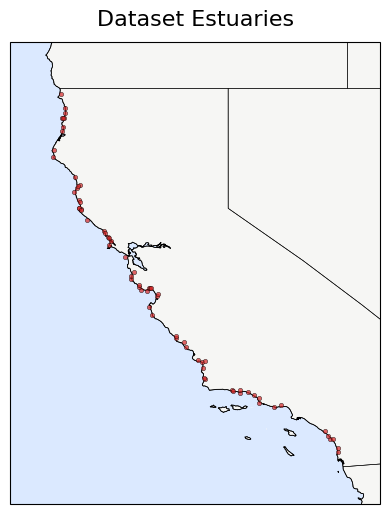

In [273]:
plot_estuaries_ca(
    gdf_points,
    markersize=10,
    jitter_deg=0.05,
    point_alpha=0.7,
    title="Dataset Estuaries",
    save_path=FIG_DIR / "state_map_all_estuaries.png",
)

631 1322


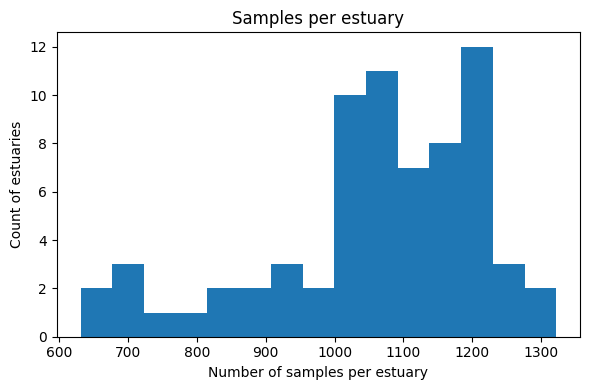

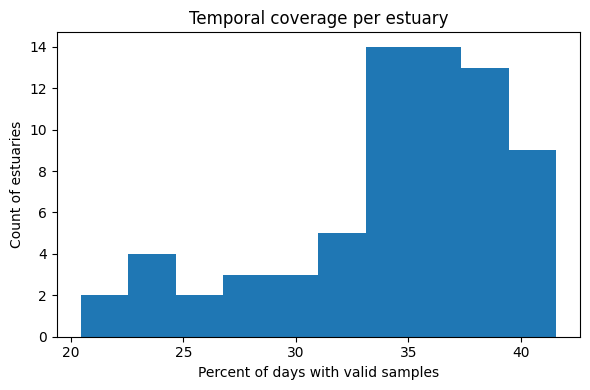

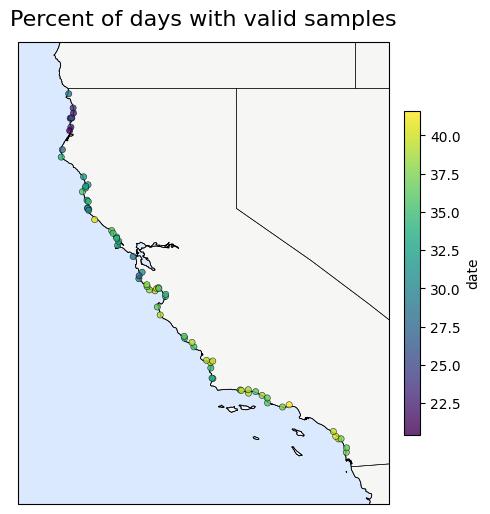

In [274]:
df = preds_all.copy()

samples_per_site = df.groupby("region").size().rename("n_samples")
days_per_site = df.assign(date=df["acquired"].dt.normalize()).groupby("region")["date"].nunique()
print(days_per_site.min(), days_per_site.max())

plt.figure(figsize=(6, 4))
plt.hist(samples_per_site, bins=15)
plt.xlabel("Number of samples per estuary")
plt.ylabel("Count of estuaries")
plt.title("Samples per estuary")
plt.tight_layout()
plt.show()

start = datetime(year=2018, month=1, day=1, tzinfo=UTC)
end = df["acquired"].max().normalize()
all_days = pd.date_range(start, end, freq="D")
df = df[df.acquired > start]
n_days_total = len(all_days)
days_per_site = df.assign(date=df["acquired"].dt.normalize()).groupby("region")["date"].nunique()

pct_days_per_site = 100 * days_per_site / n_days_total

plt.figure(figsize=(6, 4))
plt.hist(pct_days_per_site, bins=10)
plt.xlabel("Percent of days with valid samples")
plt.ylabel("Count of estuaries")
plt.title("Temporal coverage per estuary")
plt.tight_layout()
plt.show()

g = gdf_points[["region", "geometry"]].set_index("region").join(pct_days_per_site, how="left")
plot_estuaries_ca(
    g,
    column="date",
    cmap="viridis",
    title="Percent of days with valid samples",
    add_colorbar=True,
    show=True,
    markersize=20,
    jitter_deg=0.05,
    point_alpha=0.8,
    save_path=FIG_DIR / "state_map_pct_days_with_valid_sample.png",
)

/var/folders/pr/1dt1qk511zdgzhfy1xskpqm00000gn/T/ipykernel_31995/38841021.py:7: UserWarning:

Converting to PeriodArray/Index representation will drop timezone information.



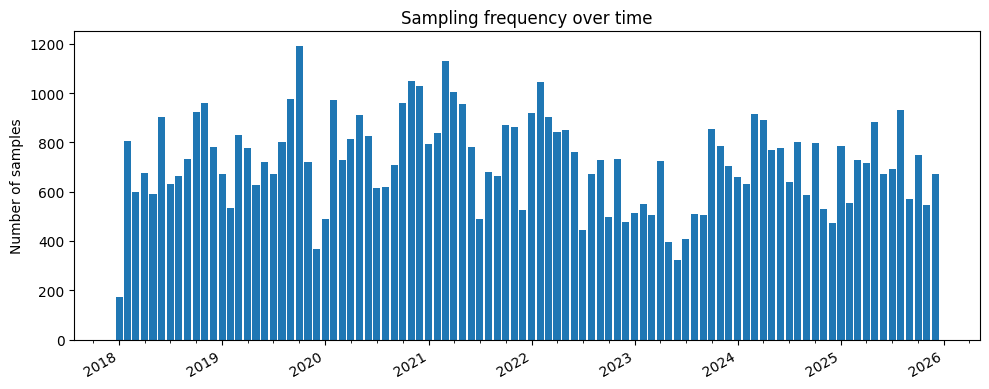

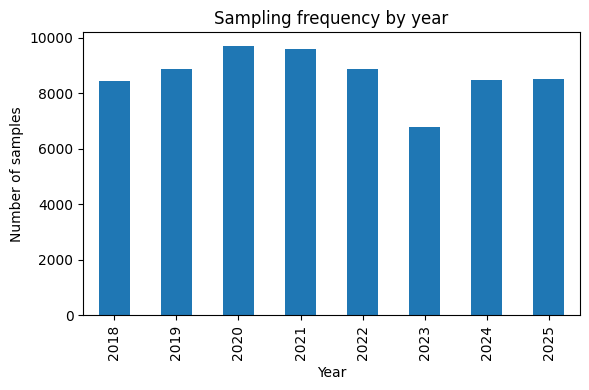

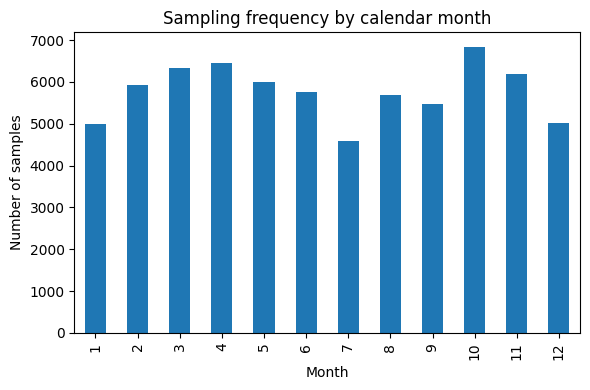

In [275]:
df = preds_all.copy()
start = datetime(year=2018, month=1, day=1, tzinfo=UTC)
df = df[df.acquired > start]

df["year"] = df["acquired"].dt.year

df["year_month"] = df["acquired"].dt.to_period("M")

samples_per_month = df.groupby("year_month").size().sort_index()

samples_per_month_dt = samples_per_month.copy()
samples_per_month_dt.index = samples_per_month_dt.index.to_timestamp()


fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(
    samples_per_month_dt.index,
    samples_per_month_dt.values,
    width=25,  # ~25 days looks good for monthly bars
)

ax.set_ylabel("Number of samples")
ax.set_title("Sampling frequency over time")

# Major ticks every year
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Minor ticks every 3 months (no labels)
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))

fig.autofmt_xdate()  # slight rotation if needed
plt.tight_layout()
plt.show()

samples_by_year = df.groupby("year").size()

plt.figure(figsize=(6, 4))
samples_by_year.plot(kind="bar")
plt.xlabel("Year")
plt.ylabel("Number of samples")
plt.title("Sampling frequency by year")
plt.tight_layout()
plt.savefig(FIG_DIR / "per_year_sampling.png")
plt.show()

df["month"] = df["acquired"].dt.month
samples_by_calendar_month = df.groupby("month").size()

plt.figure(figsize=(6, 4))
samples_by_calendar_month.plot(kind="bar")
plt.xlabel("Month")
plt.ylabel("Number of samples")
plt.title("Sampling frequency by calendar month")
plt.tight_layout()
plt.savefig(FIG_DIR / "per_month_sampling.png")
plt.show()

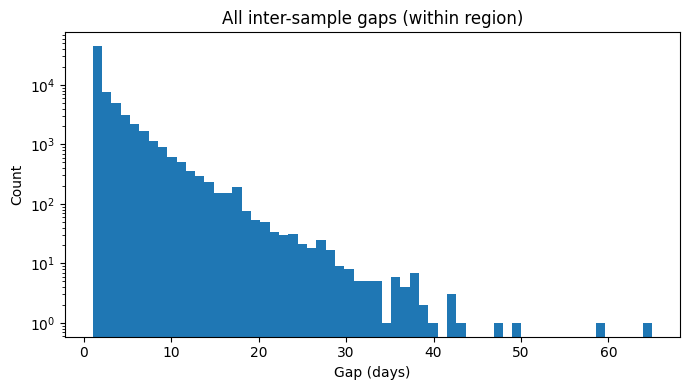

In [276]:
df = preds_all.copy()
start = datetime(year=2018, month=1, day=1, tzinfo=UTC)
df = df[df.acquired > start]

times = pd.to_datetime(df["date"], utc=True, errors="coerce")
gaps_days = (
    df.assign(date=times)
    .dropna(subset=["date"])
    .sort_values(["region", "date"])
    .groupby("region")["date"]
    .diff()
    .dt.total_seconds()
    .div(86400.0)  # days as float
    .dropna()
)

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.hist(gaps_days, bins=60)
plt.xlabel("Gap (days)")
plt.ylabel("Count")
plt.yscale("log")
plt.title("All inter-sample gaps (within region)")
plt.tight_layout()
plt.show()

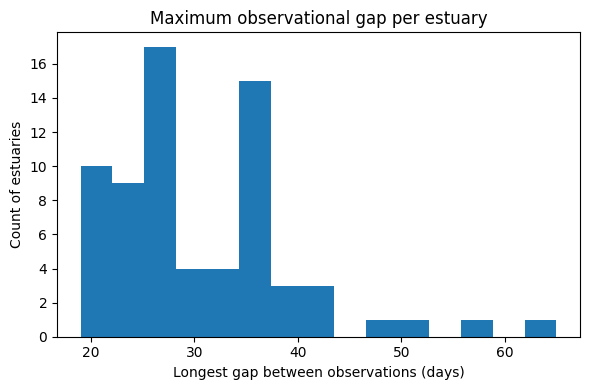

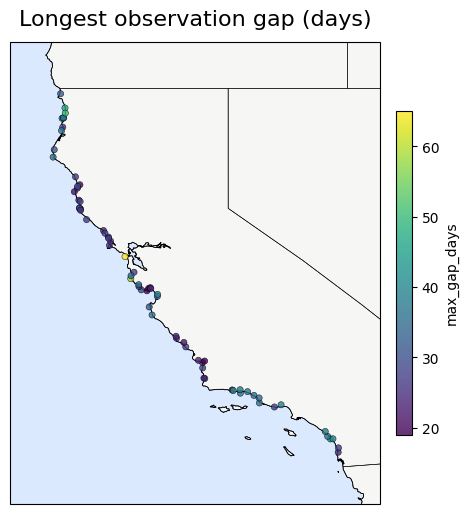

In [277]:
def max_gap_days(times: pd.Series) -> float:
    times = times.sort_values()
    gaps = times.diff().dt.days.dropna()
    return gaps.max() if len(gaps) else 0


max_gap_per_site = df.groupby("region")["acquired"].apply(max_gap_days).rename("max_gap_days")

plt.figure(figsize=(6, 4))
plt.hist(max_gap_per_site, bins=15)
plt.xlabel("Longest gap between observations (days)")
plt.ylabel("Count of estuaries")
plt.title("Maximum observational gap per estuary")
plt.tight_layout()
plt.show()

g = gdf_points.set_index("region").join(max_gap_per_site, how="left")
plot_estuaries_ca(
    g,
    column="max_gap_days",
    cmap="viridis",
    title="Longest observation gap (days)",
    add_colorbar=True,
    show=True,
    markersize=20,
    jitter_deg=0.05,
    point_alpha=0.8,
    save_path=FIG_DIR / "state_map_gap.png",
)

In [278]:
# 1) Make sure date is datetime64[ns]
df = preds_all.copy()
df["date"] = pd.to_datetime(df["date"])

# 2) Get global date range
start = datetime(year=2018, month=1, day=1)
# df["date"].min()
end = df["date"].max()

# 3) Build full MultiIndex: all regions × all dates
regions = df["region"].unique()
full_dates = pd.date_range(start, end, freq="D")

full_index = pd.MultiIndex.from_product(
    [regions, full_dates],
    names=["region", "date"],
)

# 4) Reindex and forward-fill within each region
full = df.set_index(["region", "date"]).sort_index().reindex(full_index)

# Forward-fill predictions within each region
full["y_pred"] = full["y_pred"].groupby(level="region").ffill()

prob_cols = ["p_closed", "p_perched_open", "p_open"]

for key in prob_cols:
    # Forward-fill predictions within each region
    full[key] = (
        full[key]
        .groupby(level="region")
        .apply(lambda s: s.interpolate(method="linear", limit_direction="both"))
        .ffill()
        .reset_index(level=0, drop=True)
    )

# normalize
P = full[prob_cols].to_numpy(dtype=float)
row_sum = np.nansum(P, axis=1, keepdims=True)

# Only normalize rows with valid positive mass
ok = np.isfinite(row_sum[:, 0]) & (row_sum[:, 0] > 0)
P_norm = P.copy()
P_norm[ok] = P[ok] / row_sum[ok]

# Write back
full.loc[:, prob_cols] = P_norm

full["openness"] = 0.5 * full["p_perched_open"] + full["p_open"]

region_min_date = df.groupby("region").date.min().max()
region_max_date = df.groupby("region").date.max().min()

full = full.reset_index()
full = full[full.date.between(region_min_date, region_max_date)].copy()
full = full.set_index(["region", "date"])

date_axis = full["openness"].unstack("date").columns.to_list()
region_labels = full["openness"].unstack("date").index.to_list()

probs = full[prob_cols].to_numpy(dtype=float)

y_pred = np.argmax(probs, axis=1)

full["y_pred"] = y_pred

# Entropy
eps = 1e-12
P_clip = np.clip(probs, eps, 1.0)

entropy = -np.sum(P_clip * np.log(P_clip), axis=1)

# Normalize by log(K)
K = len(prob_cols)
entropy_norm = entropy / np.log(K)

# Add to full DataFrame
full["entropy"] = entropy
full["entropy_norm"] = entropy_norm

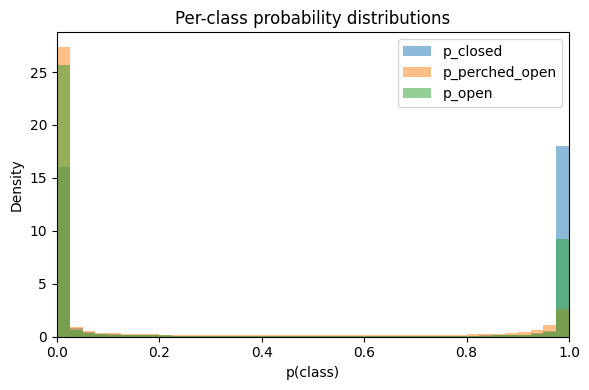

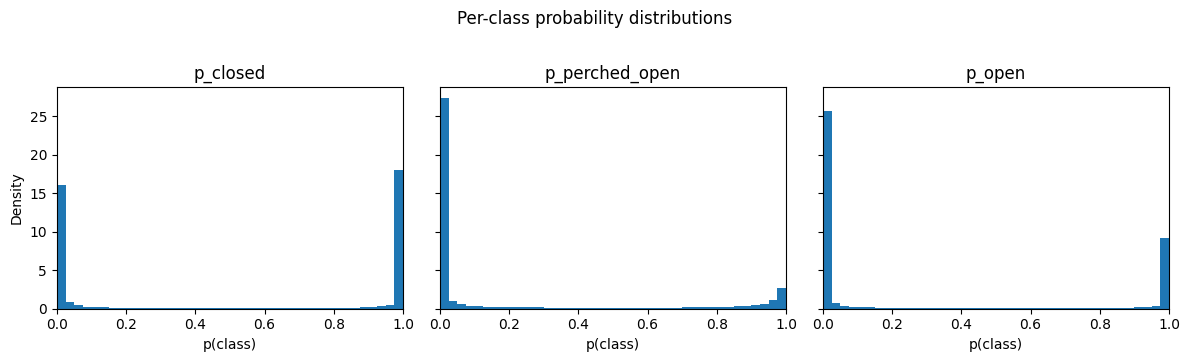

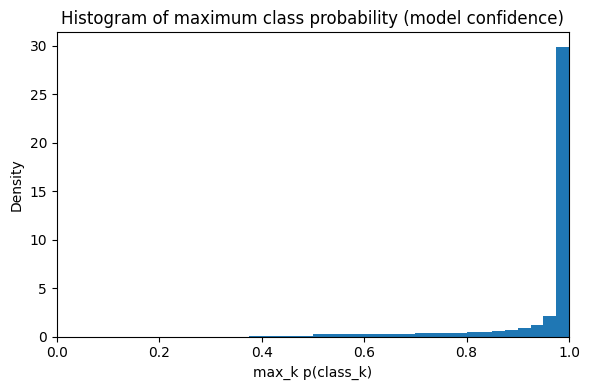

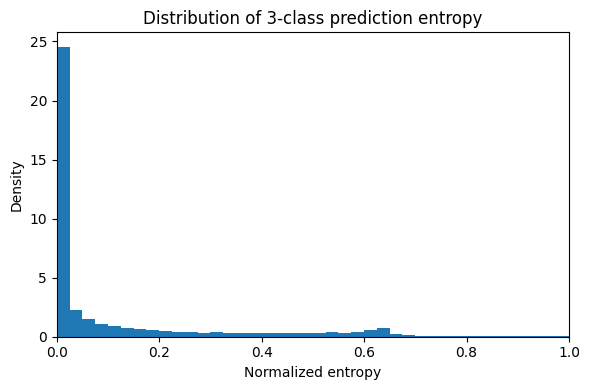

In [279]:
P = preds_all[prob_cols].to_numpy(dtype=float)

bins = np.linspace(0, 1, 41)

fig, ax = plt.subplots(figsize=(6, 4))

for j, col in enumerate(prob_cols):
    vals = P[:, j]
    vals = vals[np.isfinite(vals)]
    ax.hist(vals, bins=bins, density=True, alpha=0.5, label=col)

ax.set_xlim(0, 1)
ax.set_xlabel("p(class)")
ax.set_ylabel("Density")
ax.set_title("Per-class probability distributions")
ax.legend()
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 3, figsize=(12, 3.5), sharex=True, sharey=True)

bins = np.linspace(0, 1, 41)

for ax, j, col in zip(axs, range(3), prob_cols):
    vals = P[:, j]
    vals = vals[np.isfinite(vals)]
    ax.hist(vals, bins=bins, density=True)
    ax.set_title(col)
    ax.set_xlim(0, 1)

axs[0].set_ylabel("Density")
for ax in axs:
    ax.set_xlabel("p(class)")

fig.suptitle("Per-class probability distributions", y=1.02)
plt.tight_layout()
plt.show()

pmax = np.nanmax(P, axis=1)
pmax = pmax[np.isfinite(pmax)]

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(pmax, bins=np.linspace(0, 1, 41), density=True)
ax.set_xlim(0, 1)
ax.set_xlabel("max_k p(class_k)")
ax.set_ylabel("Density")
ax.set_title("Histogram of maximum class probability (model confidence)")
plt.tight_layout()
plt.show()

# Entropy
eps = 1e-12
P_clip = np.clip(P, eps, 1.0)

entropy = -np.sum(P_clip * np.log(P_clip), axis=1)

# Normalize by log(K)
K = len(prob_cols)
entropy_norm = entropy / np.log(K)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(entropy_norm, bins=40, density=True)
ax.set_xlabel("Normalized entropy")
ax.set_ylabel("Density")
ax.set_title("Distribution of 3-class prediction entropy")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

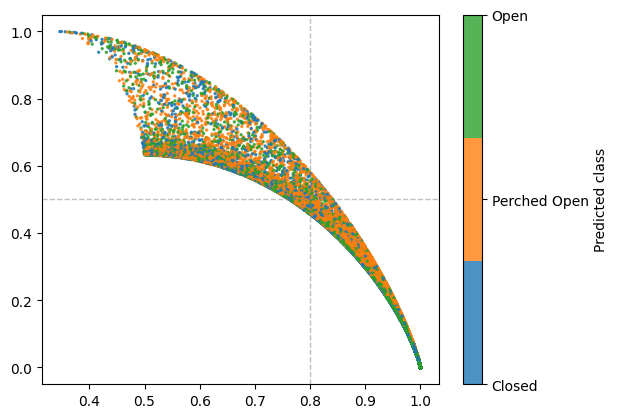

In [280]:
from matplotlib.colors import ListedColormap

cmap = ListedColormap(["tab:blue", "tab:orange", "tab:green"])

plt.scatter(
    x=P.max(axis=1),
    y=entropy_norm,
    c=preds_all.y_pred,
    cmap=cmap,
    s=2,
    alpha=0.8,
)

cbar = plt.colorbar(ticks=[0, 1, 2])
cbar.set_label("Predicted class")
cbar.set_ticklabels(["Closed", "Perched Open", "Open"])

plt.axhline(0.5, ls="--", lw=1, c="gray", alpha=0.5)  # entropy threshold
plt.axvline(0.8, ls="--", lw=1, c="gray", alpha=0.5)  # confidence threshold

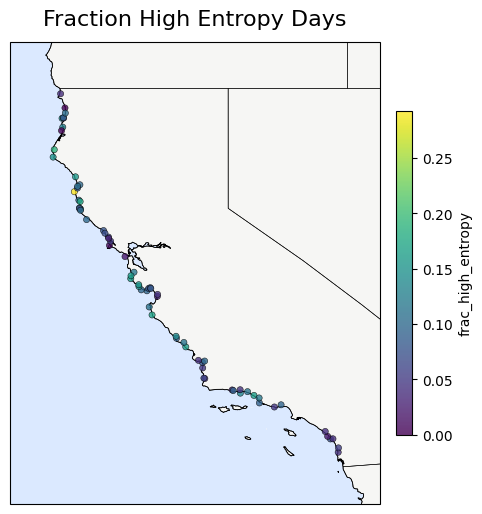

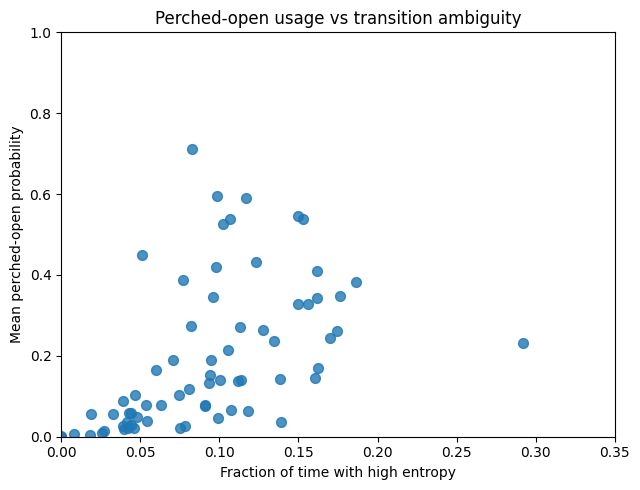

In [281]:
H_THR = 0.6

frac_high_entropy = (
    full["entropy_norm"]
    .groupby(level="region")
    .apply(lambda s: (s > H_THR).mean())
    .rename("frac_high_entropy")
)

g = gdf_points.set_index("region").join(frac_high_entropy, how="left")
plot_estuaries_ca(
    g,
    column="frac_high_entropy",
    cmap="viridis",
    title="Fraction High Entropy Days",
    markersize=20,
    jitter_deg=0.05,
    point_alpha=0.8,
    add_colorbar=True,
    show=True,
)

# Mean perched-open fraction
mean_perched_frac = (
    full["p_perched_open"].groupby(level="region").mean().rename("mean_perched_frac")
)
mean_open_frac = full["p_open"].groupby(level="region").mean().rename("mean_open_frac")
mean_closed_frac = full["p_closed"].groupby(level="region").mean().rename("mean_closed_frac")

# Combine
df_scatter = pd.concat(
    [frac_high_entropy, mean_perched_frac, mean_open_frac, mean_closed_frac], axis=1
).dropna()

fig, ax = plt.subplots(figsize=(6.5, 5))

ax.scatter(
    df_scatter["frac_high_entropy"],
    df_scatter["mean_perched_frac"],
    s=50,
    alpha=0.8,
)

ax.set_xlabel("Fraction of time with high entropy")
ax.set_ylabel("Mean perched-open probability")
ax.set_title("Perched-open usage vs transition ambiguity")

ax.set_xlim(0, 0.35)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

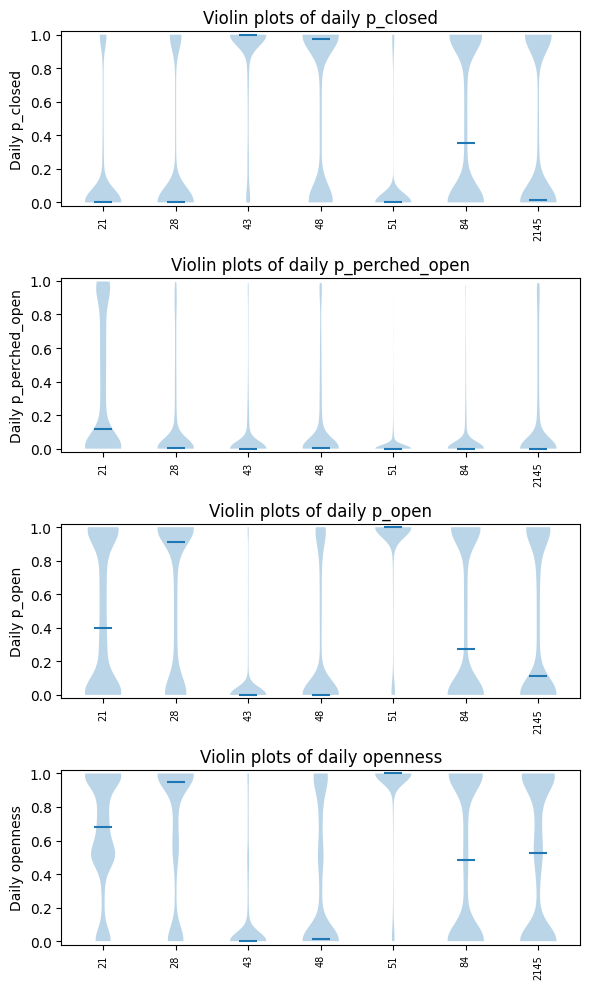

In [282]:
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(6, 10))

for i, p_type in enumerate(["p_closed", "p_perched_open", "p_open", "openness"]):
    ax = axes[i]

    y_mat_open = full[p_type].unstack("date").to_numpy()

    site_var = pd.Series(np.nanvar(y_mat_open, axis=1), index=region_labels).sort_values(
        ascending=False
    )
    TIME_SERIES_REGIONS = sorted([2145, 48, 51, 84, 28, 21, 43])
    subset = site_var.loc[TIME_SERIES_REGIONS].index.tolist()
    subset_idx = [region_labels.index(r) for r in subset]
    data_list = [y_mat_open[i, :][np.isfinite(y_mat_open[i, :])] for i in subset_idx]

    ax.violinplot(data_list, showmedians=True, showextrema=False)

    ax.set_xticks(np.arange(1, len(subset) + 1))
    ax.set_xticklabels(subset, rotation=90, fontsize=7)
    ax.set_ylim(-0.02, 1.02)
    ax.set_ylabel(f"Daily {p_type}")
    ax.set_title(f"Violin plots of daily {p_type}")

plt.tight_layout()
plt.show()

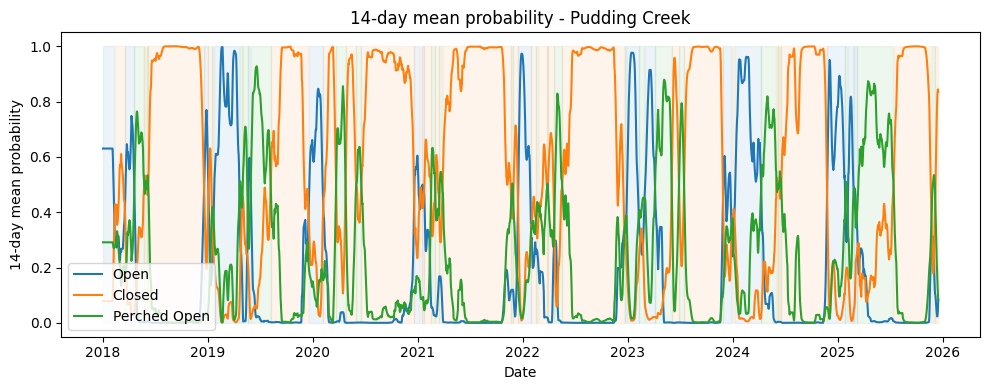

In [283]:
region = 85
df = full.loc[region].sort_index()
name = gdf.set_index("region").loc[region]["Estuary_Name"]
# df = df[
#     (df.index >= "2020-01-01") &
#     (df.index <= "2022-03-01")
# ]

pcols = ["p_open", "p_closed", "p_perched_open"]

df_roll = df[pcols].rolling("14D", min_periods=1).mean()

plt.figure(figsize=(10, 4))

plt.plot(df_roll.index, df_roll["p_open"], label="Open", lw=1.5)
plt.plot(df_roll.index, df_roll["p_closed"], label="Closed", lw=1.5)
plt.plot(df_roll.index, df_roll["p_perched_open"], label="Perched Open", lw=1.5)

dominant = df_roll.idxmax(axis=1)

colors = {
    "p_open": "tab:blue",
    "p_closed": "tab:orange",
    "p_perched_open": "tab:green",
}

for col, color in colors.items():
    mask = dominant == col
    plt.fill_between(df_roll.index, 0, 1, where=mask, color=color, alpha=0.08)

plt.ylim(-0.05, 1.05)
plt.ylabel("14-day mean probability")
plt.xlabel("Date")
plt.legend(loc="lower left")
plt.title(f"14-day mean probability - {name}")
plt.tight_layout()
name = "_".join([n.lower() for n in name.split(" ")])
plt.savefig(FIG_DIR / f"{name}_timeseries.png")
plt.show()

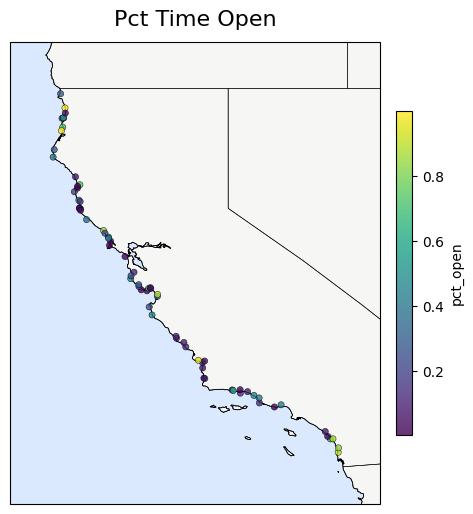

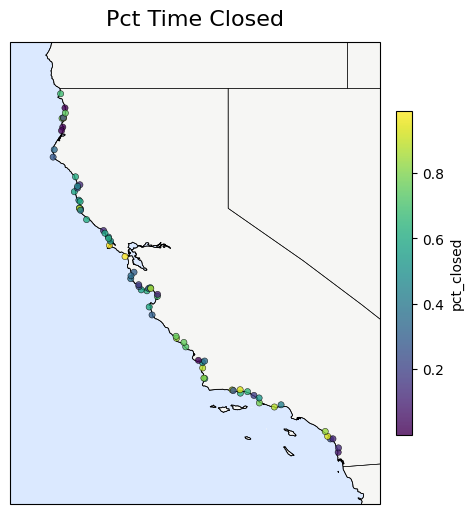

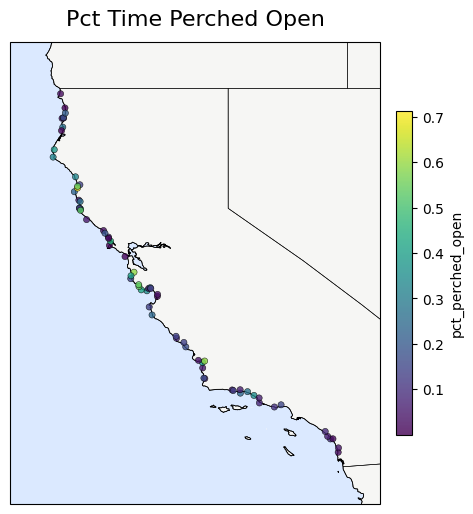

In [284]:
mean_frac = full["p_open"].groupby(level="region").mean().rename("pct_open")

g = gdf_points.set_index("region").join(mean_frac, how="left")
plot_estuaries_ca(
    g,
    column="pct_open",
    cmap="viridis",
    title="Pct Time Open",
    markersize=20,
    jitter_deg=0.05,
    point_alpha=0.8,
    add_colorbar=True,
    show=True,
    save_path=FIG_DIR / "state_map_p_open.png",
)

mean_frac = full["p_closed"].groupby(level="region").mean().rename("pct_closed")

g = gdf_points.set_index("region").join(mean_frac, how="left")
plot_estuaries_ca(
    g,
    column="pct_closed",
    cmap="viridis",
    title="Pct Time Closed",
    markersize=20,
    jitter_deg=0.05,
    point_alpha=0.8,
    add_colorbar=True,
    show=True,
    save_path=FIG_DIR / "state_map_p_closed.png",
)

mean_frac = full["p_perched_open"].groupby(level="region").mean().rename("pct_perched_open")

g = gdf_points.set_index("region").join(mean_frac, how="left")
plot_estuaries_ca(
    g,
    column="pct_perched_open",
    cmap="viridis",
    title="Pct Time Perched Open",
    markersize=20,
    jitter_deg=0.05,
    point_alpha=0.8,
    add_colorbar=True,
    show=True,
    save_path=FIG_DIR / "state_map_p_perched_open.png",
)

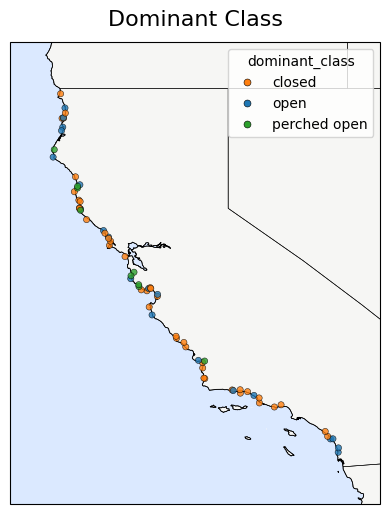

In [285]:
class_map = {0: "closed", 1: "perched open", 2: "open"}
classes = sorted(list(class_map.values()))
map_class = (
    full["y_pred"]
    .groupby(level="region")
    .agg(lambda x: x.mode().iloc[0])
    .rename("dominant_class")
    .map(class_map)
)

g = gdf_points.set_index("region").join(map_class, how="left")

import matplotlib.colors as mcolors

class_colors = {
    "closed": "tab:orange",  # orange
    "perched open": "tab:green",  # green
    "open": "tab:blue",  # purple
}

# Build a discrete colormap with exactly these colors in this order
class_cmap = mcolors.ListedColormap([class_colors[k] for k in classes], name="class_cmap")

# g = gdf_points.set_index("region").merge(metrics.map_class, how="left", right_index=True, left_index=True)

plot_estuaries_ca(
    g,
    column="dominant_class",
    title="Dominant Class",
    markersize=20,
    jitter_deg=0.05,
    point_alpha=0.8,
    show=True,
    categorical=True,
    cmap=class_cmap,
    save_path=FIG_DIR / "state_map_dominant_class.png",
)

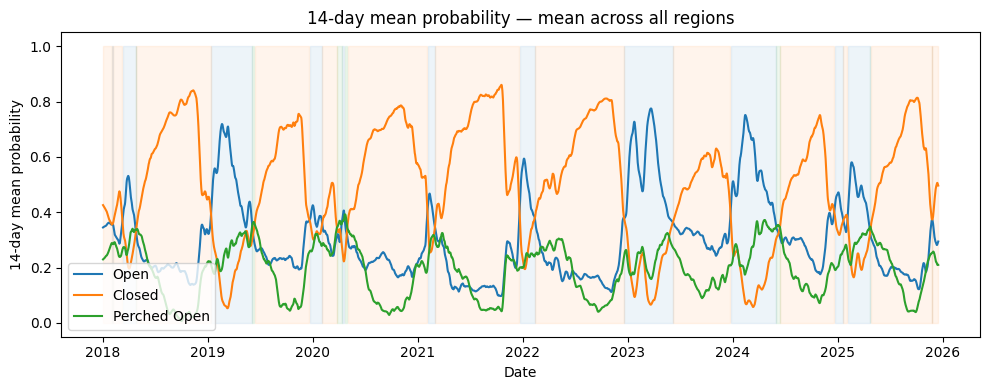

In [286]:
import matplotlib.pyplot as plt

pcols = ["p_open", "p_closed", "p_perched_open"]

# --- 1) Mean across regions at each date ---
# If your index level is named "date", this will use it; otherwise it uses level=1.
date_level = "date" if "date" in full.index.names else 1

df_mean = full[pcols].groupby(level=date_level).mean().sort_index()

# --- 2) 14-day rolling mean on the mean time series ---
df_roll = df_mean.rolling("14D", min_periods=1).mean()

# --- 3) Plot ---
plt.figure(figsize=(10, 4))

plt.plot(df_roll.index, df_roll["p_open"], label="Open", lw=1.5)
plt.plot(df_roll.index, df_roll["p_closed"], label="Closed", lw=1.5)
plt.plot(df_roll.index, df_roll["p_perched_open"], label="Perched Open", lw=1.5)

dominant = df_roll.idxmax(axis=1)

colors = {
    "p_open": "tab:blue",
    "p_closed": "tab:orange",
    "p_perched_open": "tab:green",
}

for col, color in colors.items():
    mask = dominant == col
    plt.fill_between(df_roll.index, 0, 1, where=mask, color=color, alpha=0.08)

plt.ylim(-0.05, 1.05)
plt.ylabel("14-day mean probability")
plt.xlabel("Date")
plt.legend(loc="lower left")
plt.title("14-day mean probability — mean across all regions")
plt.tight_layout()

# plt.savefig(FIG_DIR / "all_regions_mean_timeseries.png")
plt.show()

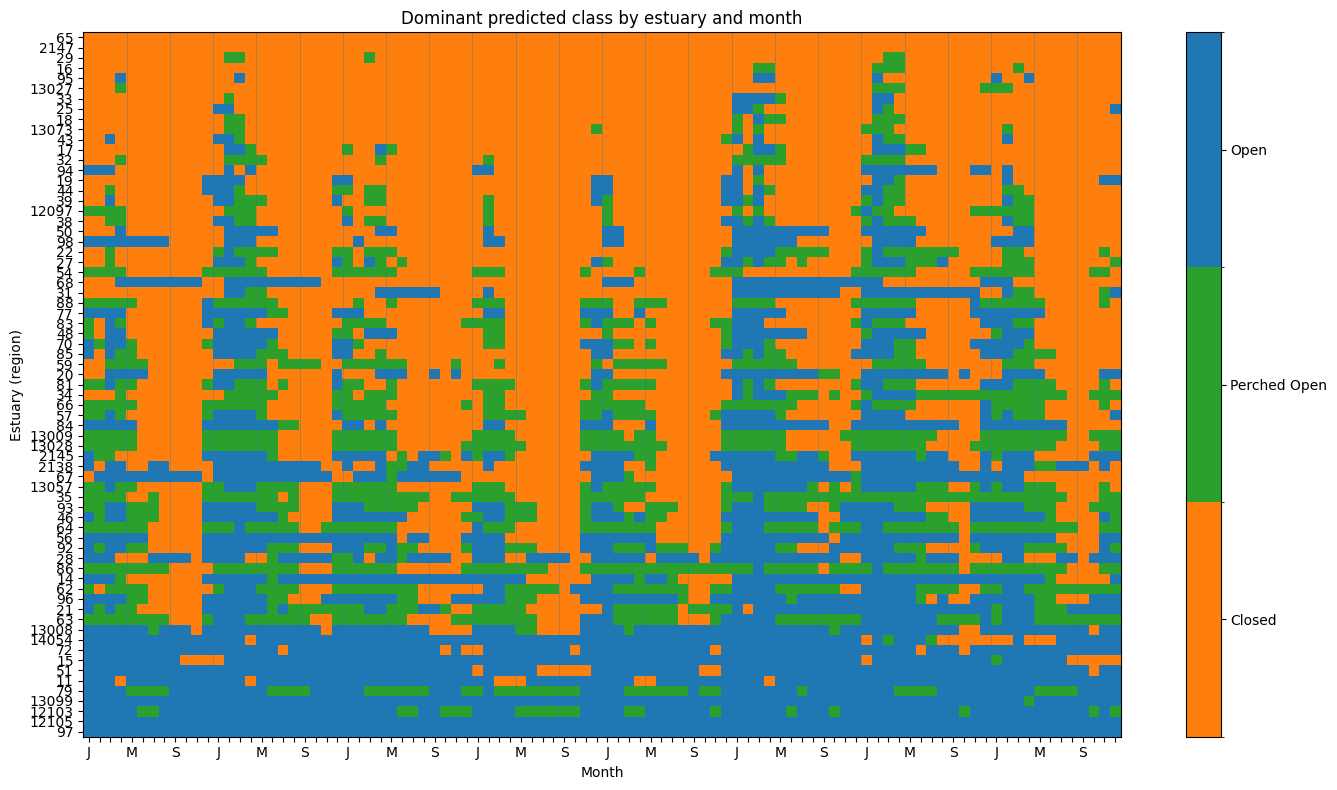

In [287]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import BoundaryNorm, ListedColormap

# --- config ---
# map your class ids to names (edit if your ids differ)
class_names = {
    0: "Closed",
    1: "Perched Open",
    2: "Open",
}

# choose colors for class ids 0/1/2 (edit to your preference)
# (example uses: 0=blue, 1=green, 2=orange)
cmap = ListedColormap(["tab:orange", "tab:green", "tab:blue"])
norm = BoundaryNorm(boundaries=[-0.5, 0.5, 1.5, 2.5], ncolors=cmap.N)

# --- get (region, month) dominant class ---
# make sure we have region/date columns
tmp = full.reset_index()
tmp["date"] = pd.to_datetime(tmp["date"])
tmp["month"] = tmp["date"].dt.to_period("M").dt.to_timestamp()

# mean p_closed per region
region_order = (
    full["p_closed"]
    .groupby(level="region")
    .mean()
    .sort_values(ascending=False)  # highest p_closed at top
    .index
)

# dominant class per (region, month): mode; tie-break by picking smallest id
dominant = (
    tmp.groupby(["region", "month"])["y_pred"]
    .agg(lambda x: x.value_counts().idxmax())
    .rename("dominant_class")
    .reset_index()
)

# pivot to estuary x month matrix
mat = dominant.pivot(index="region", columns="month", values="dominant_class").sort_index()
mat = mat.loc[region_order]

# --- plot ---
fig, ax = plt.subplots(figsize=(14, 8))

im = ax.imshow(mat.values, aspect="auto", cmap=cmap, norm=norm, interpolation="nearest")

# x-axis: months
months = mat.columns
ax.set_xticks(np.arange(len(months)))

# label every 4th month with a single letter (J/M/J/S…)
labels = [m.strftime("%b")[0] if (i % 4 == 0) else "" for i, m in enumerate(months)]
ax.set_xticklabels(labels)

# add vertical lines every 4th month
for i in range(0, len(months), 4):
    ax.axvline(i - 0.5, lw=0.6, alpha=0.4)

# y-axis: regions
ax.set_yticks(np.arange(len(mat.index)))
ax.set_yticklabels(mat.index)

ax.set_xlabel("Month")
ax.set_ylabel("Estuary (region)")
ax.set_title("Dominant predicted class by estuary and month")

# discrete colorbar with class names
cbar = fig.colorbar(im, ax=ax, ticks=[0, 1, 2])
cbar.ax.set_yticklabels([class_names[i] for i in [0, 1, 2]])

plt.tight_layout()
plt.savefig(FIG_DIR / "heatmap_estuary_month_dominant_class.png", dpi=200)
plt.show()

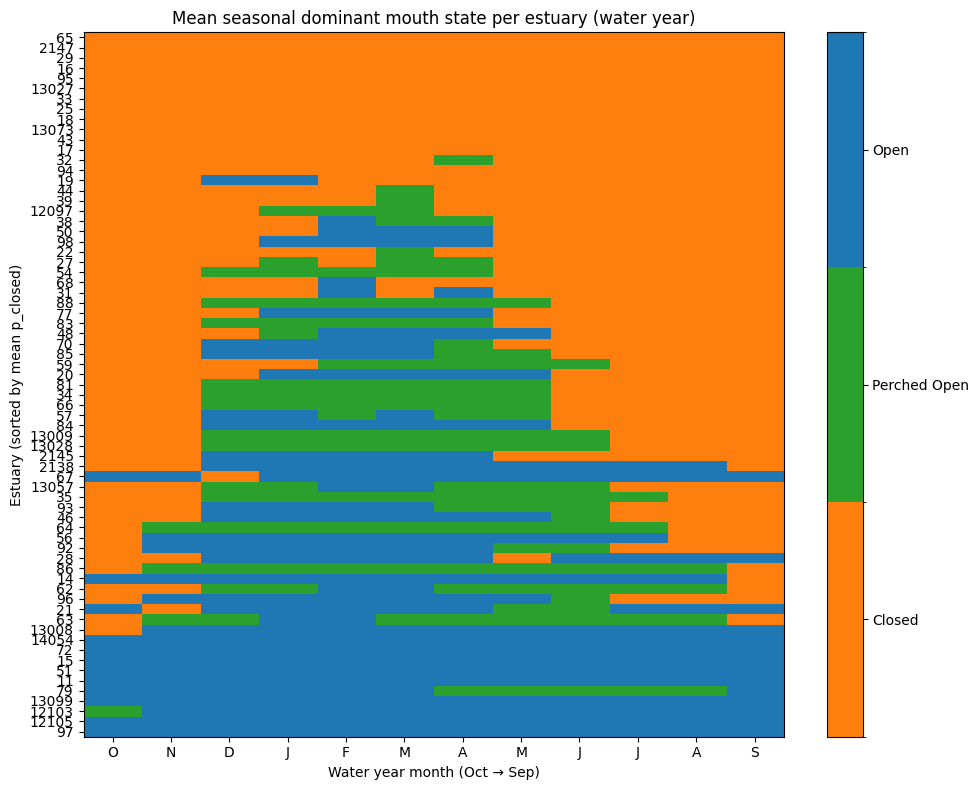

In [288]:
tmp = full.reset_index()
tmp["date"] = pd.to_datetime(tmp["date"])

# month-of-year, shifted so Oct=0, Nov=1, ..., Sep=11
tmp["wy_month"] = (tmp["date"].dt.month - 10) % 12

pcols = ["p_closed", "p_perched_open", "p_open"]

monthly_mean = tmp.groupby(["region", "wy_month"])[pcols].mean()

monthly_mean["dominant_class"] = monthly_mean[pcols].values.argmax(axis=1)
monthly_mean = monthly_mean.reset_index()

mat = monthly_mean.pivot(index="region", columns="wy_month", values="dominant_class")

region_order = full["p_closed"].groupby(level="region").mean().sort_values(ascending=False).index

mat = mat.loc[region_order]

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import BoundaryNorm, ListedColormap

cmap = ListedColormap(
    [
        "tab:orange",  # 0 = Closed
        "tab:green",  # 1 = Perched Open
        "tab:blue",  # 2 = Open
    ]
)
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(mat.values, aspect="auto", cmap=cmap, norm=norm, interpolation="nearest")

# x-axis: water-year months
ax.set_xticks(np.arange(12))
ax.set_xticklabels(["O", "N", "D", "J", "F", "M", "A", "M", "J", "J", "A", "S"])

ax.set_yticks(np.arange(len(mat.index)))
ax.set_yticklabels(mat.index)

ax.set_xlabel("Water year month (Oct → Sep)")
ax.set_ylabel("Estuary (sorted by mean p_closed)")
ax.set_title("Mean seasonal dominant mouth state per estuary (water year)")

cbar = fig.colorbar(im, ax=ax, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(["Closed", "Perched Open", "Open"])

plt.tight_layout()
plt.savefig(FIG_DIR / "heatmap_estuary_water_year_month_mean_behavior.png", dpi=200)
plt.show()

/var/folders/pr/1dt1qk511zdgzhfy1xskpqm00000gn/T/ipykernel_31995/2951749266.py:23: FutureWarning:

The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.



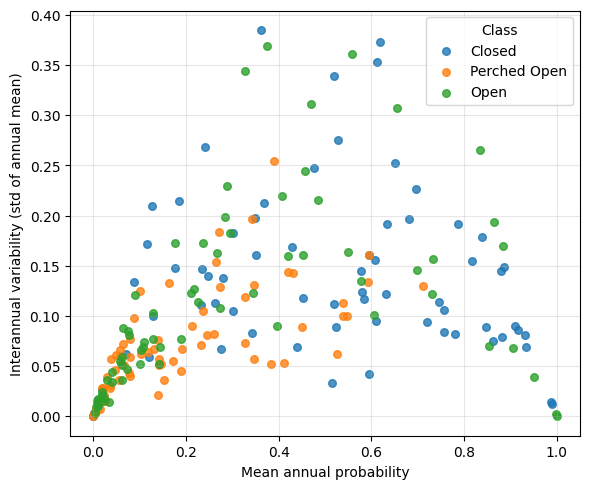

In [289]:
import numpy as np
import pandas as pd

pcols = ["p_closed", "p_perched_open", "p_open"]

tmp = full.reset_index()
tmp["date"] = pd.to_datetime(tmp["date"])
tmp["year"] = tmp["date"].dt.year

# Annual mean probability per estuary
annual = tmp.groupby(["region", "year"])[pcols].mean().reset_index()

stats = annual.groupby("region")[pcols].agg(["mean", "std"])

stats_long = (
    stats.stack(level=0)  # class
    .reset_index()
    .rename(columns={"level_1": "class", "mean": "mean_prob", "std": "interannual_std"})
)

import matplotlib.pyplot as plt

class_labels = {
    "p_closed": "Closed",
    "p_perched_open": "Perched Open",
    "p_open": "Open",
}

colors = {
    "p_closed": "tab:blue",
    "p_perched_open": "tab:orange",
    "p_open": "tab:green",
}

plt.figure(figsize=(6, 5))

for cls in pcols:
    g = stats_long[stats_long["class"] == cls]
    plt.scatter(
        g["mean_prob"],
        g["interannual_std"],
        s=30,
        alpha=0.8,
        color=colors[cls],
        label=class_labels[cls],
    )

plt.xlabel("Mean annual probability")
plt.ylabel("Interannual variability (std of annual mean)")
plt.legend(title="Class")
plt.grid(alpha=0.3)
plt.tight_layout()

# plt.savefig(FIG_DIR / "interannual_variability_scatter_by_class.png", dpi=200)
plt.show()

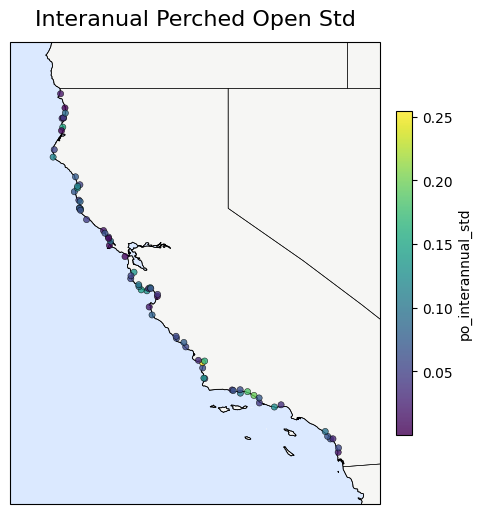

In [290]:
import pandas as pd

tmp = full.reset_index()
tmp["date"] = pd.to_datetime(tmp["date"])

# Choose calendar year (swap to water year if you want)
tmp["year"] = tmp["date"].dt.year

# Annual mean p_perched_open per estuary
annual_po = tmp.groupby(["region", "year"])["p_perched_open"].mean().reset_index()

# Interannual variability (std across years)
po_var = (
    annual_po.groupby("region")["p_perched_open"].std().rename("po_interannual_std").reset_index()
)

g = gdf_points.merge(po_var, on="region", how="left")

plot_estuaries_ca(
    g,
    column="po_interannual_std",
    # cmap="brg",
    title="Interanual Perched Open Std",
    markersize=20,
    jitter_deg=0.05,
    point_alpha=0.8,
    add_colorbar=True,
    show=True,
    # save_path=FIG_DIR / "state_map_dominant_class.png"
)

In [291]:
from io import StringIO

import pandas as pd

# curl https://www.ncei.noaa.gov/access/monitoring/climate-at-a-glance/statewide/time-series/4/pcp/12/9/2017-2025.csv?base_prd=true

raw = """Date,Value,Anomaly
201809,15.82,-6.63
201909,28.37,5.92
202009,15.64,-6.81
202109,11.13,-11.32
202209,16.42,-6.03
202309,30.89,8.44
202409,22.97,0.52
202509,20.44,-2.01
"""

precip = pd.read_csv(StringIO(raw))

# Parse YYYYMM → datetime
precip["date"] = pd.to_datetime(precip["Date"].astype(str), format="%Y%m")

# Water year is just the year (since these are September-ending totals)
precip["water_year"] = precip["date"].dt.year

# Clean numeric columns
precip["precip_in"] = pd.to_numeric(precip["Value"], errors="coerce")
precip["anomaly_in"] = pd.to_numeric(precip["Anomaly"], errors="coerce")

# Final tidy table
precip = precip[["water_year", "precip_in", "anomaly_in"]].sort_values("water_year")

precip

,water_year,precip_in,anomaly_in
0,2018,15.82,-6.63
1,2019,28.37,5.92
2,2020,15.64,-6.81
3,2021,11.13,-11.32
4,2022,16.42,-6.03
5,2023,30.89,8.44
6,2024,22.97,0.52
7,2025,20.44,-2.01


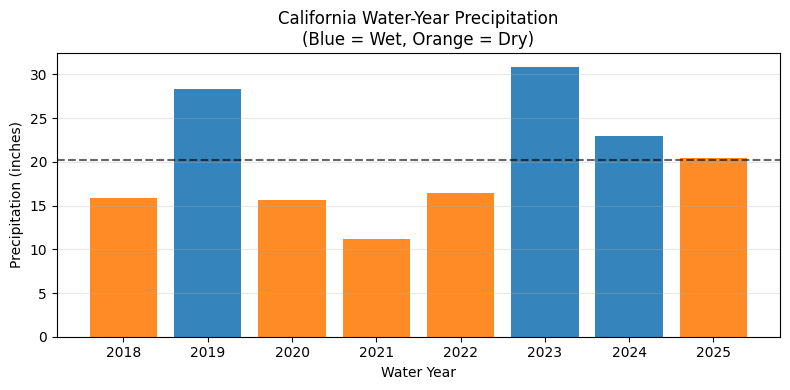

In [292]:
colors = ["tab:blue" if a >= 0 else "tab:orange" for a in precip["anomaly_in"]]

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(
    precip["water_year"],
    precip["precip_in"],
    color=colors,
    alpha=0.9,
)

ax.axhline(precip["precip_in"].mean(), linestyle="--", color="black", alpha=0.6)

ax.set_xlabel("Water Year")
ax.set_ylabel("Precipitation (inches)")
ax.set_title("California Water-Year Precipitation\n(Blue = Wet, Orange = Dry)")

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "water_year_precip_bar.png", dpi=200)
plt.show()

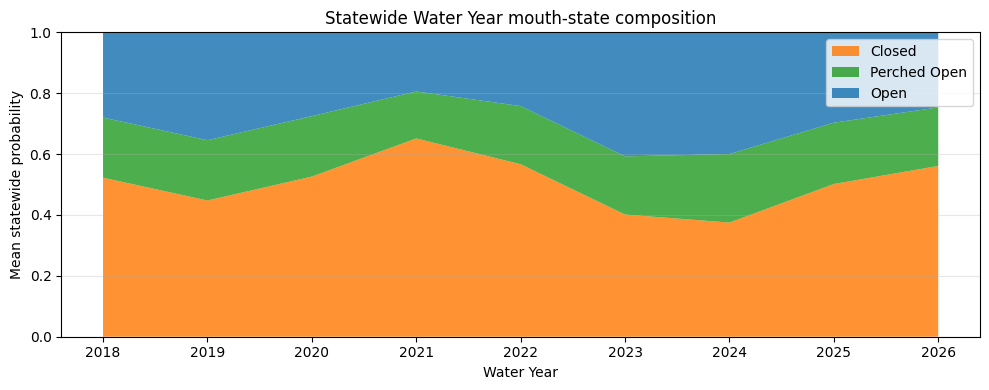

In [293]:
import numpy as np
import pandas as pd

pcols = ["p_closed", "p_perched_open", "p_open"]

tmp = full.reset_index()
tmp["date"] = pd.to_datetime(tmp["date"])

tmp["water_year"] = tmp["date"].dt.year + (tmp["date"].dt.month >= 10).astype(int)

# Statewide annual mean probability
statewide = tmp.groupby("water_year")[pcols].mean().sort_index()

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

ax.stackplot(
    statewide.index,
    statewide["p_closed"],
    statewide["p_perched_open"],
    statewide["p_open"],
    labels=["Closed", "Perched Open", "Open"],
    colors=["tab:orange", "tab:green", "tab:blue"],
    alpha=0.85,
)

ax.set_ylim(0, 1)
ax.set_ylabel("Mean statewide probability")
ax.set_xlabel("Water Year")
ax.legend(loc="upper right")
ax.set_title("Statewide Water Year mouth-state composition")

ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(FIG_DIR / "statewide_water_year_composition_stackplot.png", dpi=200)
plt.show()

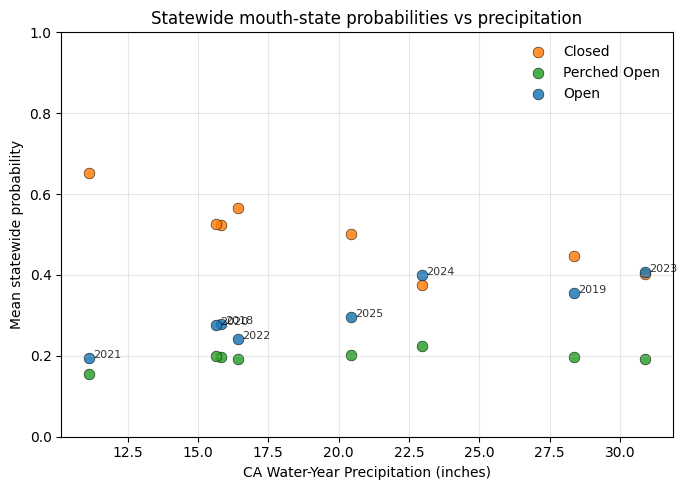

In [294]:
import matplotlib.pyplot as plt
import pandas as pd

# Join on overlapping water years
dfj = (
    statewide.reset_index()
    .merge(precip[["water_year", "precip_in"]], on="water_year", how="inner")
    .sort_values("water_year")
)

fig, ax = plt.subplots(figsize=(7, 5))

color_map = {
    "p_closed": "tab:orange",
    "p_perched_open": "tab:green",
    "p_open": "tab:blue",
}
label_map = {
    "p_closed": "Closed",
    "p_perched_open": "Perched Open",
    "p_open": "Open",
}

for col in ["p_closed", "p_perched_open", "p_open"]:
    ax.scatter(
        dfj["precip_in"],
        dfj[col],
        s=60,
        alpha=0.85,
        color=color_map[col],
        label=label_map[col],
        edgecolor="black",
        linewidth=0.4,
    )

# Optional: label points with water year
for _, r in dfj.iterrows():
    ax.text(
        r["precip_in"] + 0.15,
        r["p_open"],  # anchor labels on one series to reduce clutter
        str(int(r["water_year"])),
        fontsize=8,
        alpha=0.8,
    )

ax.set_xlabel("CA Water-Year Precipitation (inches)")
ax.set_ylabel("Mean statewide probability")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(loc="best", frameon=False)
ax.set_title("Statewide mouth-state probabilities vs precipitation")

plt.tight_layout()
plt.savefig(FIG_DIR / "pclass_vs_precip_scatter.png", dpi=200)
plt.show()

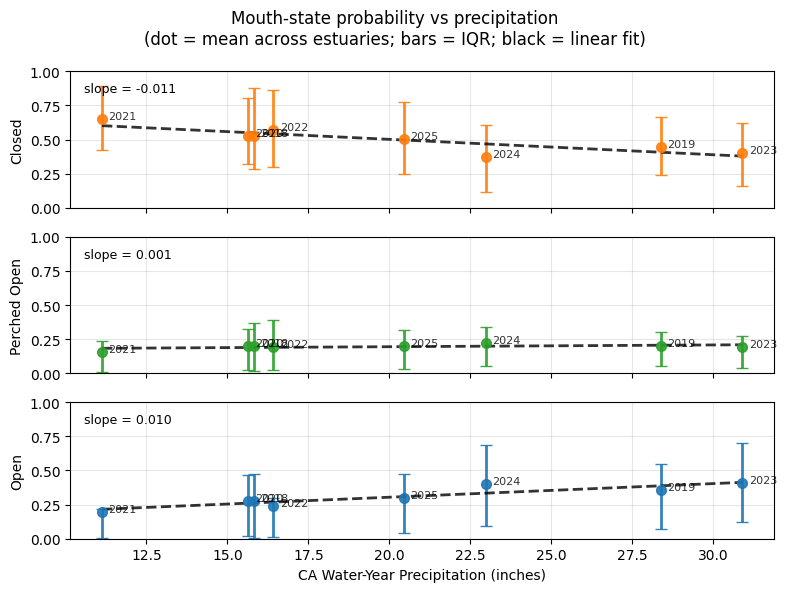

In [295]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pcols = ["p_closed", "p_perched_open", "p_open"]
color_map = {"p_closed": "tab:orange", "p_perched_open": "tab:green", "p_open": "tab:blue"}
label_map = {"p_closed": "Closed", "p_perched_open": "Perched Open", "p_open": "Open"}

# estuary-year means
tmp = full.reset_index()
tmp["date"] = pd.to_datetime(tmp["date"])
tmp["water_year"] = tmp["date"].dt.year + (tmp["date"].dt.month >= 10).astype(int)

ey = (
    tmp.groupby(["region", "water_year"])[pcols]
    .mean()
    .reset_index()
    .merge(precip[["water_year", "precip_in"]], on="water_year", how="inner")
)


# summarize across estuaries within each WY
def q25(x):
    return np.nanpercentile(x, 25)


def q75(x):
    return np.nanpercentile(x, 75)


summ = (
    ey.groupby("water_year")
    .agg(
        precip_in=("precip_in", "first"),
        **{f"{c}_mean": (c, "mean") for c in pcols},
        **{f"{c}_q25": (c, q25) for c in pcols},
        **{f"{c}_q75": (c, q75) for c in pcols},
    )
    .reset_index()
    .sort_values("water_year")
)
import matplotlib.pyplot as plt
import numpy as np

pcols = ["p_closed", "p_perched_open", "p_open"]
color_map = {
    "p_closed": "tab:orange",
    "p_perched_open": "tab:green",
    "p_open": "tab:blue",
}
label_map = {
    "p_closed": "Closed",
    "p_perched_open": "Perched Open",
    "p_open": "Open",
}

# fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 10), sharex=True, sharey=True)

# for ax, c in zip(axes, pcols):
#     x = summ["precip_in"].to_numpy()
#     y = summ[f"{c}_mean"].to_numpy()
#     ylo = summ[f"{c}_q25"].to_numpy()
#     yhi = summ[f"{c}_q75"].to_numpy()
#     yerr = np.vstack([y - ylo, yhi - y])

#     ax.errorbar(
#         x, y, yerr=yerr,
#         fmt="o",
#         ms=7,
#         color=color_map[c],
#         ecolor=color_map[c],
#         elinewidth=2,
#         capsize=4,
#         alpha=0.9,
#     )

#     # annotate water year
#     for _, r in summ.iterrows():
#         ax.text(
#             r["precip_in"] + 0.2,
#             r[f"{c}_mean"],
#             str(int(r["water_year"])),
#             fontsize=8,
#             alpha=0.8,
#         )

#     ax.set_ylabel(label_map[c])
#     ax.set_ylim(0, 1)
#     ax.grid(True, alpha=0.3)

# axes[-1].set_xlabel("CA Water-Year Precipitation (inches)")

# fig.suptitle(
#     "Mouth-state probability vs precipitation\n(dot = mean across estuaries; bars = IQR across estuaries)",
#     y=0.98,
# )

# plt.tight_layout()
# plt.show()

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 6), sharex=True, sharey=True)

for ax, c in zip(axes, pcols):
    x = summ["precip_in"].to_numpy()
    y = summ[f"{c}_mean"].to_numpy()
    ylo = summ[f"{c}_q25"].to_numpy()
    yhi = summ[f"{c}_q75"].to_numpy()
    yerr = np.vstack([y - ylo, yhi - y])

    # Scatter with IQR bars
    ax.errorbar(
        x,
        y,
        yerr=yerr,
        fmt="o",
        ms=7,
        color=color_map[c],
        ecolor=color_map[c],
        elinewidth=2,
        capsize=4,
        alpha=0.9,
    )

    # --- Line of best fit ---
    if len(x) > 1:
        m, b = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 100)
        ax.plot(xs, m * xs + b, color="black", linewidth=2, alpha=0.8, linestyle="--")

        # Optional: display slope
        ax.text(
            0.02,
            0.92,
            f"slope = {m:.3f}",
            transform=ax.transAxes,
            fontsize=9,
            verticalalignment="top",
        )

    # Annotate water year
    for _, r in summ.iterrows():
        ax.text(
            r["precip_in"] + 0.2,
            r[f"{c}_mean"],
            str(int(r["water_year"])),
            fontsize=8,
            alpha=0.8,
        )

    ax.set_ylabel(label_map[c])
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("CA Water-Year Precipitation (inches)")

fig.suptitle(
    "Mouth-state probability vs precipitation\n(dot = mean across estuaries; bars = IQR; black = linear fit)",
    y=0.98,
)

plt.tight_layout()
plt.savefig(FIG_DIR / "precip_vs_class_probs.png")
plt.show()

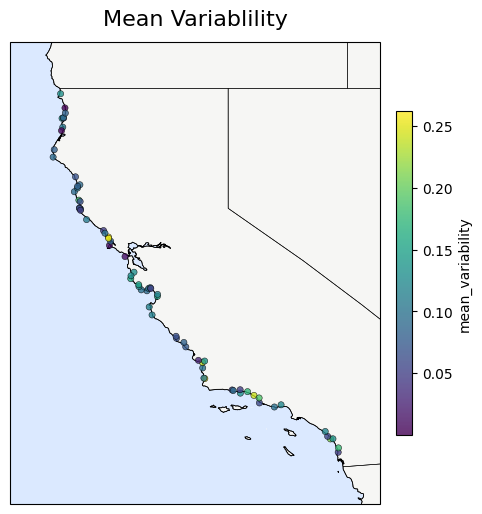

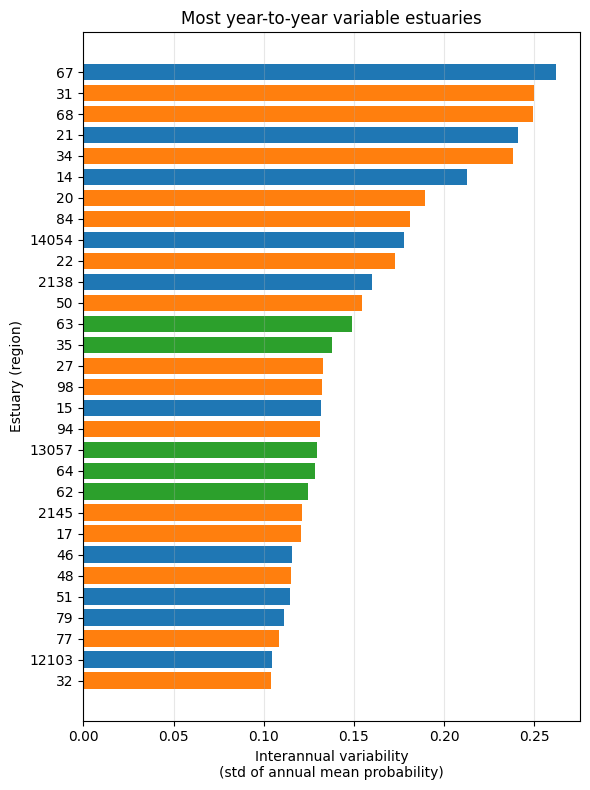

In [296]:
import numpy as np
import pandas as pd

pcols = ["p_closed", "p_perched_open", "p_open"]

tmp = full.reset_index()
tmp["date"] = pd.to_datetime(tmp["date"])
tmp["year"] = tmp["date"].dt.year  # swap to water year if desired

annual = tmp.groupby(["region", "year"])[pcols].mean().reset_index()

# std of annual means per class
interannual_std = annual.groupby("region")[pcols].std()

# overall variability score per estuary
interannual_std["mean_variability"] = interannual_std.mean(axis=1)

# sort
interannual_std = interannual_std.sort_values("mean_variability", ascending=False)

g = gdf_points.merge(interannual_std, on="region", how="left")

plot_estuaries_ca(
    g,
    column="mean_variability",
    # cmap="brg",
    title="Mean Variablility",
    markersize=20,
    jitter_deg=0.05,
    point_alpha=0.8,
    add_colorbar=True,
    show=True,
    # save_path=FIG_DIR / "state_map_dominant_class.png"
)

top_n = 30  # adjust

plot_df = interannual_std.head(top_n)

plt.figure(figsize=(6, 8))

dominant = annual.groupby("region")[pcols].mean().idxmax(axis=1)

colors = {
    "p_closed": "tab:orange",
    "p_perched_open": "tab:green",
    "p_open": "tab:blue",
}

bar_colors = dominant.loc[plot_df.index].map(colors)

plt.barh(plot_df.index.astype(str), plot_df["mean_variability"], color=bar_colors)

plt.gca().invert_yaxis()
plt.xlabel("Interannual variability\n(std of annual mean probability)")
plt.ylabel("Estuary (region)")
plt.title("Most year-to-year variable estuaries")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.savefig(FIG_DIR / "most_variable_estuaries_bar.png", dpi=200)
plt.show()

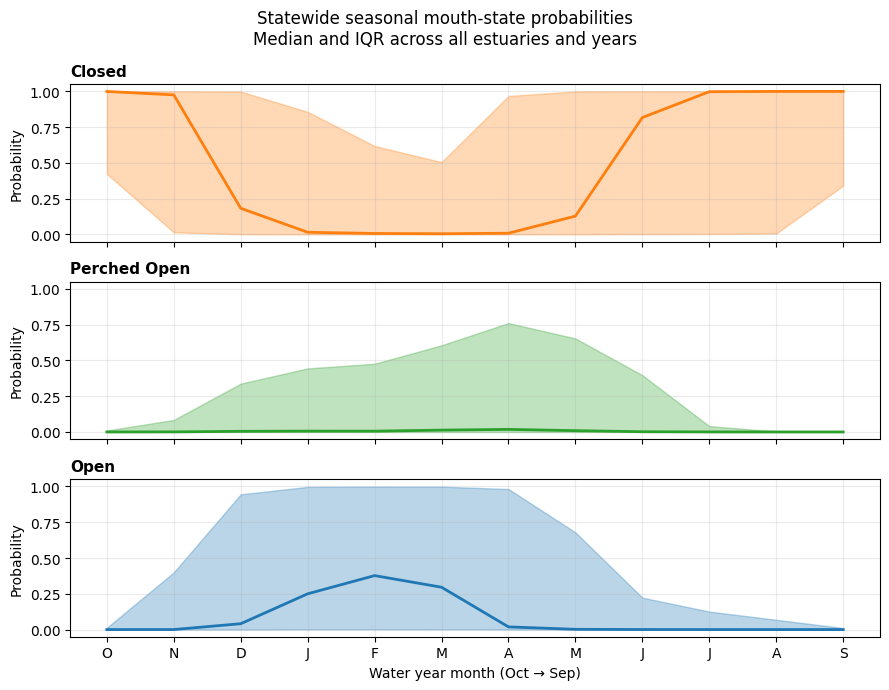

In [297]:
import numpy as np
import pandas as pd

tmp = full.reset_index()
tmp["date"] = pd.to_datetime(tmp["date"])

# Water-year month: Oct=0, ..., Sep=11
tmp["wy_month"] = (tmp["date"].dt.month - 10) % 12

pcols = ["p_closed", "p_perched_open", "p_open"]

q = tmp.groupby("wy_month")[pcols].quantile([0.25, 0.5, 0.75]).unstack()

# Rename quantiles
q = q.rename(columns={0.25: "q25", 0.5: "median", 0.75: "q75"}, level=1)

# Ensure consistent column order
q = q.reindex(columns=pd.MultiIndex.from_product([pcols, ["q25", "median", "q75"]]))

import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    3,
    1,
    figsize=(9, 7),
    sharex=True,
    # constrained_layout=True
)

labels = {
    "p_closed": "Closed",
    "p_perched_open": "Perched Open",
    "p_open": "Open",
}

colors = {
    "p_closed": "tab:orange",
    "p_perched_open": "tab:green",
    "p_open": "tab:blue",
}

months = np.arange(12)
month_labels = ["O", "N", "D", "J", "F", "M", "A", "M", "J", "J", "A", "S"]

for ax, p in zip(axes, pcols):
    ax.plot(
        months,
        q[(p, "median")],
        lw=2,
        color=colors[p],
    )
    ax.fill_between(months, q[(p, "q25")], q[(p, "q75")], color=colors[p], alpha=0.3, label="IQR")

    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel("Probability")
    ax.set_title(labels[p], loc="left", fontsize=11, weight="bold")
    ax.grid(alpha=0.25)

axes[-1].set_xticks(months)
axes[-1].set_xticklabels(month_labels)
axes[-1].set_xlabel("Water year month (Oct → Sep)")

plt.suptitle(
    "Statewide seasonal mouth-state probabilities\nMedian and IQR across all estuaries and years"
)
fig.tight_layout()
plt.savefig(FIG_DIR / "statewide_monthly_median_iqr_water_year.png", dpi=200)
plt.show()

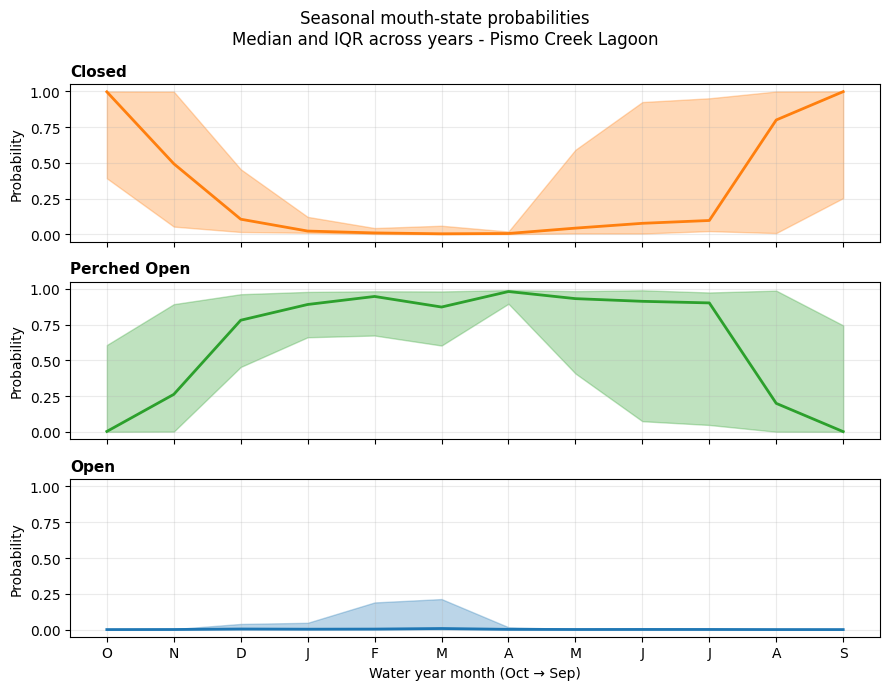

In [298]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

region = 35  # <-- pick your region 2145, 51, 13027, 11, 35

tmp = full.reset_index()
tmp["date"] = pd.to_datetime(tmp["date"])

# Filter to a single region
tmp = tmp[tmp["region"] == region].copy()

# Water-year month: Oct=0, ..., Sep=11
tmp["wy_month"] = (tmp["date"].dt.month - 10) % 12

pcols = ["p_closed", "p_perched_open", "p_open"]

q = tmp.groupby("wy_month")[pcols].quantile([0.25, 0.5, 0.75]).unstack()

# Rename quantiles
q = q.rename(columns={0.25: "q25", 0.5: "median", 0.75: "q75"}, level=1)

# Ensure consistent column order
q = q.reindex(columns=pd.MultiIndex.from_product([pcols, ["q25", "median", "q75"]]))

fig, axes = plt.subplots(
    3,
    1,
    figsize=(9, 7),
    sharex=True,
)

labels = {
    "p_closed": "Closed",
    "p_perched_open": "Perched Open",
    "p_open": "Open",
}

colors = {
    "p_closed": "tab:orange",
    "p_perched_open": "tab:green",
    "p_open": "tab:blue",
}

months = np.arange(12)
month_labels = ["O", "N", "D", "J", "F", "M", "A", "M", "J", "J", "A", "S"]

for ax, p in zip(axes, pcols):
    ax.plot(
        months,
        q[(p, "median")],
        lw=2,
        color=colors[p],
    )
    ax.fill_between(months, q[(p, "q25")], q[(p, "q75")], color=colors[p], alpha=0.3, label="IQR")

    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel("Probability")
    ax.set_title(labels[p], loc="left", fontsize=11, weight="bold")
    ax.grid(alpha=0.25)

axes[-1].set_xticks(months)
axes[-1].set_xticklabels(month_labels)
axes[-1].set_xlabel("Water year month (Oct → Sep)")

name = gdf.set_index("region").loc[region]["Estuary_Name"]

plt.suptitle(
    f"Seasonal mouth-state probabilities\nMedian and IQR across years - {name}",
)
fig.tight_layout()
name = "_".join([n.lower() for n in name.split(" ")])
plt.savefig(FIG_DIR / f"{name}_monthly_median_iqr_water_year.png", dpi=200)
plt.show()

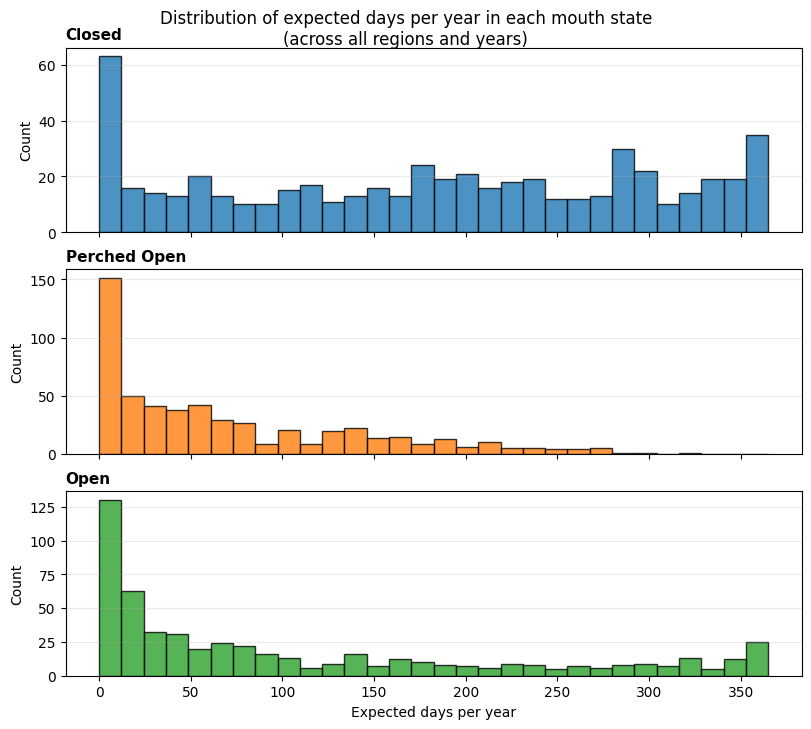

In [299]:
import numpy as np
import pandas as pd

pcols = ["p_closed", "p_perched_open", "p_open"]

tmp = full.reset_index()
tmp["date"] = pd.to_datetime(tmp["date"])
tmp["year"] = tmp["date"].dt.year

# Expected days = sum of probabilities within each (region, year)
expected_days = tmp.groupby(["region", "year"])[pcols].sum().reset_index()

import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(8, 7), sharex=True, constrained_layout=True)

labels = {
    "p_closed": "Closed",
    "p_perched_open": "Perched Open",
    "p_open": "Open",
}

colors = {
    "p_closed": "tab:blue",
    "p_perched_open": "tab:orange",
    "p_open": "tab:green",
}

bins = np.linspace(0, 365, 31)  # ~12-day bins

for ax, p in zip(axes, pcols):
    ax.hist(expected_days[p], bins=bins, color=colors[p], alpha=0.8, edgecolor="black")
    ax.set_ylabel("Count")
    ax.set_title(labels[p], loc="left", fontsize=11, weight="bold")
    ax.grid(axis="y", alpha=0.25)

axes[-1].set_xlabel("Expected days per year")

plt.suptitle(
    "Distribution of expected days per year in each mouth state\n(across all regions and years)",
    y=1.02,
)

# plt.savefig(FIG_DIR / "hist_expected_days_per_year_by_class.png", dpi=200)
plt.show()

In [300]:
import numpy as np
import pandas as pd

P_COLS = ["p_closed", "p_perched_open", "p_open"]

KEY_TRANSITIONS = [
    ("p_closed", "p_closed"),
    ("p_closed", "p_perched_open"),
    ("p_closed", "p_open"),
    ("p_perched_open", "p_perched_open"),
    ("p_perched_open", "p_closed"),
    ("p_perched_open", "p_open"),
    ("p_open", "p_open"),
    ("p_open", "p_perched_open"),
    ("p_open", "p_closed"),
]


def expected_transition_mass(
    df: pd.DataFrame,
    pcols=P_COLS,
    transitions=KEY_TRANSITIONS,
    lag: int = 1,
    normalize: str | None = None,
) -> pd.DataFrame:
    """
    Compute expected transition mass T_{a->b} = sum_t p_a(t) * p_b(t+lag).

    Parameters
    ----------
    df : DataFrame
        Must be indexed by datetime (single region), sorted by time.
        Must contain probability columns in `pcols`.
    pcols : list[str]
        Probability column names.
    transitions : list[tuple[str,str]]
        List of (a,b) transitions to compute.
    lag : int
        Shift for next-step (default 1).
    normalize : {'outflow', 'total', None}
        - None: raw mass
        - 'outflow': divide each row by sum_t p_a(t) (mass leaving a)
        - 'total': divide all masses by sum over all a,b masses

    Returns
    -------
    DataFrame with columns: ['from','to','mass','mass_norm'] (mass_norm optional)
    """
    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError("df must have a DatetimeIndex (single region time series).")
    if not df.index.is_monotonic_increasing:
        df = df.sort_index()

    # Keep only needed columns and drop rows with missing probs
    X = df[list(pcols)].astype(float).copy()

    # Align t and t+lag (drop last lag rows)
    A = X.iloc[:-lag].to_numpy()
    B = X.shift(-lag).iloc[:-lag].to_numpy()

    col_to_idx = {c: i for i, c in enumerate(pcols)}

    out = []
    for a, b in transitions:
        ia = col_to_idx[a]
        ib = col_to_idx[b]
        mass = float(np.sum(A[:, ia] * B[:, ib]))
        out.append({"from": a, "to": b, "mass": mass})

    res = pd.DataFrame(out)

    if normalize is None:
        return res

    if normalize == "outflow":
        # Normalize each (a->b) by total mass in a across time (sum_t p_a(t))
        denom = {a: float(np.sum(A[:, col_to_idx[a]])) for a, _ in transitions}
        res["mass_norm"] = res.apply(
            lambda r: r["mass"] / denom[r["from"]] if denom[r["from"]] > 0 else np.nan, axis=1
        )
        return res

    if normalize == "total":
        total = res["mass"].sum()
        res["mass_norm"] = res["mass"] / total if total > 0 else np.nan
        return res

    raise ValueError("normalize must be one of {None, 'outflow', 'total'}")


region = 2145
df_r = full.loc[region].sort_index()

T = expected_transition_mass(df_r, normalize="outflow")
T

,from,to,mass,mass_norm
0,p_closed,p_closed,1187.085688,0.953821
1,p_closed,p_perched_open,33.588369,0.026988
2,p_closed,p_open,23.884129,0.019191
3,p_perched_open,p_perched_open,292.928062,0.663856
4,p_perched_open,p_closed,44.310641,0.100420
5,p_perched_open,p_open,104.013748,0.235724
6,p_open,p_open,1093.292992,0.895269
7,p_open,p_perched_open,114.734700,0.093953
8,p_open,p_closed,13.161670,0.010778


In [301]:
# Per-region transition table
per_region = []
for region, g in full.groupby(level="region"):
    df_r = g.droplevel("region").sort_index()
    T = expected_transition_mass(df_r, normalize="outflow")
    T["region"] = region
    per_region.append(T)

per_region = pd.concat(per_region, ignore_index=True)

# Statewide mean of normalized transition masses (across regions)
statewide = (
    per_region.groupby(["from", "to"])["mass_norm"].mean().rename("mean_mass_norm").reset_index()
)

statewide

,from,to,mean_mass_norm
0,p_closed,p_closed,0.864578
1,p_closed,p_open,0.063435
2,p_closed,p_perched_open,0.071987
3,p_open,p_closed,0.063366
4,p_open,p_open,0.737208
5,p_open,p_perched_open,0.199426
6,p_perched_open,p_closed,0.188392
7,p_perched_open,p_open,0.206549
8,p_perched_open,p_perched_open,0.605059


In [302]:
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "notebook_connected"

# df columns: from, to, mean_mass_norm
df = statewide

label_map = {
    "p_closed": "Closed",
    "p_perched_open": "Perched Open",
    "p_open": "Open",
}

# 2-layer nodes (duplicate): left = sources, right = targets
left_nodes = [f"{label_map[s]} (t)" for s in ["p_closed", "p_perched_open", "p_open"]]
right_nodes = [f"{label_map[s]} (t+1)" for s in ["p_closed", "p_perched_open", "p_open"]]
nodes = left_nodes + right_nodes

idx_left = {k: i for i, k in enumerate(["p_closed", "p_perched_open", "p_open"])}
idx_right = {k: i + len(left_nodes) for i, k in enumerate(["p_closed", "p_perched_open", "p_open"])}

sources = df["from"].map(idx_left).tolist()
targets = df["to"].map(idx_right).tolist()
values = df["mean_mass_norm"].tolist()

# optional: color by destination state (nice for interpretation)
color_map = {
    "p_closed": "rgba(255,127,14,0.55)",  # orange
    "p_perched_open": "rgba(44,160,44,0.55)",  # green
    "p_open": "rgba(31,119,180,0.55)",  # blue
}
link_colors = df["to"].map(color_map).tolist()

fig = go.Figure(
    go.Sankey(
        arrangement="fixed",
        node=dict(
            pad=20,
            thickness=25,
            label=nodes,
            color=[
                "rgba(255,127,14,0.85)",
                "rgba(44,160,44,0.85)",
                "rgba(31,119,180,0.85)",  # left
                "rgba(255,127,14,0.85)",
                "rgba(44,160,44,0.85)",
                "rgba(31,119,180,0.85)",  # right
            ],
            line=dict(color="black", width=1),
            # fixed positions (optional but makes it stable)
            x=[0.02, 0.02, 0.02, 0.98, 0.98, 0.98],
            y=[0.15, 0.50, 0.85, 0.15, 0.50, 0.85],
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=link_colors,
            hovertemplate="%{source.label} → %{target.label}<br>%{value:.3f}<extra></extra>",
        ),
    )
)

fig.update_layout(
    title="Expected transition mass (outflow-normalized), statewide mean",
    font=dict(size=14),
    width=900,
    height=450,
)
fig.write_image(
    FIG_DIR / "transition_sankey.png",
    width=800,
    height=400,
    scale=2,  # increases resolution
)
fig.show()

In [303]:
import pandas as pd

# your results table
df = statewide


def get(df, a, b):
    return df.loc[(df["from"] == a) & (df["to"] == b), "mean_mass_norm"].iloc[0]


eps = 1e-6

inflow = get(df, "p_closed", "p_perched_open") + get(df, "p_open", "p_perched_open")
outflow = get(df, "p_perched_open", "p_closed") + get(df, "p_perched_open", "p_open")
direct = get(df, "p_closed", "p_open") + get(df, "p_open", "p_closed")

mediator_index = (inflow * outflow) / (direct + eps)

mediator_index

np.float64(0.8453496115771427)

/var/folders/pr/1dt1qk511zdgzhfy1xskpqm00000gn/T/ipykernel_31995/2158620866.py:15: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



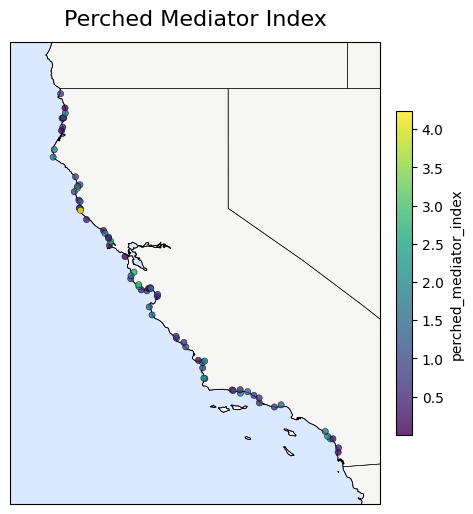

<Axes: xlabel='mean_variability', ylabel='perched_mediator_index'>

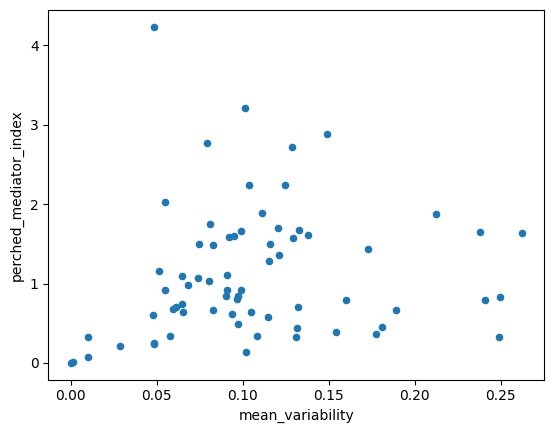

In [304]:
def mediator_index_from_table(T):
    eps = 1e-6

    def g(a, b):
        return T.loc[(T["from"] == a) & (T["to"] == b), "mass_norm"].iloc[0]

    inflow = g("p_closed", "p_perched_open") + g("p_open", "p_perched_open")
    outflow = g("p_perched_open", "p_closed") + g("p_perched_open", "p_open")
    direct = g("p_closed", "p_open") + g("p_open", "p_closed")

    return (inflow * outflow) / (direct + eps)


mediator = (
    per_region.groupby("region")
    .apply(mediator_index_from_table)
    .rename("perched_mediator_index")
    .reset_index()
)

g = gdf_points.merge(mediator, on="region", how="left")

plot_estuaries_ca(
    g,
    column="perched_mediator_index",
    # cmap="brg",
    title="Perched Mediator Index",
    markersize=20,
    jitter_deg=0.05,
    point_alpha=0.8,
    add_colorbar=True,
    show=True,
    # save_path=FIG_DIR / "state_map_dominant_class.png"
)

df = pd.merge(interannual_std, mediator, on="region")

df.plot.scatter(x="mean_variability", y="perched_mediator_index")

In [305]:
mediator.sort_values("perched_mediator_index", ascending=False)

,region,perched_mediator_index
64,13028,4.235260
46,86,3.216866
32,63,2.884449
35,66,2.772911
33,64,2.725422
...,...,...
67,13099,0.215354
28,56,0.130902
57,2147,0.077460
60,12105,0.013819


In [306]:
import numpy as np
import pandas as pd

pcols = ["p_closed", "p_perched_open", "p_open"]

STATE_MAP = {
    0: "closed",
    1: "perched",
    2: "open",
}

N = 4  # days

tmp = full.reset_index()
tmp["date"] = pd.to_datetime(tmp["date"])

# dominant state
tmp["state"] = tmp[pcols].values.argmax(axis=1)
tmp["state_name"] = tmp["state"].map(STATE_MAP)


def get_runs(df):
    df = df.sort_values("date").copy()
    df["run_id"] = (df["state"] != df["state"].shift()).cumsum()

    runs = (
        df.groupby("run_id")
        .agg(
            state=("state_name", "first"),
            start=("date", "first"),
            end=("date", "last"),
            duration=("date", "size"),
        )
        .reset_index(drop=True)
    )

    # carry region through (df has a single region)
    runs["region"] = df["region"].iloc[0]
    return runs[["region", "state", "start", "end", "duration"]]


runs = tmp.groupby("region", group_keys=False).apply(get_runs).reset_index(drop=True)

runs

/var/folders/pr/1dt1qk511zdgzhfy1xskpqm00000gn/T/ipykernel_31995/1858517678.py:41: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,region,state,start,end,duration
0,11,open,2018-01-01,2018-01-19,19
1,11,closed,2018-01-20,2018-01-25,6
2,11,open,2018-01-26,2018-02-21,27
3,11,perched,2018-02-22,2018-02-22,1
4,11,open,2018-02-23,2018-04-04,41
...,...,...,...,...,...
7948,14054,closed,2025-04-01,2025-04-17,17
7949,14054,perched,2025-04-18,2025-04-24,7
7950,14054,open,2025-04-25,2025-05-04,10
7951,14054,closed,2025-05-05,2025-06-24,51


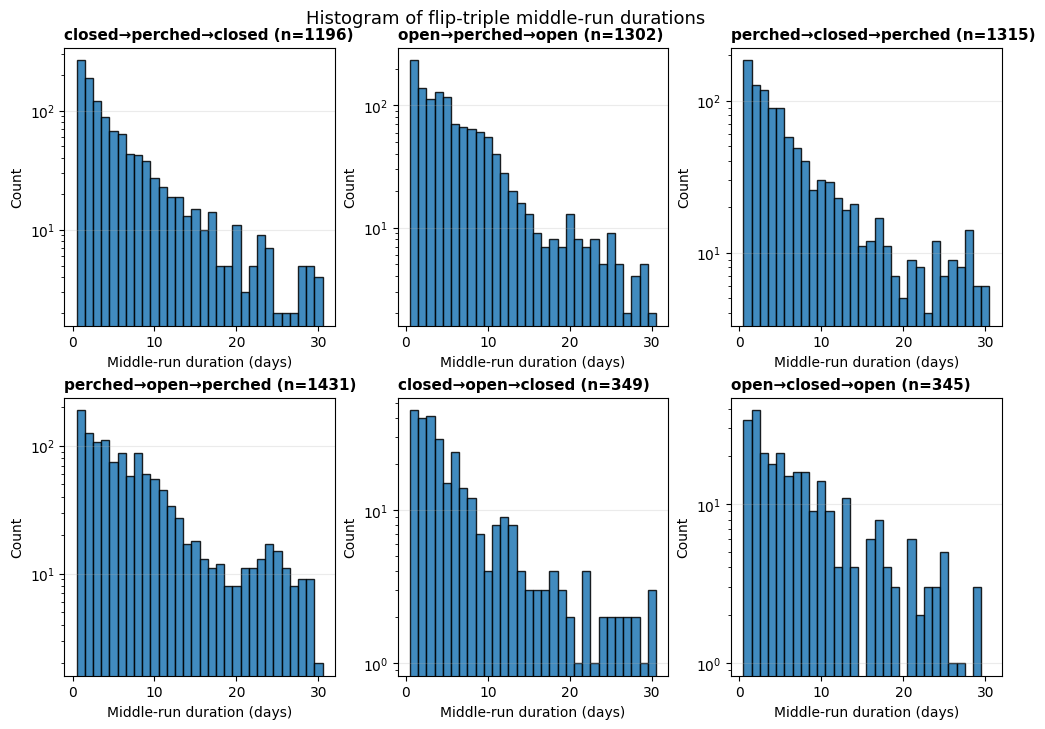

In [307]:
from collections import defaultdict

# store durations for the middle run of each pattern
durs = defaultdict(list)

for region, g in runs.groupby("region", sort=False):
    g = g.reset_index(drop=True)

    for i in range(1, len(g) - 1):
        prev, cur, nxt = g.loc[i - 1], g.loc[i], g.loc[i + 1]

        # closed → perched → closed : record perched duration
        if prev.state == "closed" and cur.state == "perched" and nxt.state == "closed":
            durs["closed→perched→closed"].append(cur.duration)

        # open → perched → open : record perched duration
        if prev.state == "open" and cur.state == "perched" and nxt.state == "open":
            durs["open→perched→open"].append(cur.duration)

        # perched → closed → perched : record closed duration
        if prev.state == "perched" and cur.state == "closed" and nxt.state == "perched":
            durs["perched→closed→perched"].append(cur.duration)

        # perched → open → perched : record open duration
        if prev.state == "perched" and cur.state == "open" and nxt.state == "perched":
            durs["perched→open→perched"].append(cur.duration)

        # closed → open → closed : record open duration
        if prev.state == "closed" and cur.state == "open" and nxt.state == "closed":
            durs["closed→open→closed"].append(cur.duration)

        # open → closed → open : record open duration
        if prev.state == "open" and cur.state == "closed" and nxt.state == "open":
            durs["open→closed→open"].append(cur.duration)

import matplotlib.pyplot as plt

patterns = [
    "closed→perched→closed",
    "open→perched→open",
    "perched→closed→perched",
    "perched→open→perched",
    "closed→open→closed",
    "open→closed→open",
]

fig, axes = plt.subplots(2, 3, figsize=(10, 7), constrained_layout=True)
axes = axes.ravel()

# choose bins up to, say, 30 days (adjust as needed)
max_bin = 30
bins = np.arange(1, max_bin + 2) - 0.5  # centers on integers

for ax, pat in zip(axes, patterns):
    data = np.array(durs.get(pat, []), dtype=int)

    if data.size == 0:
        ax.text(0.5, 0.5, "No events", ha="center", va="center")
        ax.set_title(pat)
        ax.set_axis_off()
        continue

    ax.hist(data, bins=bins, alpha=0.85, edgecolor="black")
    ax.set_title(f"{pat} (n={len(data)})", loc="left", fontsize=11, weight="bold")
    ax.set_xlabel("Middle-run duration (days)")
    ax.set_ylabel("Count")
    ax.set_yscale("log")  # comment out if you hate log
    ax.grid(axis="y", alpha=0.25)

plt.suptitle("Histogram of flip-triple middle-run durations", y=1.02, fontsize=13)
plt.show()

In [308]:
import numpy as np
import pandas as pd

pcols = ["p_closed", "p_perched_open", "p_open"]

STATE_MAP = {0: "closed", 1: "perched", 2: "open"}
INV_STATE_MAP = {v: k for k, v in STATE_MAP.items()}

STICKY_DAYS = 5

tmp = full.reset_index()
tmp["date"] = pd.to_datetime(tmp["date"])
tmp["state"] = tmp[pcols].values.argmax(axis=1)
tmp["state_name"] = tmp["state"].map(STATE_MAP)


def get_runs(df):
    df = df.sort_values("date").copy()
    df["run_id"] = (df["state"] != df["state"].shift()).cumsum()

    runs = (
        df.groupby("run_id")
        .agg(
            state=("state_name", "first"),
            start=("date", "first"),
            end=("date", "last"),
            duration=("date", "size"),
        )
        .reset_index(drop=True)
    )

    runs["region"] = df["region"].iloc[0]
    return runs[["region", "state", "start", "end", "duration"]]


runs = tmp.groupby("region", group_keys=False).apply(get_runs).reset_index(drop=True)


def recompute_runs_from_new_state(runs):
    out = []

    for region, g in runs.groupby("region", sort=False):
        g = g.sort_values("start").copy()

        g["group"] = (g["new_state"] != g["new_state"].shift()).cumsum()

        merged = (
            g.groupby("group")
            .agg(
                region=("region", "first"),
                state=("new_state", "first"),
                start=("start", "first"),
                end=("end", "last"),
                duration=("duration", "sum"),
            )
            .reset_index(drop=True)
        )

        merged["new_state"] = merged["state"]
        out.append(merged)

    return pd.concat(out, ignore_index=True)


def smooth_runs_iterative(runs, sticky_days=5):
    runs = runs.copy()

    changed = True
    while changed:
        changed = False

        for region, g in runs.groupby("region", sort=False):
            idx = g.index.to_numpy()

            for i in range(1, len(g) - 1):
                prev = g.loc[idx[i - 1]]
                cur = g.loc[idx[i]]
                nxt = g.loc[idx[i + 1]]

                if (
                    prev.new_state == nxt.new_state
                    and cur.new_state != prev.new_state
                    and cur.duration < sticky_days
                ):
                    if runs.loc[idx[i], "new_state"] != prev.new_state:
                        runs.loc[idx[i], "new_state"] = prev.new_state
                        changed = True

        # After relabeling, recompute runs so adjacency is updated
        runs = recompute_runs_from_new_state(runs)

    return runs


runs["new_state"] = runs["state"]
runs = smooth_runs_iterative(runs)


def expand_runs(runs_df):
    rows = []

    for _, r in runs_df.iterrows():
        dates = pd.date_range(r.start, r.end, freq="D")
        rows.append(
            pd.DataFrame(
                {
                    "region": r.region,
                    "date": dates,
                    "state_name_smooth": r.new_state,
                    "state_smooth": INV_STATE_MAP[r.new_state],
                }
            )
        )

    return pd.concat(rows, ignore_index=True)


smoothed_states = expand_runs(runs)

full_smooth = (
    full.reset_index()
    .merge(smoothed_states, on=["region", "date"], how="left")
    .set_index(["region", "date"])
    .sort_index()
)

/var/folders/pr/1dt1qk511zdgzhfy1xskpqm00000gn/T/ipykernel_31995/2874286348.py:36: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [309]:
full_smooth["original"] = full["y_pred"]
full_smooth["smoothed"] = full_smooth["state_smooth"]
full_smooth["state_name"] = full_smooth["original"].map(STATE_MAP)

pd.crosstab(
    full_smooth["state_name"],
    full_smooth["state_name_smooth"],
    rownames=["original"],
    colnames=["smoothed"],
)

smoothed,closed,open,perched
original,,,
closed,99294,229,1009
open,330,60047,1054
perched,1238,1232,36219


/var/folders/pr/1dt1qk511zdgzhfy1xskpqm00000gn/T/ipykernel_31995/1534483478.py:32: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



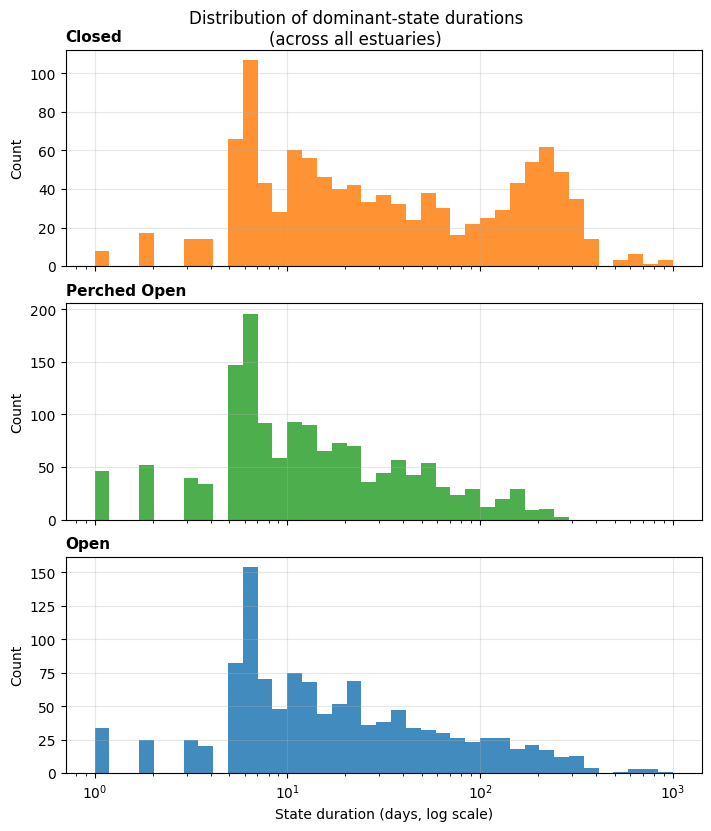

In [310]:
import numpy as np
import pandas as pd

pcols = ["p_closed", "p_perched_open", "p_open"]
state_labels = {
    0: "Closed",
    1: "Perched Open",
    2: "Open",
}

tmp = full_smooth.reset_index()
tmp["date"] = pd.to_datetime(tmp["date"])

# dominant state (argmax)
tmp["state"] = tmp["state_smooth"]


def state_durations(df):
    df = df.sort_values("date").copy()

    # identify change points
    df["new_run"] = (df["state"] != df["state"].shift()).cumsum()

    runs = df.groupby(["new_run", "state"]).size().reset_index(name="duration_days")
    return runs[["state", "duration_days"]]


durations = tmp.groupby("region", group_keys=False).apply(state_durations).reset_index(drop=True)

durations["state_name"] = durations["state"].map(state_labels)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(7, 8), sharex=True, constrained_layout=True)

colors = {
    "Closed": "tab:orange",
    "Perched Open": "tab:green",
    "Open": "tab:blue",
}

bins = np.logspace(0, 3, 40)  # 1 to 1000 days

for ax, state in zip(axes, ["Closed", "Perched Open", "Open"]):
    data = durations.loc[durations["state_name"] == state, "duration_days"]

    ax.hist(data, bins=bins, color=colors[state], alpha=0.85)

    ax.set_xscale("log")
    ax.set_ylabel("Count")
    ax.set_title(state, loc="left", fontsize=11, weight="bold")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("State duration (days, log scale)")

plt.suptitle("Distribution of dominant-state durations\n(across all estuaries)", y=1.02)

plt.savefig(FIG_DIR / "hist_state_duration_log.png", dpi=200)
plt.show()

In [311]:
import pandas as pd


def extract_events(df):
    """
    df: single-region dataframe with columns
        - date
        - state_name_smooth
    """
    df = df.sort_values("date").copy()

    df["event_id"] = (df["state_name_smooth"] != df["state_name_smooth"].shift()).cumsum()

    events = (
        df.groupby("event_id")
        .agg(
            region=("region", "first"),
            state=("state_name_smooth", "first"),
            start=("date", "first"),
            end=("date", "last"),
            duration=("date", "size"),
        )
        .reset_index(drop=True)
    )

    # add previous / next state
    events["prev_state"] = events["state"].shift()
    events["next_state"] = events["state"].shift(-1)

    return events


events = (
    full_smooth.reset_index()
    .groupby("region", group_keys=False)
    .apply(extract_events)
    .reset_index(drop=True)
)


def classify_transition(row):
    p, c, n = row.prev_state, row.state, row.next_state

    if pd.isna(p) or pd.isna(n):
        return None

    # mediated openings / closures
    if p == "closed" and c == "perched" and n == "open":
        return "closed→perched→open"
    if p == "open" and c == "perched" and n == "closed":
        return "open→perched→closed"

    # failed transitions
    if p == "closed" and c == "perched" and n == "closed":
        return "closed→perched→closed"
    if p == "open" and c == "perched" and n == "open":
        return "open→perched→open"

    # direct transitions
    if c == "closed" and n == "open":
        return "closed→open"
    if c == "open" and n == "closed":
        return "open→closed"

    return None


events["transition_type"] = events.apply(classify_transition, axis=1)

event_transitions = events.dropna(subset=["transition_type"]).copy()

counts = (
    event_transitions["transition_type"]
    .value_counts()
    .rename("count")
    .reset_index()
    .rename(columns={"index": "transition"})
)
counts["fraction"] = counts["count"] / counts["count"].sum()
counts

/var/folders/pr/1dt1qk511zdgzhfy1xskpqm00000gn/T/ipykernel_31995/2090643201.py:37: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,transition_type,count,fraction
0,closed→open,505,0.230594
1,open→perched→open,464,0.211872
2,open→perched→closed,423,0.193151
3,closed→perched→closed,373,0.170320
4,open→closed,259,0.118265
5,closed→perched→open,166,0.075799


In [312]:
counts = event_transitions.groupby("transition_type").duration.agg(
    avg_duration="mean",
    std_duration="std",
)
counts

,avg_duration,std_duration
transition_type,,
closed→open,91.704950,139.113299
closed→perched→closed,30.474531,43.809614
closed→perched→open,20.518072,26.589978
open→closed,61.872587,126.739047
open→perched→closed,35.148936,47.120890
open→perched→open,15.150862,19.701741


<Figure size 1000x500 with 0 Axes>

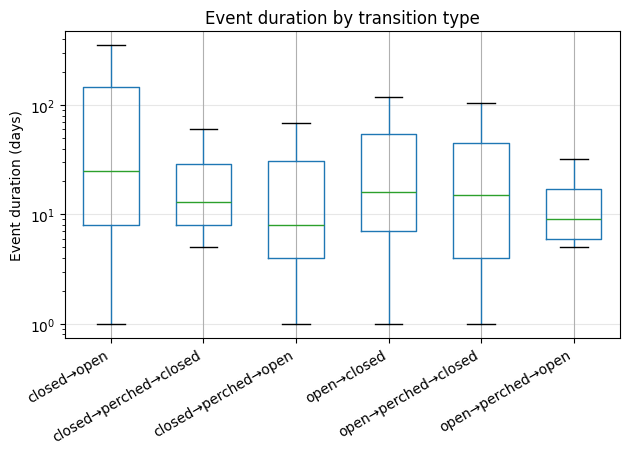

In [313]:
import matplotlib.pyplot as plt

# Order transitions by median duration (reads much better)
order = (
    event_transitions.groupby("transition_type")["duration"]
    .median()
    # .sort_values()
    .index
)

plt.figure(figsize=(10, 5))

event_transitions.boxplot(
    column="duration",
    by="transition_type",
    # positions=range(len(order)),
    widths=0.6,
    showfliers=False,  # hide extreme outliers (important)
)

# # Matplotlib's boxplot doesn't respect order automatically,
# # so we re-label the x-axis explicitly
plt.xticks(ticks=range(1, len(order) + 1), labels=order, rotation=30, ha="right")

plt.ylabel("Event duration (days)")
plt.xlabel("")
plt.title("Event duration by transition type")
plt.suptitle("")  # remove pandas default title
plt.grid(axis="y", alpha=0.3)
plt.yscale("log")

plt.tight_layout()
plt.savefig(FIG_DIR / "boxplot_event_duration_by_transition.png", dpi=200)
plt.show()

In [314]:
per_region = (
    event_transitions.groupby(["region", "transition_type"]).size().rename("count").reset_index()
)
per_region["fraction"] = per_region.groupby("region")["count"].transform(lambda x: x / x.sum())

event_transitions["category"] = event_transitions["transition_type"].map(
    lambda x: "mediated" if "perched" in x and "→" in x else "direct"
)

display(event_transitions["category"].value_counts(normalize=True))

event_transitions["outcome"] = event_transitions["transition_type"].map(
    {
        "closed→perched→open": "successful_opening",
        "open→perched→closed": "successful_closure",
        "closed→perched→closed": "failed_opening",
        "open→perched→open": "failed_closure",
    }
)

event_transitions["outcome"].value_counts(normalize=True)

category
mediated    0.651142
direct      0.348858
Name: proportion, dtype: float64

outcome
failed_closure        0.325386
successful_closure    0.296634
failed_opening        0.261571
successful_opening    0.116410
Name: proportion, dtype: float64

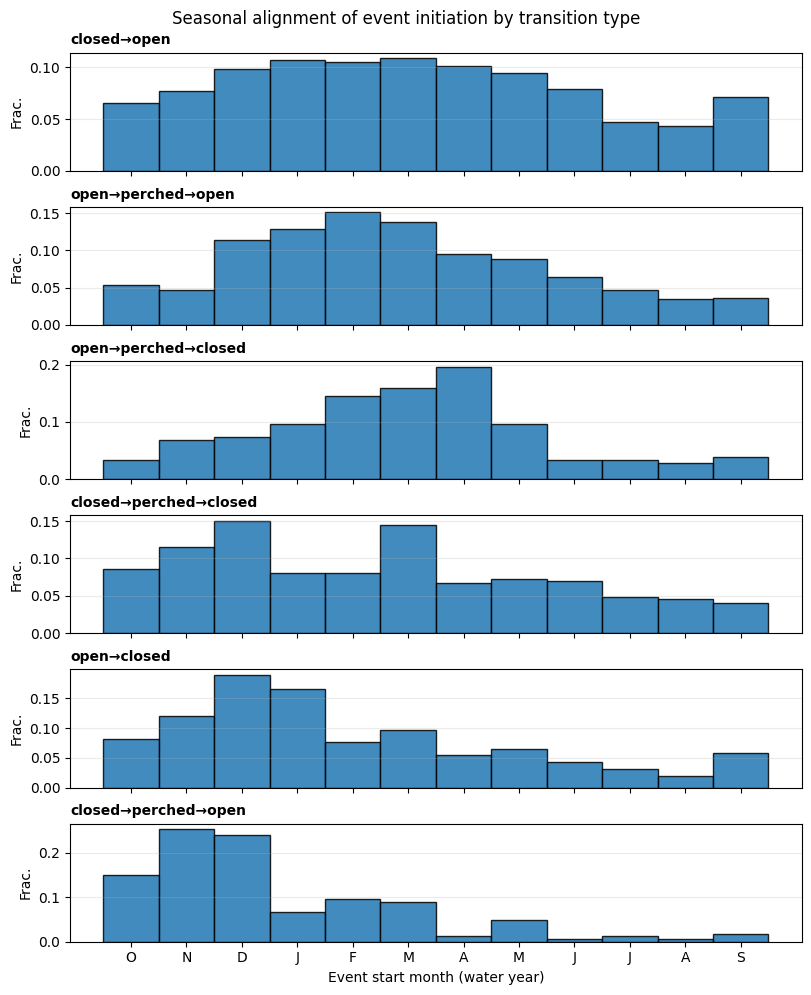

In [315]:
import numpy as np
import pandas as pd

events = events.copy()
events["start"] = pd.to_datetime(events["start"])
events["end"] = pd.to_datetime(events["end"])

# Water-year month for event start
events["wy_month_start"] = (events["start"].dt.month - 10) % 12
events["wy_month_end"] = (events["end"].dt.month - 10) % 12

WY_LABELS = ["O", "N", "D", "J", "F", "M", "A", "M", "J", "J", "A", "S"]

import matplotlib.pyplot as plt

transition_order = events["transition_type"].value_counts().index

fig, axes = plt.subplots(
    len(transition_order),
    1,
    figsize=(8, 1.6 * len(transition_order)),
    sharex=True,
    constrained_layout=True,
)

if len(transition_order) == 1:
    axes = [axes]

for ax, ttype in zip(axes, transition_order):
    g = events.loc[events["transition_type"] == ttype, "wy_month_start"]

    ax.hist(g, bins=np.arange(13) - 0.5, density=True, alpha=0.85, edgecolor="black")

    ax.set_ylabel("Frac.")
    ax.set_title(ttype, loc="left", fontsize=10, weight="bold")
    ax.grid(axis="y", alpha=0.25)

axes[-1].set_xticks(range(12))
axes[-1].set_xticklabels(WY_LABELS)
axes[-1].set_xlabel("Event start month (water year)")

plt.suptitle("Seasonal alignment of event initiation by transition type", y=1.02)

plt.savefig(FIG_DIR / "seasonal_event_start_by_transition.png", dpi=200)
plt.show()

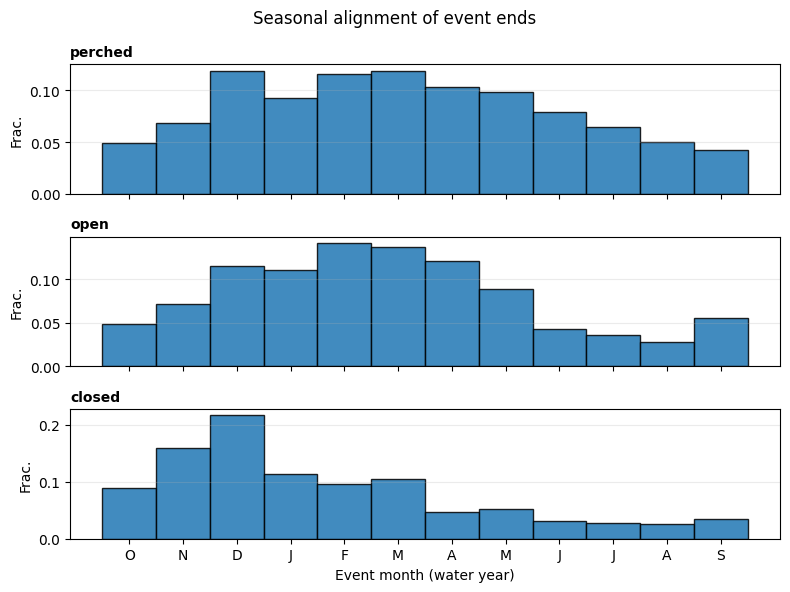

In [316]:
import numpy as np
import pandas as pd

events = events.copy()
events["start"] = pd.to_datetime(events["start"])
events["end"] = pd.to_datetime(events["end"])

# Water-year month for event start
events["wy_month_start"] = (events["start"].dt.month - 10) % 12
events["wy_month_end"] = (events["end"].dt.month - 10) % 12

WY_LABELS = ["O", "N", "D", "J", "F", "M", "A", "M", "J", "J", "A", "S"]

import matplotlib.pyplot as plt

order = events["state"].value_counts().index

fig, axes = plt.subplots(
    len(order),
    1,
    figsize=(8, 2 * len(order)),
    sharex=True,
    # constrained_layout=True
)

if len(order) == 1:
    axes = [axes]

for ax, ttype in zip(axes, order):
    g = events.loc[events["state"] == ttype, "wy_month_end"]

    ax.hist(g, bins=np.arange(13) - 0.5, density=True, alpha=0.85, edgecolor="black")

    ax.set_ylabel("Frac.")
    ax.set_title(ttype, loc="left", fontsize=10, weight="bold")
    ax.grid(axis="y", alpha=0.25)

axes[-1].set_xticks(range(12))
axes[-1].set_xticklabels(WY_LABELS)
axes[-1].set_xlabel("Event month (water year)")

plt.suptitle(
    "Seasonal alignment of event ends",
    # y=1.02
)
fig.tight_layout()
plt.savefig(FIG_DIR / "seasonal_event_end_counts.png", dpi=200)
plt.show()

In [317]:
import numpy as np
import pandas as pd

# Build a lookup: region_id -> PMEP_Region (North/Central/South)
region_to_pmep = gdf.set_index("region")["PMEP_Region"]

events2 = events.copy()
events2["PMEP_Region"] = events2["region"].map(region_to_pmep)

# keep only those with a PMEP label
events2 = events2.dropna(subset=["PMEP_Region"])

openings = events2.loc[events2["prev_state"] == "closed", ["region", "start", "PMEP_Region"]].copy()

closings = events2.loc[
    (events2["state"] == "closed") & (~events2.prev_state.isna()),
    ["region", "start", "PMEP_Region"],
].copy()

openings["start"] = pd.to_datetime(openings["start"])
closings["start"] = pd.to_datetime(closings["start"])


def coherence_counts_unique(event_df, window=7):
    event_df = event_df.sort_values("start").copy()
    starts = event_df["start"].values.astype("datetime64[D]")
    regs = event_df["region"].values

    counts = np.zeros(len(event_df), dtype=int)

    for i in range(len(event_df)):
        t = starts[i]
        r = regs[i]
        dt = np.abs((starts - t).astype("timedelta64[D]").astype(int))
        mask = (dt > 0) & (dt <= window) & (regs != r)
        counts[i] = len(np.unique(regs[mask]))

    return counts


def coherence_index_from_counts(counts, n_estuaries):
    # fraction of other estuaries that co-occur within window, averaged over events
    if n_estuaries <= 1 or len(counts) == 0:
        return np.nan
    return counts.mean() / (n_estuaries - 1)


def coherence_index(event_df, n_estuaries, window=7):
    counts = coherence_counts_unique(event_df, window=window)
    return coherence_index_from_counts(counts, n_estuaries)


def permuted_null_coherence(event_df, n_estuaries, window=7, n_perm=200, seed=0):
    rng = np.random.default_rng(seed)
    dates = event_df["start"].values.astype("datetime64[D]")

    vals = []
    for _ in range(n_perm):
        perm_dates = rng.permutation(dates)
        fake = event_df.copy()
        fake["start"] = perm_dates
        vals.append(coherence_index(fake, n_estuaries, window=window))

    return np.array(vals)


def coherence_by_segment(event_df, window=7, n_perm=200):
    out = []
    for seg, g in event_df.groupby("PMEP_Region"):
        n_est = g["region"].nunique()
        obs = coherence_index(g[["region", "start"]], n_est, window=window)

        null = permuted_null_coherence(
            g[["region", "start"]],
            n_estuaries=n_est,
            window=window,
            n_perm=n_perm,
            seed=0,
        )

        out.append(
            {
                "PMEP_Region": seg,
                "n_estuaries": n_est,
                "n_events": len(g),
                "window_days": window,
                "obs": obs,
                "null_mean": float(np.nanmean(null)),
                "null_p95": float(np.nanpercentile(null, 95)),
                "null_p05": float(np.nanpercentile(null, 5)),
                "z": (obs - np.nanmean(null)) / (np.nanstd(null) + 1e-12),
            }
        )
    return pd.DataFrame(out).sort_values("PMEP_Region")


window = 7  # try 2 or 3 later for stricter simultaneity

open_seg = coherence_by_segment(openings, window=window, n_perm=200)
close_seg = coherence_by_segment(closings, window=window, n_perm=200)

display(open_seg)
close_seg

,PMEP_Region,n_estuaries,n_events,window_days,obs,null_mean,null_p95,null_p05,z
0,Central California,43,751,7,0.173546,0.147812,0.151184,0.143425,10.920339
1,Southern California Bight,15,214,7,0.142523,0.121143,0.127186,0.115137,5.788791
2,"Washington, Oregon, Northern California Coast",6,82,7,0.102439,0.076793,0.095122,0.058537,2.440091


,PMEP_Region,n_estuaries,n_events,window_days,obs,null_mean,null_p95,null_p05,z
0,Central California,43,756,7,0.100277,0.093057,0.094641,0.091396,6.809265
1,Southern California Bight,15,211,7,0.092417,0.081435,0.085985,0.075812,3.549940
2,"Washington, Oregon, Northern California Coast",6,85,7,0.084706,0.068200,0.080000,0.056471,2.283820


In [318]:
import numpy as np
import pandas as pd

pcols = ["p_closed", "p_perched_open", "p_open"]


def entropy_row(P):
    P = np.clip(P, 1e-6, 1)
    return -(P * np.log(P)).sum(axis=1)


tmp = full_smooth.reset_index()
tmp["date"] = pd.to_datetime(tmp["date"])

# entropy
tmp["entropy"] = entropy_row(tmp[pcols].values)

# dominant state
tmp["state"] = tmp["state_smooth"]

# transitions per region
tmp["transition"] = tmp.groupby("region")["state"].transform(lambda x: (x != x.shift()).astype(int))

# per-region metrics
metrics = tmp.groupby("region").agg(
    f_closed=("p_closed", "mean"),
    f_perched=("p_perched_open", "mean"),
    f_open=("p_open", "mean"),
    entropy_mean=("entropy", "mean"),
    transitions=("transition", "sum"),
    n_days=("date", "size"),
)

metrics["transitions_per_year"] = metrics["transitions"] / (metrics["n_days"] / 365)


def mean_persistence_days(states):
    runs = (states != states.shift()).cumsum()
    return runs.value_counts().mean()


persistence = (
    tmp.groupby("region")["state"].apply(mean_persistence_days).rename("mean_persistence_days")
)

metrics = metrics.join(persistence)

# def assign_regime_refined(r):
#     # Layer 1: dominance flags
#     if r.f_closed >= 0.8:
#         return "Mostly closed"

#     if r.f_open >= 0.8:
#         return "Mostly open"

#     # Layer 2: dynamic regimes
#     if r.f_perched >= 0.4 and r.f_open <= 0.25:
#         return "Perched-limited"

#     if r.transitions_per_year >= 9:
#         return "Transitional"


def assign_regime_refined_row(r):
    # dominance flags
    if r.f_closed >= 0.8:
        return "Mostly closed"
    if r.f_open >= 0.8:
        return "Mostly open"

    # dynamic regimes
    if r.f_perched >= 0.4 and r.f_open <= 0.25:
        return "Perched-limited"
    if r.f_open >= 0.2 and r.f_perched >= 0.2:
        return "Transitional"

    return "Other dynamic"


metrics["regime"] = metrics.apply(assign_regime_refined_row, axis=1)

metrics

,f_closed,f_perched,f_open,entropy_mean,transitions,n_days,transitions_per_year,mean_persistence_days,regime
region,,,,,,,,,
11,0.071664,0.022495,0.905841,0.064317,25,2908,3.137895,116.320000,Mostly open
14,0.241357,0.103185,0.655458,0.145119,45,2908,5.648212,64.622222,Other dynamic
15,0.114697,0.018108,0.867195,0.051307,22,2908,2.761348,132.181818,Mostly open
16,0.931854,0.056960,0.011185,0.045425,25,2908,3.137895,116.320000,Mostly closed
17,0.837935,0.087381,0.074684,0.072333,32,2908,4.016506,90.875000,Mostly closed
...,...,...,...,...,...,...,...,...,...
13028,0.440352,0.526201,0.033447,0.285513,35,2908,4.393054,83.085714,Perched-limited
13057,0.352360,0.410017,0.237623,0.293766,108,2908,13.555708,26.925926,Perched-limited
13073,0.863196,0.117936,0.018868,0.128822,35,2908,4.393054,83.085714,Mostly closed


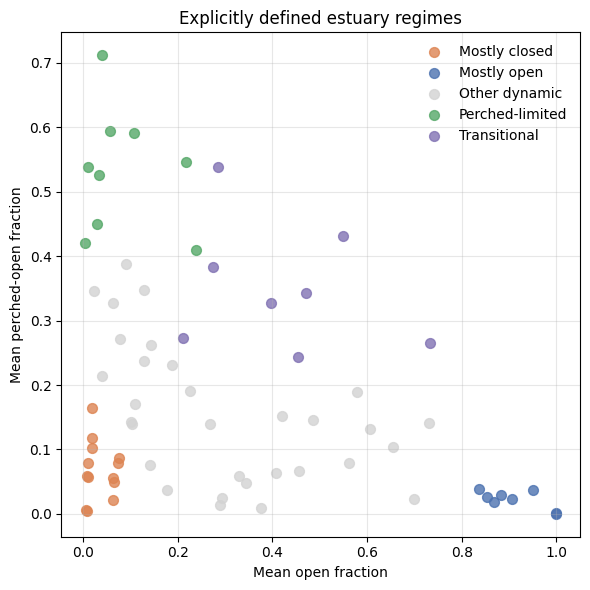

In [319]:
metrics["regime"].value_counts()

import matplotlib.pyplot as plt

colors = {
    "Mostly closed": "#DD8452",  # orange
    "Perched-limited": "#55A868",  # green
    "Transitional": "#8172B3",  # purple
    "Mostly open": "#4C72B0",  # blue
    "Other dynamic": "lightgray",
}

alpha_map = {
    "Mostly closed": 0.3,
    "Mostly open": 0.3,
    "Perched-limited": 0.9,
    "Transitional": 0.9,
    "Other dynamic": 0.5,
}

plt.figure(figsize=(6, 6))

for reg, g in metrics.groupby("regime"):
    plt.scatter(
        g.f_open,
        g.f_perched,
        s=50,
        alpha=0.8,
        label=reg,
        color=colors.get(reg, "black"),
    )

plt.xlabel("Mean open fraction")
plt.ylabel("Mean perched-open fraction")
plt.title("Explicitly defined estuary regimes")
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "regimes.png")
plt.show()

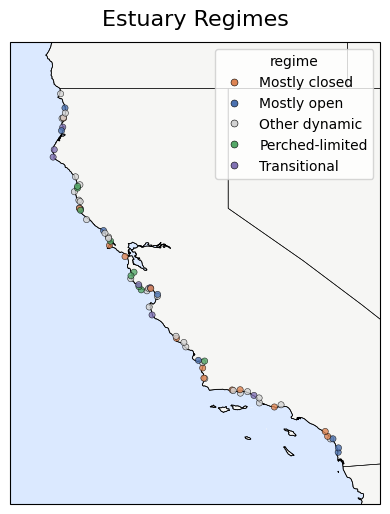

In [320]:
import matplotlib.colors as mcolors

regime_colors = {
    "Mostly closed": "#DD8452",  # orange
    "Perched-limited": "#55A868",  # green
    "Transitional": "#8172B3",  # purple
    "Mostly open": "#4C72B0",  # blue
    "Other dynamic": "lightgray",
}

# Choose the order you want to see in the legend
regime_order = [
    "Mostly closed",
    "Mostly open",
    "Other dynamic",
    "Perched-limited",
    "Transitional",
]

# Build a discrete colormap with exactly these colors in this order
regime_cmap = mcolors.ListedColormap([regime_colors[k] for k in regime_order], name="regime_cmap")

g = gdf_points.set_index("region").merge(
    metrics.regime, how="left", right_index=True, left_index=True
)

plot_estuaries_ca(
    g,
    column="regime",
    title="Estuary Regimes",
    markersize=20,
    jitter_deg=0.05,
    point_alpha=0.8,
    show=True,
    categorical=True,
    cmap=regime_cmap,
    save_path=FIG_DIR / "state_map_regimes.png",
)

/var/folders/pr/1dt1qk511zdgzhfy1xskpqm00000gn/T/ipykernel_31995/1150665556.py:57: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



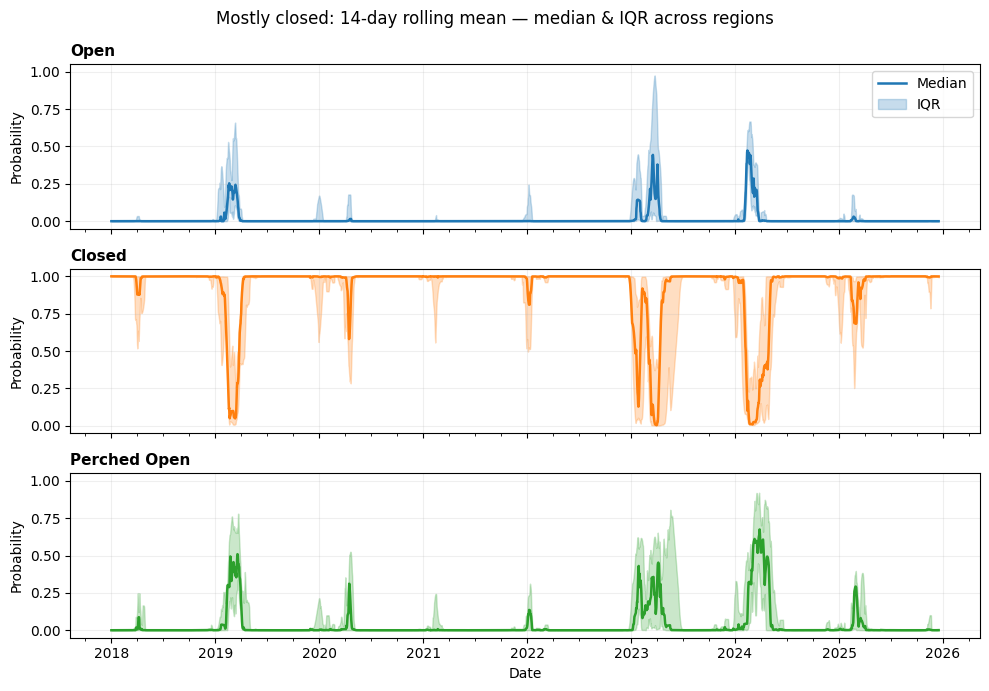

/var/folders/pr/1dt1qk511zdgzhfy1xskpqm00000gn/T/ipykernel_31995/1150665556.py:57: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



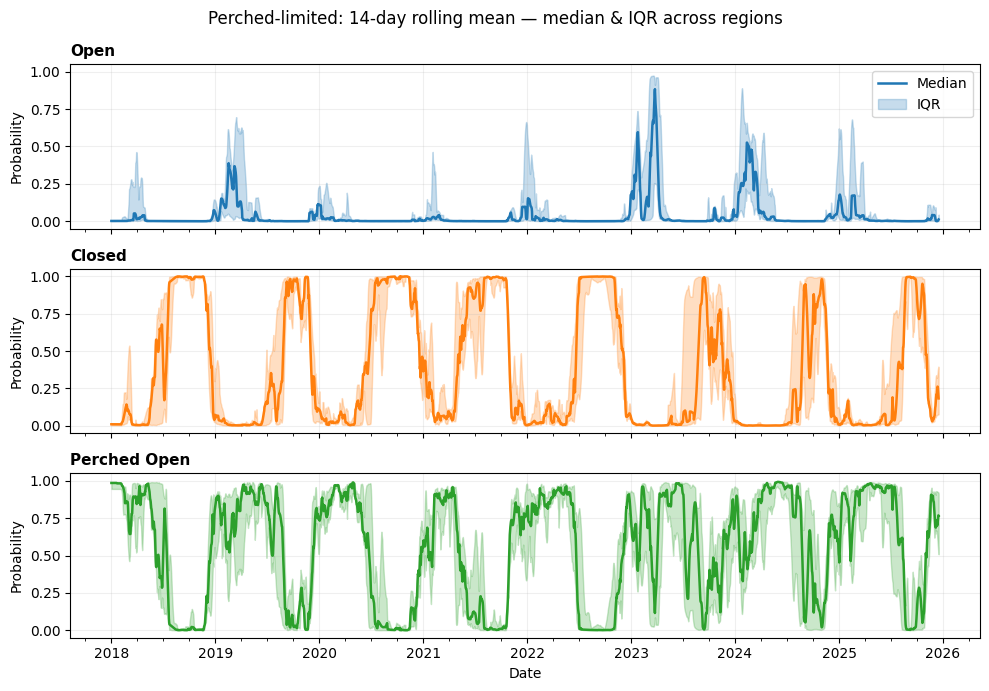

/var/folders/pr/1dt1qk511zdgzhfy1xskpqm00000gn/T/ipykernel_31995/1150665556.py:57: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



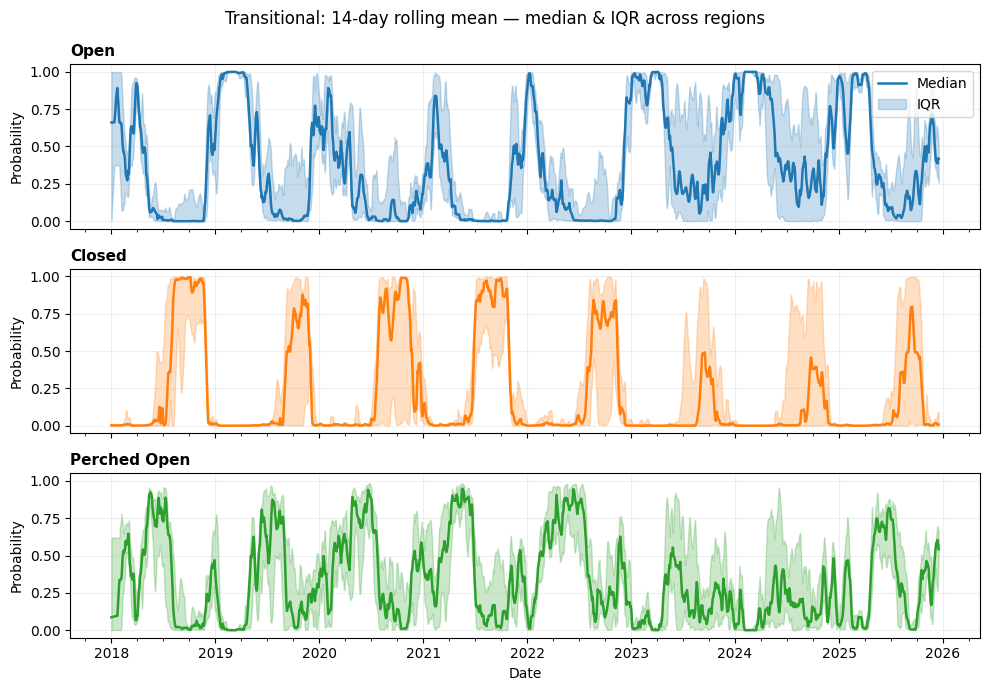

/var/folders/pr/1dt1qk511zdgzhfy1xskpqm00000gn/T/ipykernel_31995/1150665556.py:57: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



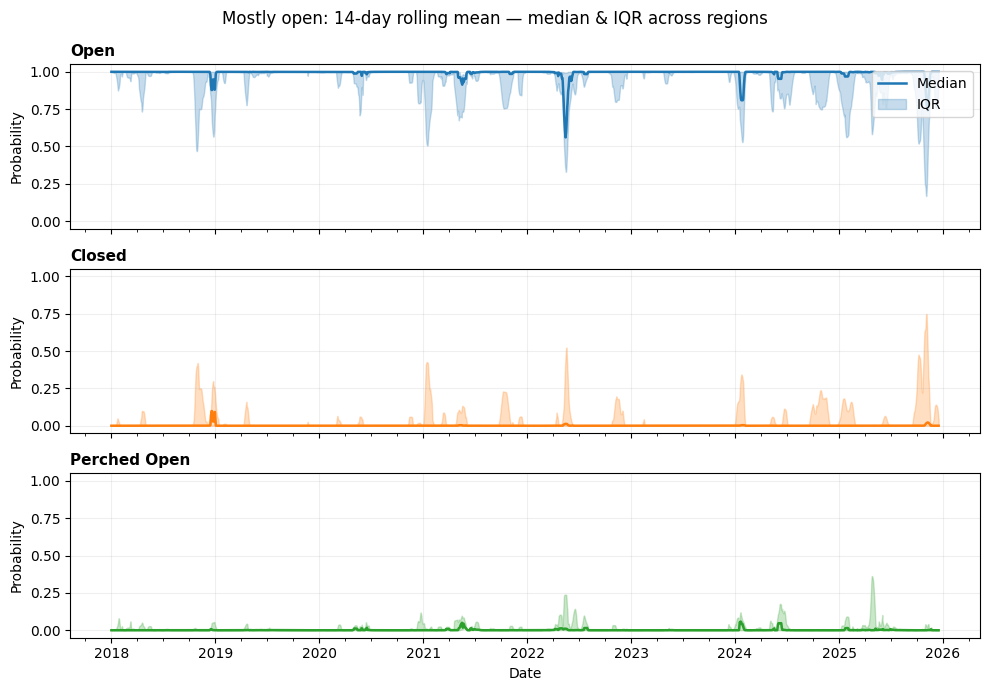

/var/folders/pr/1dt1qk511zdgzhfy1xskpqm00000gn/T/ipykernel_31995/1150665556.py:57: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



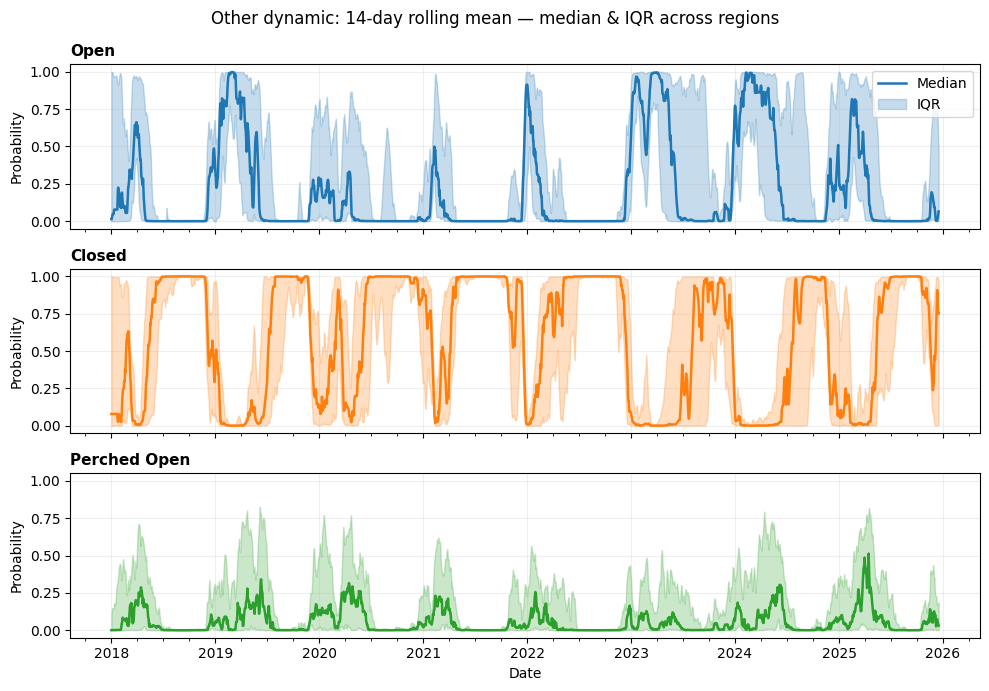

In [321]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

pcols = ["p_open", "p_closed", "p_perched_open"]

# ensure sorted
full = full.sort_index()

# join regime labels onto rows
tmp = full.reset_index()
tmp["date"] = pd.to_datetime(tmp["date"])

metrics["regime_refined"] = metrics["regime"]

tmp = tmp.merge(
    metrics[["regime_refined"]],
    left_on="region",
    right_index=True,
    how="left",
)

tmp = tmp.sort_values(["region", "date"])

titles = {
    "p_open": "Open",
    "p_closed": "Closed",
    "p_perched_open": "Perched Open",
}

colors = {
    "p_open": "tab:blue",
    "p_closed": "tab:orange",
    "p_perched_open": "tab:green",
}

# choose which classes to plot (edit order as desired)
classes = [
    "Mostly closed",
    "Perched-limited",
    "Transitional",
    "Mostly open",
    "Other dynamic",
]

pcols1 = pcols + ["date"]

for cls in classes:
    sub = tmp[tmp["regime_refined"] == cls].copy()
    if sub.empty:
        print(f"Skipping {cls}: no rows")
        continue

    # 14-day rolling mean PER REGION (same as your reference)
    rolled = (
        sub.groupby("region", group_keys=False)
        .apply(lambda g: g.assign(**g[pcols1].rolling("14D", on="date", min_periods=1).mean()))
        .set_index(["region", "date"])
        .sort_index()
    )[pcols]

    # Quantiles across regions at each date (same as your reference)
    q = rolled.groupby(level="date").quantile([0.25, 0.5, 0.75]).unstack()

    q = q.rename(columns={0.25: "q25", 0.5: "median", 0.75: "q75"}, level=1)

    # --- Plot (same styling as your reference) ---
    fig, axes = plt.subplots(
        3,
        1,
        figsize=(10, 7),
        sharex=True,
    )

    for ax, col in zip(axes, pcols):
        ax.plot(q.index, q[col]["median"], lw=1.8, color=colors[col], label="Median")
        ax.fill_between(
            q.index, q[col]["q25"], q[col]["q75"], color=colors[col], alpha=0.25, label="IQR"
        )

        ax.set_ylim(-0.05, 1.05)
        ax.set_ylabel("Probability")
        ax.set_title(titles[col], loc="left", fontsize=11, weight="bold")
        ax.grid(alpha=0.2)

    axes[-1].set_xlabel("Date")
    axes[0].legend(loc="upper right")

    # x-axis ticks (same as your reference)
    ax = axes[-1]
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))

    # Title + save
    fig.suptitle(f"{cls}: 14-day rolling mean — median & IQR across regions")
    fig.tight_layout()

    safe = cls.lower().replace(" ", "_").replace("-", "_")
    plt.savefig(FIG_DIR / f"{safe}_median_iqr_timeseries.png")
    plt.show()

In [322]:
metrics[metrics["regime"] == "Transitional"]

,f_closed,f_perched,f_open,entropy_mean,transitions,n_days,transitions_per_year,mean_persistence_days,regime,regime_refined
region,,,,,,,,,,
21,0.186448,0.343415,0.470137,0.272342,130,2908,16.317056,22.369231,Transitional,Transitional
46,0.302318,0.244153,0.453529,0.294726,78,2908,9.790234,37.282051,Transitional,Transitional
57,0.514629,0.273540,0.211831,0.152972,69,2908,8.660591,42.144928,Transitional,Transitional
63,0.176818,0.538680,0.284502,0.303137,70,2908,8.786107,41.542857,Transitional,Transitional
79,0.018884,0.431736,0.549380,0.271703,100,2908,12.551582,29.080000,Transitional,Transitional
92,0.275915,0.327520,0.396565,0.281682,66,2908,8.284044,44.060606,Transitional,Transitional
93,0.343476,0.382852,0.273672,0.320070,83,2908,10.417813,35.036145,Transitional,Transitional
12103,0.002387,0.264965,0.732648,0.270215,86,2908,10.794360,33.813953,Transitional,Transitional


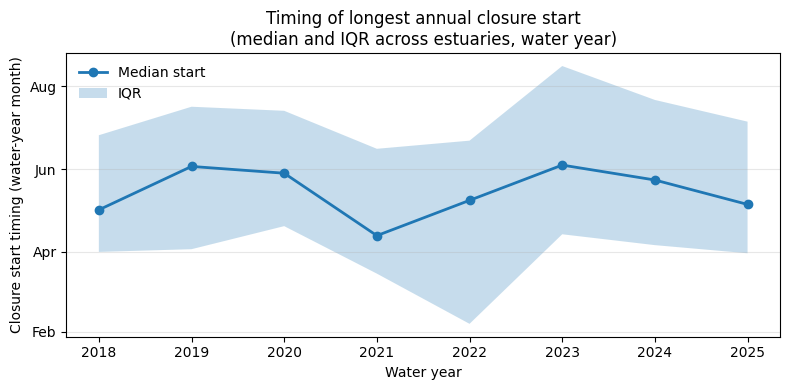

In [323]:
import datetime as dt

import numpy as np
import pandas as pd

# ensure datetime
events["start"] = pd.to_datetime(events["start"])

# water year for each event start: Oct–Dec belong to next year
events["water_year"] = events["start"].dt.year + (events["start"].dt.month >= 10)

# water-year start date (Oct 1 of previous calendar year)
wy_start = pd.to_datetime(dict(year=events["water_year"] - 1, month=10, day=1))

# water-year day-of-year: Oct 1 = 1
events["wy_doy"] = (events["start"].dt.normalize() - wy_start).dt.days + 1

# filter to closed events
ev = events[events["state"] == "closed"].copy()

# keep only starts within WY2018..WY2025 (your range)
ev = ev[(ev["water_year"] >= 2018) & (ev["water_year"] <= 2025)]

# pick the single longest closed event per (region, water_year)
df = (
    ev.sort_values(["region", "water_year", "duration"], ascending=[True, True, False])
    .drop_duplicates(["region", "water_year"])
    .copy()
)

summary = (
    df.groupby("water_year")["wy_doy"]
    .quantile([0.25, 0.5, 0.75])
    .unstack()
    .rename(columns={0.25: "q25", 0.5: "median", 0.75: "q75"})
    .reset_index()
    .rename(columns={"water_year": "wy"})
)


def wy_doy_to_date(wy_doy):
    # dummy water year starting Oct 1
    return dt.date(2001, 10, 1) + dt.timedelta(days=int(wy_doy) - 1)


summary["median_date"] = summary["median"].apply(wy_doy_to_date)
summary["q25_date"] = summary["q25"].apply(wy_doy_to_date)
summary["q75_date"] = summary["q75"].apply(wy_doy_to_date)

import matplotlib.dates as mdates
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.plot(summary["wy"], summary["median_date"], lw=2, marker="o", label="Median start")

plt.fill_between(summary["wy"], summary["q25_date"], summary["q75_date"], alpha=0.25, label="IQR")

ax = plt.gca()

# months on y-axis (Oct–Sep); interval=2 to reduce clutter
ax.yaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.yaxis.set_major_formatter(mdates.DateFormatter("%b"))

ax.grid(axis="y", alpha=0.3)

plt.ylabel("Closure start timing (water-year month)")
plt.xlabel("Water year")
plt.title("Timing of longest annual closure start\n(median and IQR across estuaries, water year)")
plt.legend(frameon=False)

plt.tight_layout()
plt.savefig(FIG_DIR / "closure_start_by_year.png")
plt.show()

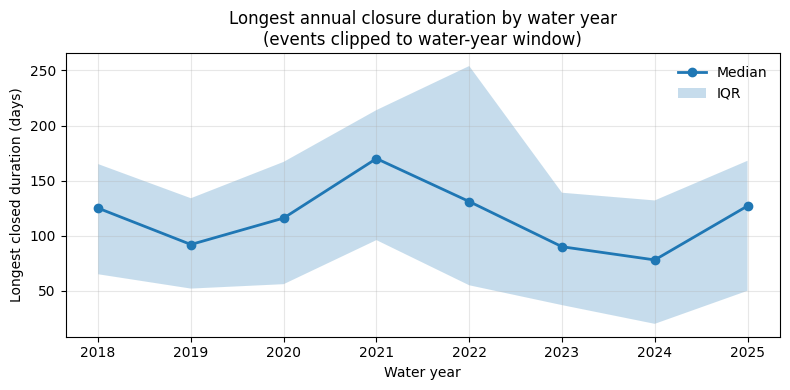

In [324]:
import numpy as np
import pandas as pd

events = events.copy()
events["start"] = pd.to_datetime(events["start"])
events["end"] = pd.to_datetime(events["end"])

# water year of an event is determined by its overlap, not just start
# we will expand events across all WYs they overlap

# keep only closed events
ev = events[events["state"] == "closed"].copy()

# compute WY of start and end
ev["wy_start"] = ev["start"].dt.year + (ev["start"].dt.month >= 10)
ev["wy_end"] = ev["end"].dt.year + (ev["end"].dt.month >= 10)

rows = []

for _, r in ev.iterrows():
    for wy in range(r.wy_start, r.wy_end + 1):
        wy_start = pd.Timestamp(year=wy - 1, month=10, day=1)
        wy_end = pd.Timestamp(year=wy, month=10, day=1)

        # compute clipped interval
        start_clip = max(r.start, wy_start)
        end_clip = min(r.end, wy_end)

        if start_clip < end_clip:
            rows.append(
                {
                    "region": r.region,
                    "water_year": wy,
                    "start_clip": start_clip,
                    "end_clip": end_clip,
                    "duration": (end_clip - start_clip).days,
                }
            )

clipped = pd.DataFrame(rows)

longest = (
    clipped.sort_values(["region", "water_year", "duration"], ascending=[True, True, False])
    .drop_duplicates(["region", "water_year"])
    .copy()
)

# all regions
all_regions = events["region"].unique()

# all water years you care about
all_wy = np.arange(2018, 2026)

full_index = pd.MultiIndex.from_product(
    [all_regions, all_wy], names=["region", "water_year"]
).to_frame(index=False)

longest_full = full_index.merge(
    longest[["region", "water_year", "duration"]], on=["region", "water_year"], how="left"
)
longest_full["duration"] = longest_full["duration"].fillna(0)


summary = (
    longest_full.groupby("water_year")["duration"]
    .quantile([0.25, 0.5, 0.75])
    .unstack()
    .rename(columns={0.25: "q25", 0.5: "median", 0.75: "q75"})
    .reset_index()
    .rename(columns={"water_year": "wy"})
)

summary["n_estuaries"] = longest_full.groupby("water_year").size().values

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.plot(summary["wy"], summary["median"], lw=2, marker="o", label="Median")

plt.fill_between(summary["wy"], summary["q25"], summary["q75"], alpha=0.25, label="IQR")

plt.ylabel("Longest closed duration (days)")
plt.xlabel("Water year")
plt.title("Longest annual closure duration by water year\n(events clipped to water-year window)")
plt.grid(alpha=0.3)
plt.legend(frameon=False)

plt.tight_layout()
plt.savefig(FIG_DIR / "closure_duration_by_year.png")
plt.show()

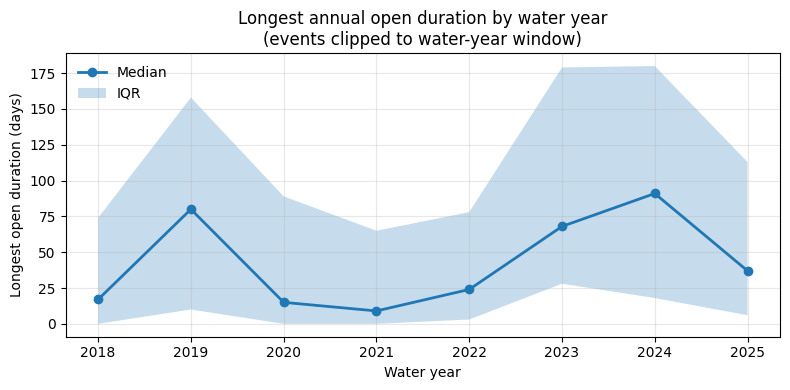

In [325]:
import numpy as np
import pandas as pd

events = events.copy()
events["start"] = pd.to_datetime(events["start"])
events["end"] = pd.to_datetime(events["end"])

# water year of an event is determined by its overlap, not just start
# we will expand events across all WYs they overlap

# keep only open events
ev = events[events["state"] == "open"].copy()

# compute WY of start and end
ev["wy_start"] = ev["start"].dt.year + (ev["start"].dt.month >= 10)
ev["wy_end"] = ev["end"].dt.year + (ev["end"].dt.month >= 10)

rows = []

for _, r in ev.iterrows():
    for wy in range(r.wy_start, r.wy_end + 1):
        wy_start = pd.Timestamp(year=wy - 1, month=10, day=1)
        wy_end = pd.Timestamp(year=wy, month=10, day=1)

        # compute clipped interval
        start_clip = max(r.start, wy_start)
        end_clip = min(r.end, wy_end)

        if start_clip < end_clip:
            rows.append(
                {
                    "region": r.region,
                    "water_year": wy,
                    "start_clip": start_clip,
                    "end_clip": end_clip,
                    "duration": (end_clip - start_clip).days,
                }
            )

clipped = pd.DataFrame(rows)

longest = (
    clipped.sort_values(["region", "water_year", "duration"], ascending=[True, True, False])
    .drop_duplicates(["region", "water_year"])
    .copy()
)

# all regions
all_regions = events["region"].unique()

# all water years you care about
all_wy = np.arange(2018, 2026)

full_index = pd.MultiIndex.from_product(
    [all_regions, all_wy], names=["region", "water_year"]
).to_frame(index=False)

longest_full = full_index.merge(
    longest[["region", "water_year", "duration"]], on=["region", "water_year"], how="left"
)
longest_full["duration"] = longest_full["duration"].fillna(0)


summary = (
    longest_full.groupby("water_year")["duration"]
    .quantile([0.25, 0.5, 0.75])
    .unstack()
    .rename(columns={0.25: "q25", 0.5: "median", 0.75: "q75"})
    .reset_index()
    .rename(columns={"water_year": "wy"})
)

summary["n_estuaries"] = longest_full.groupby("water_year").size().values

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.plot(summary["wy"], summary["median"], lw=2, marker="o", label="Median")

plt.fill_between(summary["wy"], summary["q25"], summary["q75"], alpha=0.25, label="IQR")

plt.ylabel("Longest open duration (days)")
plt.xlabel("Water year")
plt.title("Longest annual open duration by water year\n(events clipped to water-year window)")
plt.grid(alpha=0.3)
plt.legend(frameon=False)

plt.tight_layout()
plt.savefig(FIG_DIR / "open_duration_by_year.png")
plt.show()

In [326]:
import numpy as np
import pandas as pd

pcols = ["p_closed", "p_open", "p_perched_open"]

df = full_smooth.reset_index()
df["date"] = pd.to_datetime(df["date"])

# water year
df["water_year"] = df["date"].dt.year + (df["date"].dt.month >= 10)

df = df[df["water_year"] < 2026].copy()

# per estuary × water year fractions
wy_frac = (
    df.groupby(["region", "water_year"])[pcols]
    .mean()
    .rename(
        columns={
            "p_closed": "f_closed",
            "p_open": "f_open",
            "p_perched_open": "f_perched",
        }
    )
    .reset_index()
)

# dominant state (from smoothed data if you prefer)
df["state"] = df["state_smooth"]

df["transition"] = df.groupby("region")["state"].transform(lambda x: (x != x.shift()).fillna(False))

wy_trans = (
    df.groupby(["region", "water_year"])["transition"].sum().rename("n_transitions").reset_index()
)

wy_frac = wy_frac.merge(wy_trans, on=["region", "water_year"], how="left")


def assign_regime_refined_row(r):
    # dominance flags
    if r.f_closed >= 0.8:
        return "Mostly closed"
    if r.f_open >= 0.8:
        return "Mostly open"

    # dynamic regimes
    if r.f_perched >= 0.4 and r.f_open <= 0.25:
        return "Perched-limited"
    if r.f_open >= 0.2 and r.f_perched >= 0.2:
        return "Transitional"

    return "Other dynamic"


wy_frac["regime_wy"] = wy_frac.apply(assign_regime_refined_row, axis=1)

mobility = (
    wy_frac.sort_values(["region", "water_year"])
    .groupby("region")["regime_wy"]
    .apply(lambda x: (x != x.shift()).sum())
    .rename("n_regime_changes")
)

transitions = (
    wy_frac.sort_values(["region", "water_year"])
    .groupby("region")["regime_wy"]
    .apply(lambda x: list(zip(x[:-1], x[1:])))
    .explode()
    .dropna()
    .tolist()
)

regime_trans = (
    pd.DataFrame(transitions, columns=["from", "to"]).value_counts().rename("count").reset_index()
)

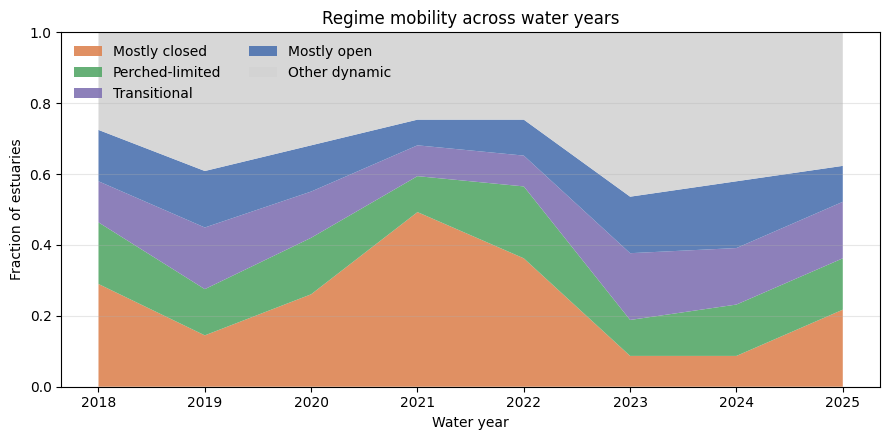

In [327]:
wy_statewide = wy_frac.groupby("water_year")["f_open"].median().rename("statewide_f_open")

# crude split (you can refine)
wet_years = [2019, 2023, 2024]  # wy_statewide[wy_statewide > wy_statewide.median()].index
dry_years = [2020, 2021]  # wy_statewide[wy_statewide <= wy_statewide.median()].index

regime_by_wetness = (
    wy_frac.assign(wet=lambda d: d.water_year.isin(wet_years))
    .groupby(["wet", "regime_wy"])
    .size()
    .rename("count")
    .reset_index()
)

regime_frac = wy_frac.groupby(["water_year", "regime_wy"]).size().rename("count").reset_index()

regime_frac["fraction"] = regime_frac["count"] / regime_frac.groupby("water_year")[
    "count"
].transform("sum")


regime_frac_pivot = (
    regime_frac.pivot(index="water_year", columns="regime_wy", values="fraction")
    .fillna(0)
    .sort_index()
)
regime_order = [
    "Mostly closed",
    "Perched-limited",
    "Transitional",
    "Mostly open",
    "Other dynamic",
]

regime_frac_pivot = regime_frac_pivot[[r for r in regime_order if r in regime_frac_pivot.columns]]

import matplotlib.pyplot as plt

colors = {
    "Mostly closed": "#DD8452",
    "Perched-limited": "#55A868",  # green
    "Transitional": "#8172B3",  # purple
    "Mostly open": "#4C72B0",  # blue
    "Other dynamic": "lightgray",
}

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.stackplot(
    regime_frac_pivot.index,
    [regime_frac_pivot[c] for c in regime_frac_pivot.columns],
    labels=regime_frac_pivot.columns,
    colors=[colors[c] for c in regime_frac_pivot.columns],
    alpha=0.9,
)

ax.set_ylim(0, 1)
ax.set_ylabel("Fraction of estuaries")
ax.set_xlabel("Water year")
ax.set_title("Regime mobility across water years")

ax.legend(loc="upper left", ncol=2, frameon=False)

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "regime_by_water_year.png")
plt.show()

In [359]:
def filter_outliers(df: pd.DataFrame, depth_col: str = "height") -> pd.DataFrame:
    # Quick-and-dirty outlier removal on depth values using IQR
    y = df[depth_col].astype(float)
    q1 = y.quantile(0.25)
    q3 = y.quantile(0.75)
    iqr = q3 - q1

    # Keep points within 3 * IQR (lenient to preserve events)
    lo = q1 - 3 * iqr
    hi = q3 + 3 * iqr

    mask = (y >= lo) & (y <= hi)
    return df.loc[mask].copy()


def contiguous_segments(
    df: pd.DataFrame, time_col: str = "acquired", gap_hours: int = 48
) -> list[pd.DataFrame]:
    """
    Find all contiguous segments in a time series (gaps > gap_hours separate segments).
    """
    out = []

    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col], errors="coerce", utc=True)
    df = df.dropna(subset=[time_col]).sort_values(time_col)
    if df.empty:
        return []

    gap = pd.Timedelta(hours=gap_hours)
    seg_id = (df[time_col].diff() > gap).cumsum()
    # Find all segments
    for sid in seg_id.unique():
        seg = df[seg_id == sid]

        if seg.empty:
            continue

        seg = filter_outliers(seg.copy())
        out.append(seg.reset_index(drop=True))

    return out


def subsample_time(df, resample_amount: str = "30min", columns: list[str] | None = None):
    df["timestamp_utc"] = pd.to_datetime(
        df["timestamp_utc"],
        utc=True,
        errors="coerce",
    )
    df = df.dropna(subset=["timestamp_utc"])
    if columns is not None:
        columns.append("timestamp_utc")
        df = df[columns]
    return (
        df.set_index("timestamp_utc")
        .sort_index()
        .resample(resample_amount, origin="epoch")
        .median()  # or .median(), .first(), etc.
        .dropna()
        .reset_index()
    )


def inlet_only_tidal_attenuation(
    s: pd.Series,
    *,
    window_days: int = 3,
    tz: str = "UTC",
) -> pd.DataFrame:
    """
    Inlet-only tidal attenuation (suppression index).

    Returns DataFrame with:
        - daily_range
        - tidal_range_proxy (rolling min of daily_range)
        - attenuation_pct
    """

    if not isinstance(s.index, pd.DatetimeIndex):
        raise TypeError("Series must have DatetimeIndex")

    s = s.copy()

    s = s.sort_index().dropna()

    # Daily min/max
    daily = s.resample("1D").agg(["min", "max"])
    daily.columns = ["daily_min", "daily_max"]

    # Daily range
    daily["daily_range"] = daily["daily_max"] - daily["daily_min"]

    # Rolling minimum (tidal proxy)
    daily["tidal_range_proxy"] = (
        daily["daily_range"].rolling(window_days, min_periods=1, center=True).min()
    )

    return daily

In [347]:
import numpy as np
import pandas as pd
from scipy.signal import welch


def rolling_tidal_spectral_metrics_welch(
    s: pd.Series,
    *,
    freq: str = "30min",
    window: str = "3D",
    band_hours: tuple[float, float] = (10, 14),
    min_frac: float = 0.8,
    detrend: str = "constant",
    nperseg_max: int = 512,
    max_interp_gap: str | None = "10h",
) -> pd.DataFrame:
    """
    Rolling spectral metrics using Welch PSD on a regular grid.

    Returns DataFrame with columns:
      - tp_frac
      - band_peakiness_median
      - band_peakiness_mean
      - band_peakiness_vs_outband_median
      - band_peak_period_hours
      - band_peak_freq_cph
      - n_valid
    """
    if not isinstance(s.index, pd.DatetimeIndex):
        raise TypeError("s must have a DatetimeIndex")

    # Ensure UTC
    s = s.copy()
    if s.index.tz is None:
        s.index = s.index.tz_localize("UTC")
    else:
        s.index = s.index.tz_convert("UTC")
    s = s.sort_index()

    # Regularize to fixed cadence
    s = s.resample(freq).mean()

    freq_td = pd.Timedelta(freq)
    window_td = pd.Timedelta(window)
    n_expected = int(window_td / freq_td) + 1
    min_n = int(np.ceil(n_expected * min_frac))

    dt_hours = freq_td.total_seconds() / 3600.0
    fs = 1.0 / dt_hours  # samples per hour

    # Band in cycles/hour
    f_low = 1.0 / band_hours[1]
    f_high = 1.0 / band_hours[0]

    # Optional interpolation limit
    interp_limit = None
    if max_interp_gap is not None:
        interp_limit = int(pd.Timedelta(max_interp_gap) / freq_td)

    out_rows = []

    for t in s.index:
        seg = s.loc[t - window_td : t]
        n_valid = int(seg.notna().sum())

        if n_valid < min_n:
            out_rows.append((np.nan, np.nan, np.nan, np.nan, n_valid))
            continue

        seg2 = seg.copy()

        # Interpolate small gaps only (keeps FFT assumptions reasonable)
        if interp_limit is not None:
            seg2 = seg2.interpolate(limit_area="inside", limit=interp_limit)

        # If still missing, skip
        if seg2.isna().any():
            out_rows.append((np.nan, np.nan, np.nan, np.nan, n_valid))
            continue

        x = seg2.to_numpy(dtype=float)

        # Welch PSD
        nperseg = min(len(x), nperseg_max)
        f, Pxx = welch(
            x,
            fs=fs,
            nperseg=nperseg,
            detrend=detrend,
            scaling="density",
        )

        if len(Pxx) == 0:
            out_rows.append((np.nan, np.nan, np.nan, np.nan, n_valid))
            continue

        Pxx = Pxx.copy()
        Pxx[0] = 0.0  # remove DC

        # Total power over all positive freqs
        total = np.trapezoid(Pxx, f)
        if not np.isfinite(total) or total <= 0:
            out_rows.append((np.nan, np.nan, np.nan, np.nan, n_valid))
            continue

        band = (f >= f_low) & (f <= f_high)
        if not band.any():
            out_rows.append((np.nan, np.nan, np.nan, np.nan, n_valid))
            continue

        band_pow = np.trapezoid(Pxx[band], f[band])
        tp_frac = float(band_pow / total)

        # Peak within band
        band_vals = Pxx[band]
        peak_val = float(np.max(band_vals))
        med_in = float(np.median(band_vals))
        mean_in = float(np.mean(band_vals))

        # Outside-band median (exclude DC already, but also exclude the band)
        outband = (~band) & (f > 0)
        outband_vals = Pxx[outband]
        med_out = float(np.median(outband_vals)) if outband_vals.size else np.nan

        eps = 1e-12
        peakiness_med = peak_val / max(med_in, eps)
        peakiness_mean = peak_val / max(mean_in, eps)
        peakiness_vs_out = peak_val / max(med_out, eps) if np.isfinite(med_out) else np.nan

        # Where is the peak (nice sanity check)
        peak_idx = int(np.argmax(band_vals))
        f_band = f[band]
        f_peak = float(f_band[peak_idx])  # cycles per hour
        period_peak = float(1.0 / f_peak) if f_peak > 0 else np.nan

        out_rows.append((tp_frac, peakiness_vs_out, period_peak, f_peak, n_valid))

    out = pd.DataFrame(
        out_rows,
        index=s.index,
        columns=[
            "tp_frac",
            "band_peakiness_vs_outband_median",
            "band_peak_period_hours",
            "band_peak_freq_cph",
            "n_valid",
        ],
    )

    return out

In [363]:
import tqdm

water_data_path = Path("/Volumes/x10pro/estuary/water_data/processed/")

all_segments = {}


def get_region_tide_series(tides_df: pd.DataFrame, region) -> pd.Series:
    ocean = tides_df.loc[
        tides_df["region"].astype(str) == str(region), ["timestamp_utc", "tide_height"]
    ].copy()
    ocean["timestamp_utc"] = pd.to_datetime(ocean["timestamp_utc"], utc=True, errors="coerce")
    ocean = ocean.dropna(subset=["timestamp_utc"]).sort_values("timestamp_utc")
    return ocean.set_index("timestamp_utc")["tide_height"]


for region, _ in tqdm.tqdm(gdf.set_index("region").iterrows(), total=len(gdf)):
    region_water_data_dir = water_data_path / str(region)
    if not region_water_data_dir.exists():
        continue

    region_segments = []
    for p in region_water_data_dir.glob("*.csv"):
        df = pd.read_csv(p, dtype={"sensor_id": "string", "source": "string"})
        for _, sdf in df.groupby(["sensor_id", "source"]):
            segments = contiguous_segments(sdf, time_col="timestamp_utc", gap_hours=8)
            segments = [subsample_time(seg, "1h", ["height"]) for seg in segments]
            region_segments.extend(segments)

    if len(region_segments) == 0:
        continue

    region_segments = sorted(
        region_segments,
        key=lambda sdf: sdf.timestamp_utc.max() - sdf.timestamp_utc.min(),
        reverse=True,
    )

    all_median = pd.concat(
        [subsample_time(s, "1h", ["height"]) for s in region_segments]
    ).height.median()
    meds = [s.height.median() for s in region_segments]
    keep = [np.abs(m - all_median) < 3 for m in meds]
    region_segments = [s for s, k in zip(region_segments, keep) if k]

    seg = pd.concat(region_segments)
    df = seg.drop_duplicates("timestamp_utc").sort_values("timestamp_utc")

    # parse timestamps + set index (UTC)
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True, errors="coerce")
    df = df.dropna(subset=["timestamp_utc"])
    df = df.set_index("timestamp_utc").sort_index()

    # z-score (if you want it)
    df["height_z"] = (df["height"] - df["height"].mean()) / df["height"].std()

    region_segments = contiguous_segments(df.reset_index(), time_col="timestamp_utc", gap_hours=8)

    out_segments = []
    for sdf in region_segments:
        sdf = sdf.set_index("timestamp_utc")
        s = sdf.height_z

        metrics = rolling_tidal_spectral_metrics_welch(
            s,
            freq="1h",
            window="7D",
            band_hours=(10, 14),
            min_frac=0.8,
        )

        metrics24 = rolling_tidal_spectral_metrics_welch(
            s,
            freq="1h",
            window="7D",
            band_hours=(20, 28),
            min_frac=0.8,
        )

        m12 = metrics.copy()
        # m12.loc[m12.band_peakiness_vs_outband_median < 1000, "tp_frac"] = 0.0
        m24 = metrics24.copy()
        # m24.loc[m24.band_peakiness_vs_outband_median < 1000, "tp_frac"] = 0.0

        tp_total = m12.tp_frac + m24.tp_frac
        tp_hf = tp_total.reindex(df.index, method="ffill")

        tidal_attn = inlet_only_tidal_attenuation(s)
        tidal_hf = tidal_attn.reindex(df.index, method="ffill")

        # merge
        df2 = sdf.join(tp_hf)
        df3 = df2.join(tidal_hf)
        df3 = df3.reset_index().sort_values("timestamp_utc")
        out_segments.append(df3)

    all_segments[region] = out_segments

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 69/69 [05:17<00:00,  4.60s/it]


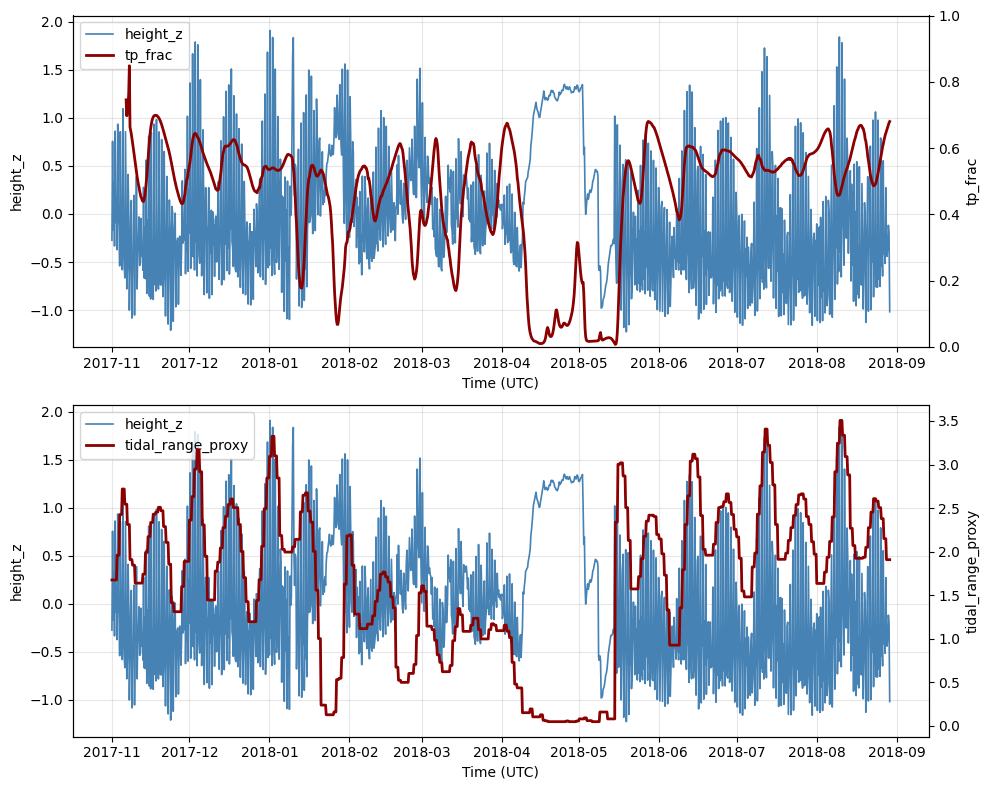

In [367]:
s = all_segments[11][5]

# Ensure datetime index
s = s.copy()
s["timestamp_utc"] = pd.to_datetime(s["timestamp_utc"], utc=True, errors="coerce")
s = s.dropna(subset=["timestamp_utc"]).set_index("timestamp_utc").sort_index()

s = s.resample("6h").mean()

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 8))

# Tidal power _____________________________
ax1 = axes[0]
ax2 = ax1.twinx()

# Height (left axis)
ax1.plot(s.index, s["height_z"], color="steelblue", linewidth=1.2, label="height_z")
ax1.set_ylabel("height_z")
ax1.grid(True, alpha=0.3)

# Tidal power fraction (right axis)
ax2.plot(s.index, s["tp_frac"], color="darkred", linewidth=2, label="tp_frac")
ax2.set_ylabel("tp_frac")
ax2.set_ylim(0, 1)

ax1.set_xlabel("Time (UTC)")

# Combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left")

# Tidal range _____________________________
ax1 = axes[1]
ax2 = ax1.twinx()

# Height (left axis)
ax1.plot(s.index, s["height_z"], color="steelblue", linewidth=1.2, label="height_z")
ax1.set_ylabel("height_z")
ax1.grid(True, alpha=0.3)

# Tidal power fraction (right axis)
ax2.plot(s.index, s["tidal_range_proxy"], color="darkred", linewidth=2, label="tidal_range_proxy")
ax2.set_ylabel("tidal_range_proxy")

ax1.set_xlabel("Time (UTC)")

# Combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left")

plt.tight_layout()
# plt.savefig(FIG_DIR / "example_height_vs_tidal_power.png")
plt.show()

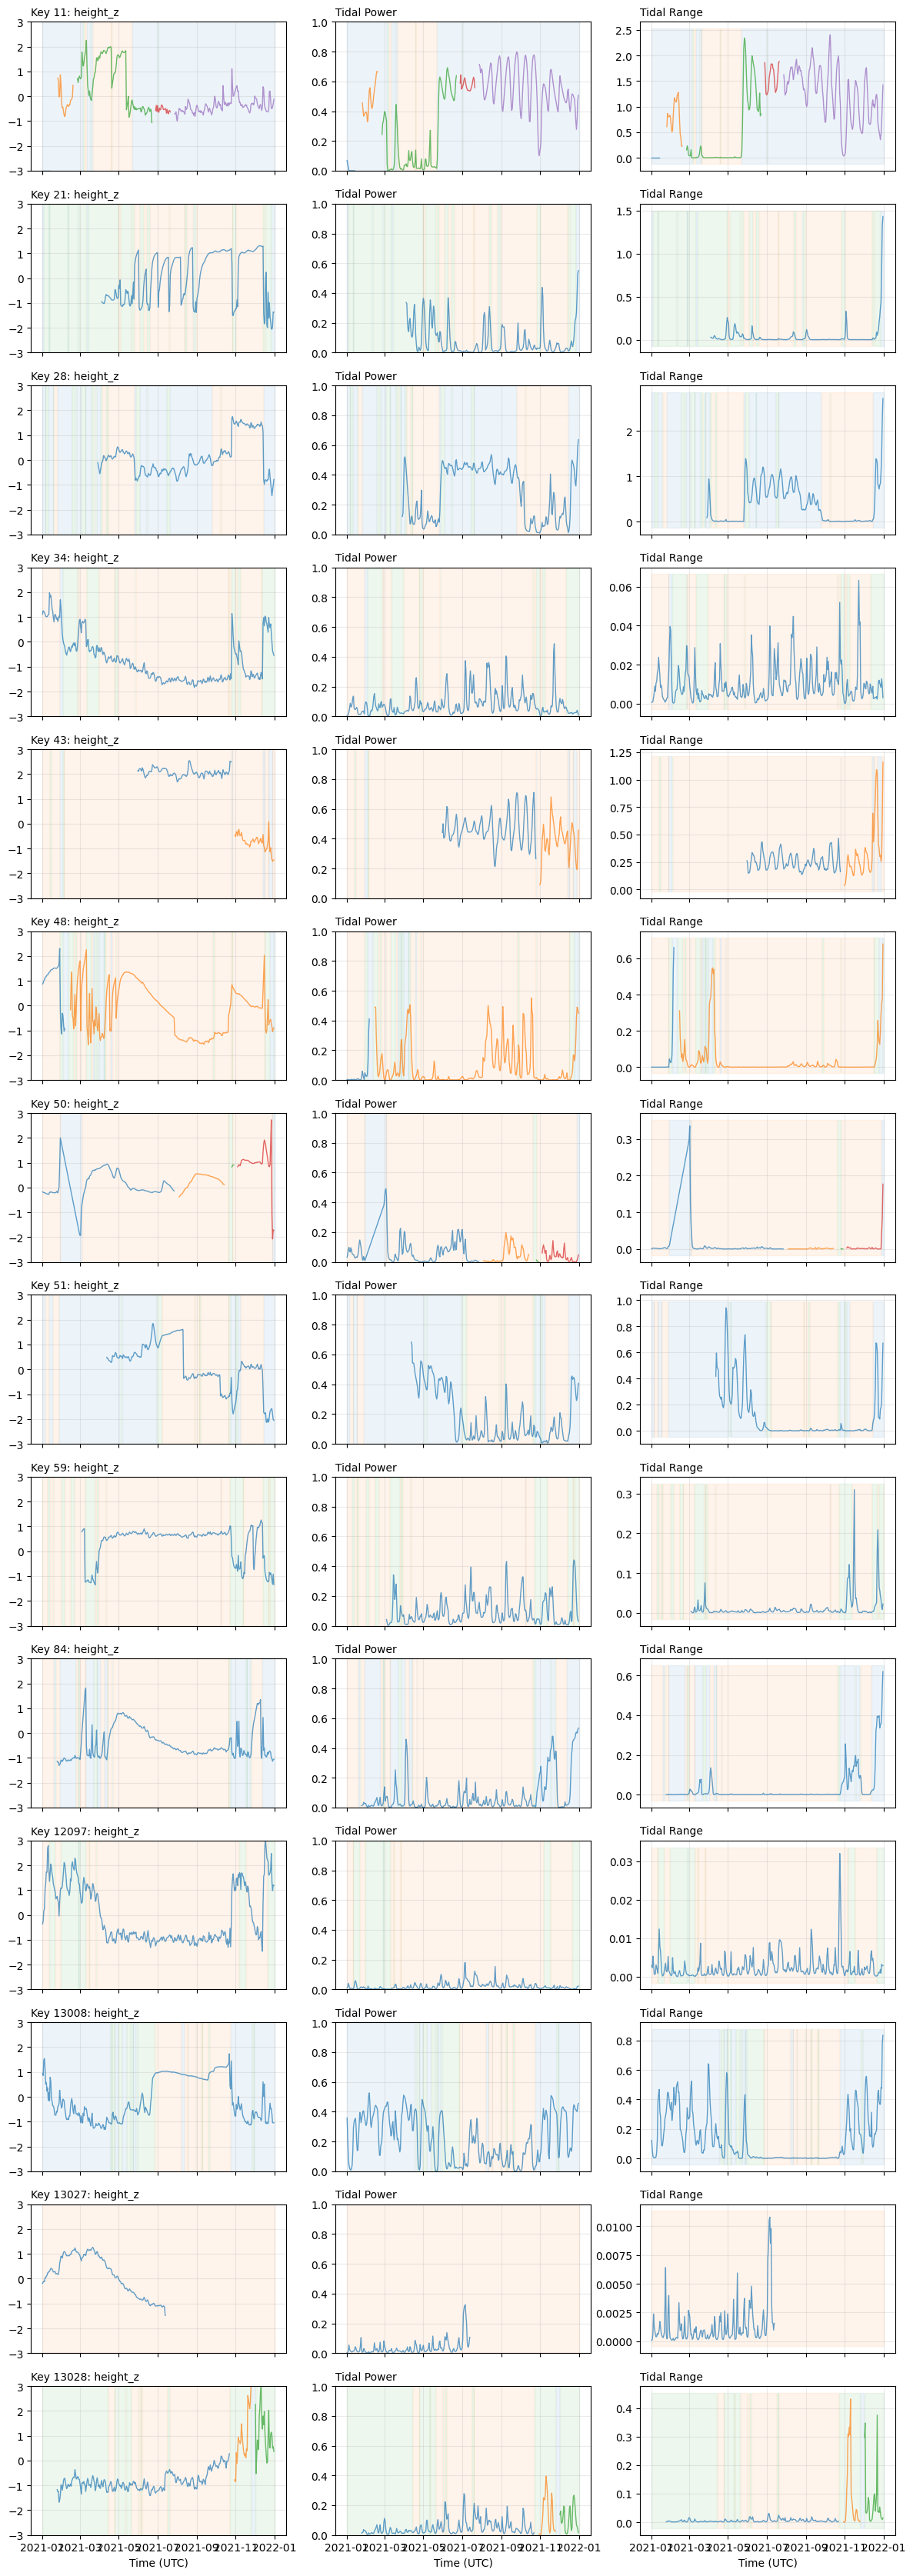

In [372]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- restrict to 2021 (UTC-aware) ---
start = pd.Timestamp("2021-01-01", tz="UTC")
end = pd.Timestamp("2022-01-01", tz="UTC")

keys = []
for r, k in enumerate(all_segments.keys()):
    keep = False
    for df in all_segments[k]:
        d = df.copy()
        d["timestamp_utc"] = pd.to_datetime(d["timestamp_utc"], utc=True, errors="coerce")
        d = d[(d["timestamp_utc"] >= start) & (d["timestamp_utc"] < end)]
        d = d.dropna(subset=["timestamp_utc"]).sort_values("timestamp_utc")
        if d.empty:
            continue
        keep = True
        break
    if keep:
        keys.append(k)

keys = sorted(keys)
n = len(keys)

fig, axes = plt.subplots(
    nrows=n,
    ncols=3,
    figsize=(12, 2.4 * n),
    sharex="col",  # share x within each column
)

if n == 1:
    axes = np.array([axes])  # make it 2D: (1, 2)

for r, k in enumerate(keys):
    ax_h, ax_t, ax_d = axes[r, :]

    for df in all_segments[k]:
        d = df.copy()
        d["timestamp_utc"] = pd.to_datetime(d["timestamp_utc"], utc=True, errors="coerce")
        d = d.dropna(subset=["timestamp_utc"]).sort_values("timestamp_utc")
        d = subsample_time(d, "1D")

        # filter to 2021
        d = d[(d["timestamp_utc"] >= start) & (d["timestamp_utc"] < end)]
        if d.empty:
            continue

        t = d["timestamp_utc"]

        h = d["height_z"].astype(float).clip(-3, 3)
        ax_h.plot(t, h, linewidth=1, alpha=0.7)

        # power
        power = d["tp_frac"].astype(float).clip(0, 1)
        ax_t.plot(t, power, linewidth=1, alpha=0.7)

        # ranges
        tide = d["tidal_range_proxy"].astype(float) * power
        ax_d.plot(t, tide, linewidth=1, alpha=0.7)

    # formatting per row
    ax_t.set_ylim(0, 1)
    ax_h.set_ylim(-3, 3)

    ax_h.set_title(f"Key {k}: height_z", loc="left", fontsize=10)
    ax_t.set_title("Tidal Power", loc="left", fontsize=10)
    ax_d.set_title("Tidal Range", loc="left", fontsize=10)

    colors = {
        2: "tab:blue",
        0: "tab:orange",
        1: "tab:green",
    }

    adf = full_smooth.reset_index()
    adf["date"] = pd.to_datetime(adf["date"], utc=True)
    dominant = adf[(adf.region == k) & (adf.date.between(start, end))].set_index("date").y_pred

    ymin, ymax = ax_d.get_ylim()
    for col, color in colors.items():
        mask = dominant == col
        ax_t.fill_between(dominant.index, 0, 1, where=mask, color=color, alpha=0.08)
        ax_h.fill_between(dominant.index, -3, 3, where=mask, color=color, alpha=0.08)
        ax_d.fill_between(dominant.index, ymin, ymax, where=mask, color=color, alpha=0.08)

    for ax in (ax_t, ax_h, ax_d):
        ax.grid(True, alpha=0.25)

# x-labels on bottom row only
for ax in axes[-1, :]:
    ax.set_xlabel("Time (UTC)")

plt.tight_layout()
# plt.savefig(FIG_DIR / "water_data_classification_overlay.png")
plt.show()

In [373]:
targets = full_smooth.index.to_frame(index=False).copy()

VALUE_COL = "height_z"
TS_COL = "timestamp_utc"
TOL = "1h"


for val_col in ["height_z", "tp_frac", "tidal_range_proxy"]:
    # We'll fill this
    targets[val_col] = pd.NA

    # Now fill targets region by region
    for region, g in tqdm.tqdm(
        targets.groupby("region", sort=False), total=len(targets.region.unique())
    ):
        if region not in all_segments:
            continue

        # Work on a view we can update, then write back
        idx = g.index
        need = targets.loc[idx, val_col].isna()
        if not need.any():
            continue

        # Each segment corresponds to ONE logger for some contiguous interval.
        # We’ll try them in priority order and fill the first that overlaps.
        for seg in all_segments[region]:
            s = seg.sort_values(TS_COL).set_index(TS_COL).resample("1D", origin="epoch").mean()
            s.index = s.index.date
            s.index = pd.to_datetime(s.index, errors="coerce")

            # Segment coverage interval
            seg_start = pd.Timestamp(s.index.min())
            seg_end = pd.Timestamp(s.index.max())

            # Which target rows still need filling AND are within this segment’s time span?
            need = targets.loc[idx, val_col].isna()
            if not need.any():
                break

            in_range = (
                need
                & (targets.loc[idx, "date"] >= seg_start)
                & (targets.loc[idx, "date"] <= seg_end)
            )
            if not in_range.any():
                continue

            # Indices of target rows we want to fill for this segment
            in_range_idx = idx[in_range]  # original targets indices (not 0..n)

            # Build left table and carry original row index explicitly
            left = targets.loc[in_range_idx, ["date"]].copy()
            left["_row"] = left.index
            left = left.sort_values("date")

            matched = pd.merge_asof(
                left,
                s[val_col],
                left_on="date",
                right_index=True,
                direction="nearest",
                # tolerance=TOL,
            )

            got = matched[val_col].notna()
            if got.any():
                rows_to_fill = matched.loc[got, "_row"].to_numpy()
                vals_to_fill = matched.loc[got, val_col].to_numpy()

                targets.loc[rows_to_fill, val_col] = vals_to_fill

    full_smooth[val_col] = targets[val_col].to_numpy()

full_smooth["tidal_range_power"] = full_smooth["tp_frac"] * full_smooth["tidal_range_proxy"]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 69/69 [00:00<00:00, 256.74it/s]


/var/folders/pr/1dt1qk511zdgzhfy1xskpqm00000gn/T/ipykernel_31995/3522706019.py:97: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



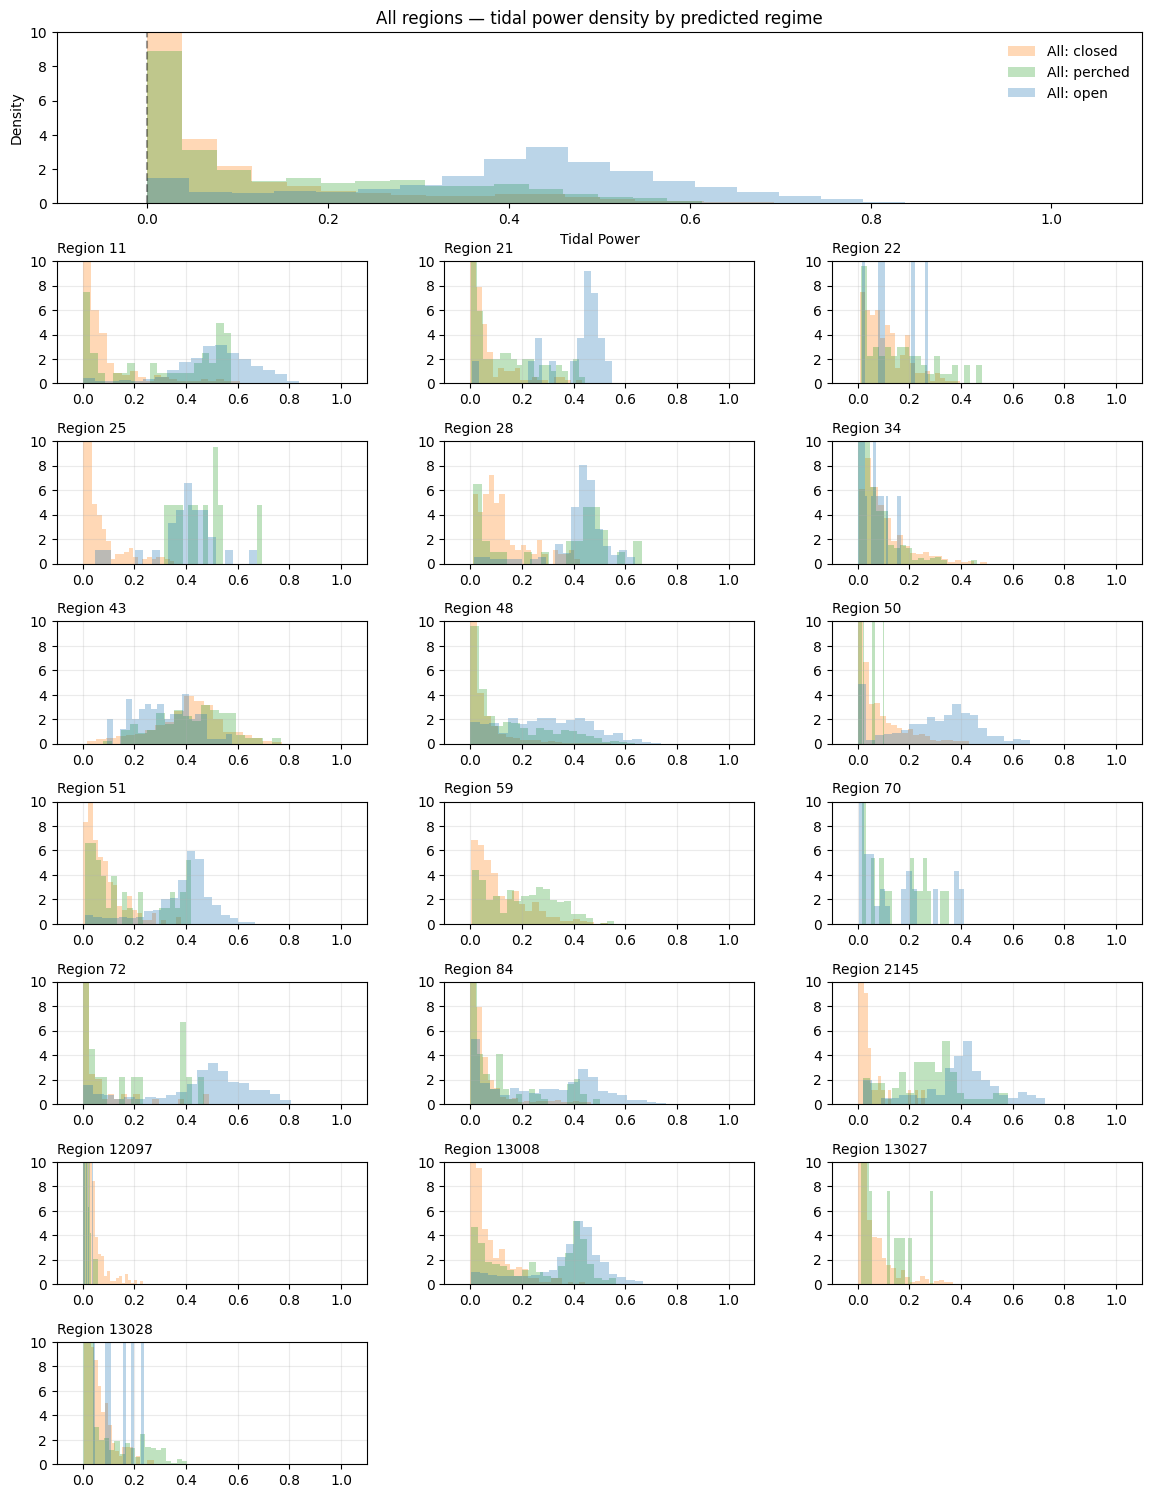

In [374]:
import math

import matplotlib.pyplot as plt

region_level = "region"
K = [0, 1, 2]
label_map = {0: "closed", 1: "perched", 2: "open"}
df = full_smooth[full_smooth.tidal_power.notna()].copy()

# Get regions from the MultiIndex
regions = df.index.get_level_values(region_level).unique().tolist()
regions = sorted(regions)

n_regions = len(regions)
ncols = 3
nrows_small = math.ceil(n_regions / ncols)

fig = plt.figure(figsize=(14, 3.2 + 2.2 * nrows_small))
gs = fig.add_gridspec(
    nrows=1 + nrows_small,
    ncols=ncols,
    height_ratios=[1.4] + [1.0] * nrows_small,
    hspace=0.45,
    wspace=0.25,
)

# --- Top: all regions combined (spans 3 columns) ---
ax_top = fig.add_subplot(gs[0, :])

for k in K:
    s_all = df.loc[df["y_pred"] == k, "tidal_power"].dropna()
    if len(s_all) == 0:
        continue
    # s_all.plot(kind="kde", ax=ax_top, color=colors[k], label=f"All: {label_map[k]}", linewidth=2, bw_method=0.3)
    ax_top.hist(
        s_all, bins=20, density=True, alpha=0.3, color=colors[k], label=f"All: {label_map[k]}"
    )

ax_top.set_title("All regions — tidal power density by predicted regime")
ax_top.set_xlabel("Tidal Power")
ax_top.set_ylabel("Density")
ax_top.legend(frameon=False)
ax_top.set_xlim(-0.1, 1.1)
ax_top.set_ylim(0, 10)
ax_top.axvline(0, color="k", linestyle="--", alpha=0.4)

# --- Bottom: one plot per region ---
axes_small = []
for i, region in enumerate(regions):
    r = 1 + (i // ncols)
    c = i % ncols
    ax = fig.add_subplot(gs[r, c], sharex=ax_top, sharey=ax_top)
    axes_small.append(ax)

    df_r = df.xs(region, level=region_level)

    for k in K:
        s = df_r.loc[df_r["y_pred"] == k, "tidal_power"].dropna()
        if len(s) <= 1:
            continue
        if s.max() < 0.01:
            continue
        ax.hist(
            s,
            bins=20,
            density=True,
            alpha=0.3,
            color=colors[k],
            # label=f"All: {label_map[k]}"
        )
        # s.plot(kind="kde", ax=ax, color=colors[k], linewidth=1.6, alpha=0.9, bw_method=0.3)

    ax.set_title(f"Region {region}", loc="left", fontsize=10)
    ax.grid(True, alpha=0.25)

    # Keep labels minimal to reduce clutter
    if c != 0:
        ax.set_ylabel("")
    if r != (1 + nrows_small - 1):
        ax.set_xlabel("")

# If the grid has extra empty slots, turn them off
for j in range(n_regions, nrows_small * ncols):
    r = 1 + (j // ncols)
    c = j % ncols
    ax_empty = fig.add_subplot(gs[r, c])
    ax_empty.axis("off")

fig.tight_layout()
# plt.savefig(FIG_DIR / "water_height_by_predicted_class.png")
plt.show()

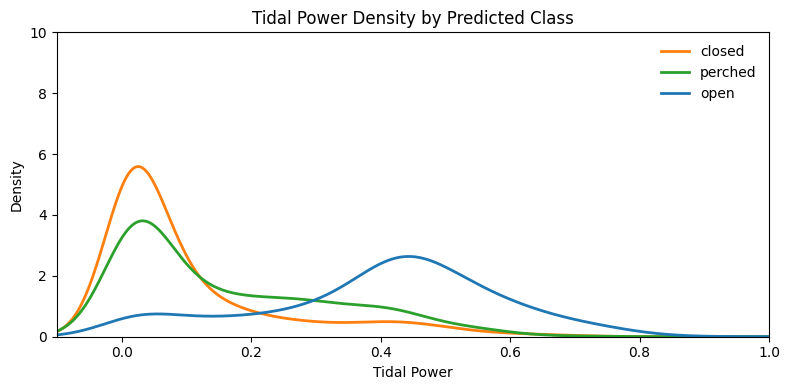

In [375]:
import math

import matplotlib.pyplot as plt

region_level = "region"
K = [0, 1, 2]
label_map = {0: "closed", 1: "perched", 2: "open"}
df = full_smooth[full_smooth.tidal_power.notna()].copy()

# Get regions from the MultiIndex
regions = df.index.get_level_values(region_level).unique().tolist()
regions = sorted(regions)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

for k in K:
    s_all = df.loc[df["y_pred"] == k, "tidal_power"].dropna()

    s_all.plot(kind="kde", ax=ax, color=colors[k], label=label_map[k], linewidth=2, bw_method=0.3)
    # ax.hist(
    #     s_all,
    #     bins=30,
    #     density=True,
    #     alpha=0.3,
    #     color=colors[k],
    #     label=label_map[k]
    # )

ax.set_title("Tidal Power Density by Predicted Class")
ax.set_xlabel("Tidal Power")
ax.set_ylabel("Density")
ax.legend(frameon=False)
ax.set_xlim(-0.1, 1)
ax.set_ylim(0, 10)

fig.tight_layout()
plt.savefig(FIG_DIR / "tidal_power_by_predicted_class.png")
plt.show()

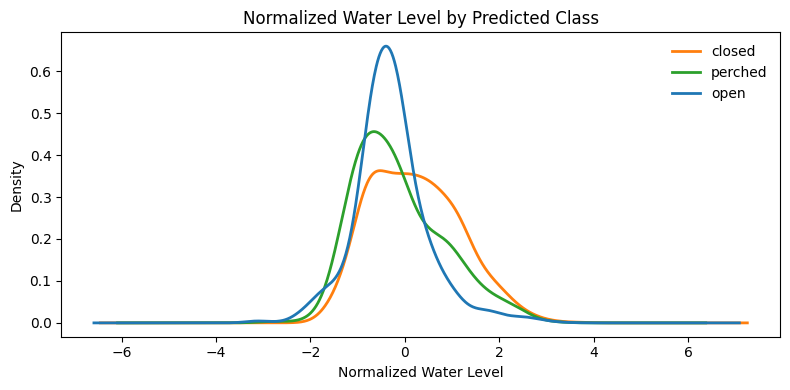

In [386]:
import math

import matplotlib.pyplot as plt

key = "height_z"

region_level = "region"
K = [0, 1, 2]
label_map = {0: "closed", 1: "perched", 2: "open"}
df = full_smooth[full_smooth[key].notna()].copy()

# Get regions from the MultiIndex
regions = df.index.get_level_values(region_level).unique().tolist()
regions = sorted(regions)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

for k in K:
    s_all = df.loc[df["y_pred"] == k, key].dropna()

    s_all.plot(kind="kde", ax=ax, color=colors[k], label=label_map[k], linewidth=2, bw_method=0.3)
    # ax.hist(
    #     s_all,
    #     bins=30,
    #     density=True,
    #     alpha=0.3,
    #     color=colors[k],
    #     label=label_map[k]
    # )

ax.set_title("Normalized Water Level by Predicted Class")
ax.set_xlabel("Normalized Water Level")
ax.set_ylabel("Density")
ax.legend(frameon=False)
# ax.set_xlim(-0.1, 1)
# ax.set_ylim(0, 10)

fig.tight_layout()
plt.savefig(FIG_DIR / "water_level_density_by_predicted_class.png")
plt.show()

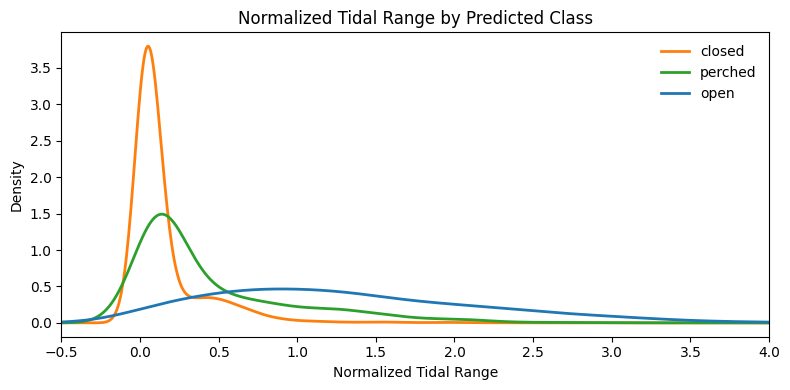

In [379]:
import math

import matplotlib.pyplot as plt

key = "tidal_range_proxy"

region_level = "region"
K = [0, 1, 2]
label_map = {0: "closed", 1: "perched", 2: "open"}
df = full_smooth[full_smooth[key].notna()].copy()

# Get regions from the MultiIndex
regions = df.index.get_level_values(region_level).unique().tolist()
regions = sorted(regions)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

for k in K:
    s_all = df.loc[df["y_pred"] == k, key].dropna()

    s_all.plot(kind="kde", ax=ax, color=colors[k], label=label_map[k], linewidth=2, bw_method=0.3)
    # ax.hist(
    #     s_all,
    #     bins=30,
    #     density=True,
    #     alpha=0.3,
    #     color=colors[k],
    #     label=label_map[k]
    # )

ax.set_title("Normalized Tidal Range by Predicted Class")
ax.set_xlabel("Normalized Tidal Range")
ax.set_ylabel("Density")
ax.legend(frameon=False)
ax.set_xlim(-0.5, 4)
# ax.set_ylim(0, 10)

fig.tight_layout()
# plt.savefig(FIG_DIR / "tidal_range_density_by_predicted_class.png")
plt.show()

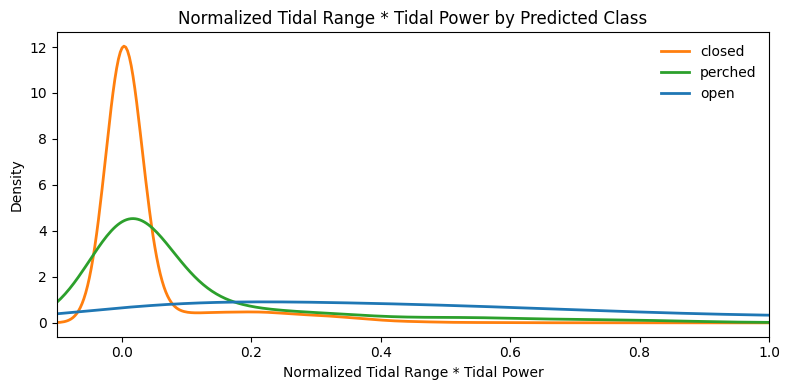

In [385]:
import math

import matplotlib.pyplot as plt

key = "tidal_range_power"

region_level = "region"
K = [0, 1, 2]
label_map = {0: "closed", 1: "perched", 2: "open"}
df = full_smooth[full_smooth[key].notna()].copy()

# Get regions from the MultiIndex
regions = df.index.get_level_values(region_level).unique().tolist()
regions = sorted(regions)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

for k in K:
    s_all = df.loc[df["y_pred"] == k, key].dropna()

    s_all.plot(kind="kde", ax=ax, color=colors[k], label=label_map[k], linewidth=2, bw_method=0.3)
    # ax.hist(
    #     s_all,
    #     bins=30,
    #     density=True,
    #     alpha=0.3,
    #     color=colors[k],
    #     label=label_map[k]
    # )

ax.set_title("Normalized Tidal Range * Tidal Power by Predicted Class")
ax.set_xlabel("Normalized Tidal Range * Tidal Power")
ax.set_ylabel("Density")
ax.legend(frameon=False)
ax.set_xlim(-0.1, 1)
# ax.set_ylim(0, 10)

fig.tight_layout()
# plt.savefig(FIG_DIR / "tidal_range_density_by_predicted_class.png")
plt.show()

In [338]:
a = full_smooth.reset_index()
b = a[~a.tidal_power.isna()]
print(len(b), len(b.region.unique()))
b.region.value_counts().describe()

20880 19


count      19.000000
mean     1098.947368
std       831.321269
min        56.000000
25%       341.000000
50%       938.000000
75%      1525.000000
max      2829.000000
Name: count, dtype: float64